# Bracket Prediction Model V2
 Using Point Level Data to incorporate player styles to separate players of similar ELOs 

### Import Cells and Repo Path Setup

In [91]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

def find_repo_root(start_path=None):
    """
    Finds the repo root by walking upward until it sees the expected Data folder.
    Works whether your notebook is opened from /Notebooks or from repo root.
    """
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for path in [start_path] + list(start_path.parents):
        if (path / "Data").exists() and (path / "Notebooks").exists():
            return path

    raise FileNotFoundError(
        "Could not find repo root. Make sure this notebook is inside the Grand_Slam_Bracket_Optimizer repo."
    )

REPO_ROOT = find_repo_root()

DATA_DIR = REPO_ROOT / "Data"
MATCH_DATA_DIR = DATA_DIR / "Match Data"
POINT_DATA_DIR = DATA_DIR / "Point Data"
GENERATED_BRACKETS_DIR = REPO_ROOT / "Generated Brackets"
PRODUCER_INPUTS_DIR = REPO_ROOT / "bracket_producer_inputs" / "Wimbledon 2026"

print("Repo root:", REPO_ROOT)
print("Match data dir:", MATCH_DATA_DIR)
print("Point data dir:", POINT_DATA_DIR)

Repo root: c:\Users\ishan\Downloads\Grand_Slam_Bracket_Optimizer
Match data dir: c:\Users\ishan\Downloads\Grand_Slam_Bracket_Optimizer\Data\Match Data
Point data dir: c:\Users\ishan\Downloads\Grand_Slam_Bracket_Optimizer\Data\Point Data


### Load Match Data, Clean and sort

In [4]:
MATCH_YEARS = list(range(2010, 2027))

match_file_paths = [
    MATCH_DATA_DIR / f"{year}.csv"
    for year in MATCH_YEARS
]

missing_files = [path for path in match_file_paths if not path.exists()]

if missing_files:
    raise FileNotFoundError(f"Missing match files: {missing_files}")

match_dfs = []

for path in match_file_paths:
    year_df = pd.read_csv(path)
    year_df["source_file"] = path.name
    match_dfs.append(year_df)

match_df = pd.concat(match_dfs, ignore_index=True)

print("Loaded match_df shape:", match_df.shape)

# Convert tourney_date from YYYYMMDD integer format to datetime
match_df["tourney_date"] = pd.to_datetime(
    match_df["tourney_date"].astype("Int64").astype(str),
    format="%Y%m%d",
    errors="coerce"
)

match_df = match_df.sort_values(
    ["tourney_date", "tourney_id", "match_num"]
).reset_index(drop=True)

print("Date range:", match_df["tourney_date"].min(), "to", match_df["tourney_date"].max())
print("Rows:", len(match_df))

match_df[[
    "tourney_date",
    "tourney_name",
    "surface",
    "winner_name",
    "loser_name",
    "round"
]].tail()

Loaded match_df shape: (47317, 51)
Date range: 2010-01-03 00:00:00 to 2026-07-12 00:00:00
Rows: 47317


,tourney_date,tourney_name,surface,winner_name,loser_name,round
47312,2026-07-08,Wimbledon,Grass,Alexander Zverev,Taylor Fritz,QF
47313,2026-07-08,Wimbledon,Grass,Arthur Fery,Flavio Cobolli,QF
47314,2026-07-10,Wimbledon,Grass,Alexander Zverev,Arthur Fery,SF
47315,2026-07-10,Wimbledon,Grass,Jannik Sinner,Novak Djokovic,SF
47316,2026-07-12,Wimbledon,Grass,Jannik Sinner,Alexander Zverev,F


### Load ATP Player Database

In [5]:
ATP_DB_PATH = DATA_DIR / "ATP_Database.csv"

atp_players = pd.read_csv(ATP_DB_PATH)

print("ATP player database shape:", atp_players.shape)
atp_players.head()

ATP player database shape: (12608, 12)


,id,player,atpname,birthdate,weight,height,turnedpro,birthplace,coaches,hand,backhand,ioc
0,000001,Kodjo Charles Alipoe-Tchotchodji,Kokou Bernard Alipoe-Tchotchodji,19930316.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TGO
1,104421,Martin Vilarrubi,Martin Vilarrubi,19840902.0,NaN,NaN,NaN,NaN,NaN,R,NaN,URU
2,104437,Dekel Valtzer,Dekel Valtzer,19841003.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ISR
3,104631,Harshana Godamanna,Harshana Godamanna,NaN,19851031.0,NaN,NaN,NaN,NaN,NaN,NaN,SRI
4,108586,Augusto Sanabria,Augusto Sanabria,19800604.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESA


## Player Style Features

### Load Point Level Data

In [6]:
point_files = [
    POINT_DATA_DIR / "charting-m-points-2010s.csv",
    POINT_DATA_DIR / "charting-m-points-2020s.csv"
]

missing_point_files = [path for path in point_files if not path.exists()]

if missing_point_files:
    raise FileNotFoundError(f"Missing point files: {missing_point_files}")

point_dfs = []

for path in point_files:
    temp = pd.read_csv(path, low_memory=False)
    temp["source_file"] = path.name
    point_dfs.append(temp)

point_df = pd.concat(point_dfs, ignore_index=True)

print("Loaded point_df shape:", point_df.shape)
point_df.head()

print("Point level columns:")
for col in point_df.columns:
    print(col)

Loaded point_df shape: (904707, 15)
Point level columns:
match_id
Pt
Set1
Set2
Gm1
Gm2
Pts
Gm#
TbSet
Svr
1st
2nd
Notes
PtWinner
source_file


### Parse Match ID - This cell takes forever to run

In [7]:
# ============================================================
# POINT DATA: PARSE MATCH_ID INTO MATCH METADATA
# ============================================================

def parse_charting_match_id(match_id):
    """
    Jeff Sackmann charting match_id usually looks like:
    20210711-M-Wimbledon-F-Novak_Djokovic-Matteo_Berrettini
    
    This parser extracts:
    - date
    - gender/tour marker
    - tournament
    - round
    - player_1
    - player_2
    """
    
    parts = str(match_id).split("-")
    
    if len(parts) < 6:
        return pd.Series({
            "chart_date_raw": None,
            "chart_gender": None,
            "chart_tournament": None,
            "chart_round": None,
            "player_1": None,
            "player_2": None
        })
    
    chart_date_raw = parts[0]
    chart_gender = parts[1]
    chart_tournament = parts[2].replace("_", " ")
    chart_round = parts[3]
    player_1 = parts[4].replace("_", " ")
    player_2 = parts[5].replace("_", " ")
    
    return pd.Series({
        "chart_date_raw": chart_date_raw,
        "chart_gender": chart_gender,
        "chart_tournament": chart_tournament,
        "chart_round": chart_round,
        "player_1": player_1,
        "player_2": player_2
    })


parsed_match_ids = point_df["match_id"].apply(parse_charting_match_id)

point_df_parsed = pd.concat(
    [point_df.copy(), parsed_match_ids],
    axis=1
)

point_df_parsed["chart_date"] = pd.to_datetime(
    point_df_parsed["chart_date_raw"],
    format="%Y%m%d",
    errors="coerce"
)

point_df_parsed[[
    "match_id",
    "chart_date",
    "chart_tournament",
    "chart_round",
    "player_1",
    "player_2",
    "Svr",
    "PtWinner"
]].head()

,match_id,chart_date,chart_tournament,chart_round,player_1,player_2,Svr,PtWinner
0,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,2019-11-24,Davis Cup Finals,F,Rafael Nadal,Denis Shapovalov,1,1
1,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,2019-11-24,Davis Cup Finals,F,Rafael Nadal,Denis Shapovalov,1,1
2,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,2019-11-24,Davis Cup Finals,F,Rafael Nadal,Denis Shapovalov,1,1
3,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,2019-11-24,Davis Cup Finals,F,Rafael Nadal,Denis Shapovalov,1,1
4,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,2019-11-24,Davis Cup Finals,F,Rafael Nadal,Denis Shapovalov,2,1


### Server and Point Winner Names

In [8]:
# ============================================================
# MAP Svr / PtWinner TO PLAYER NAMES
# ============================================================

point_df_parsed["Svr"] = pd.to_numeric(point_df_parsed["Svr"], errors="coerce")
point_df_parsed["PtWinner"] = pd.to_numeric(point_df_parsed["PtWinner"], errors="coerce")

point_df_parsed["server_name"] = np.where(
    point_df_parsed["Svr"] == 1,
    point_df_parsed["player_1"],
    np.where(point_df_parsed["Svr"] == 2, point_df_parsed["player_2"], np.nan)
)

point_df_parsed["returner_name"] = np.where(
    point_df_parsed["Svr"] == 1,
    point_df_parsed["player_2"],
    np.where(point_df_parsed["Svr"] == 2, point_df_parsed["player_1"], np.nan)
)

point_df_parsed["point_winner_name"] = np.where(
    point_df_parsed["PtWinner"] == 1,
    point_df_parsed["player_1"],
    np.where(point_df_parsed["PtWinner"] == 2, point_df_parsed["player_2"], np.nan)
)

point_df_parsed["server_won_point"] = (
    point_df_parsed["server_name"] == point_df_parsed["point_winner_name"]
).astype(int)

point_df_parsed["returner_won_point"] = 1 - point_df_parsed["server_won_point"]

point_df_parsed[[
    "match_id",
    "server_name",
    "returner_name",
    "point_winner_name",
    "server_won_point",
    "returner_won_point"
]].head()

,match_id,server_name,returner_name,point_winner_name,server_won_point,returner_won_point
0,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,Rafael Nadal,Denis Shapovalov,Rafael Nadal,1,0
1,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,Rafael Nadal,Denis Shapovalov,Rafael Nadal,1,0
2,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,Rafael Nadal,Denis Shapovalov,Rafael Nadal,1,0
3,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,Rafael Nadal,Denis Shapovalov,Rafael Nadal,1,0
4,20191124-M-Davis_Cup_Finals-F-Rafael_Nadal-Den...,Denis Shapovalov,Rafael Nadal,Rafael Nadal,0,1


### Build Basic Player Style Features

In [9]:
# ============================================================
# BASIC POINT-LEVEL PLAYER STYLE FEATURES
# ============================================================

valid_points = point_df_parsed.dropna(
    subset=["server_name", "returner_name", "point_winner_name"]
).copy()

# Serve stats
serve_stats = valid_points.groupby("server_name").agg(
    charted_service_points=("server_won_point", "size"),
    service_points_won=("server_won_point", "sum"),
    charted_matches_on_serve=("match_id", "nunique")
).reset_index().rename(columns={"server_name": "player_name"})

serve_stats["serve_points_won_pct"] = (
    serve_stats["service_points_won"] 
    / serve_stats["charted_service_points"]
)

# Return stats
return_stats = valid_points.groupby("returner_name").agg(
    charted_return_points=("returner_won_point", "size"),
    return_points_won=("returner_won_point", "sum"),
    charted_matches_on_return=("match_id", "nunique")
).reset_index().rename(columns={"returner_name": "player_name"})

return_stats["return_points_won_pct"] = (
    return_stats["return_points_won"] 
    / return_stats["charted_return_points"]
)

# Merge
player_style_basic = serve_stats.merge(
    return_stats,
    on="player_name",
    how="outer"
)

player_style_basic["total_charted_points"] = (
    player_style_basic["charted_service_points"].fillna(0)
    + player_style_basic["charted_return_points"].fillna(0)
)

player_style_basic["charted_matches"] = player_style_basic[[
    "charted_matches_on_serve",
    "charted_matches_on_return"
]].max(axis=1)

player_style_basic = player_style_basic.sort_values(
    "total_charted_points",
    ascending=False
).reset_index(drop=True)

player_style_basic.head(20)

,player_name,charted_service_points,service_points_won,charted_matches_on_serve,serve_points_won_pct,charted_return_points,return_points_won,charted_matches_on_return,return_points_won_pct,total_charted_points,charted_matches
0,Novak Djokovic,39929,26974,480,0.675549,42044,17178,480,0.408572,81973,480
1,Roger Federer,29827,20821,358,0.698059,32230,12342,358,0.382935,62057,358
2,Hubert Hurkacz,26705,18239,320,0.682981,27318,9409,320,0.344425,54023,320
3,Rafael Nadal,25116,16777,313,0.667981,26397,10661,313,0.403872,51513,313
4,Jannik Sinner,23091,15722,297,0.680871,24648,10029,297,0.406889,47739,297
5,Daniil Medvedev,22422,14819,284,0.660913,23112,9107,284,0.394038,45534,284
6,Carlos Alcaraz,17689,11770,221,0.665385,19260,7930,221,0.411734,36949,221
7,Andy Murray,17870,11425,207,0.639340,18103,6919,207,0.382202,35973,207
8,Stefanos Tsitsipas,16769,11279,200,0.672610,16414,5550,200,0.338126,33183,200
9,Alexander Zverev,15666,10385,195,0.662901,16228,5842,195,0.359995,31894,195


### Add Shrinkage to Avoid Overfitting

In [10]:
# ============================================================
# SHRINK POINT-LEVEL FEATURES TOWARD TOUR AVERAGE
# ============================================================

def shrink_rate(raw_rate, sample_size, tour_average, k=500):
    """
    Shrinks noisy player rates toward tour average.
    
    k = number of pseudo-points of prior weight.
    Larger k = more conservative.
    """
    
    return (
        (sample_size / (sample_size + k)) * raw_rate
        + (k / (sample_size + k)) * tour_average
    )


tour_serve_avg = (
    valid_points["server_won_point"].mean()
)

tour_return_avg = (
    valid_points["returner_won_point"].mean()
)

player_style_basic["serve_points_won_pct_shrunk"] = shrink_rate(
    player_style_basic["serve_points_won_pct"],
    player_style_basic["charted_service_points"],
    tour_serve_avg,
    k=500
)

player_style_basic["return_points_won_pct_shrunk"] = shrink_rate(
    player_style_basic["return_points_won_pct"],
    player_style_basic["charted_return_points"],
    tour_return_avg,
    k=500
)

player_style_basic["serve_strength_index"] = (
    player_style_basic["serve_points_won_pct_shrunk"] - tour_serve_avg
)

player_style_basic["return_strength_index"] = (
    player_style_basic["return_points_won_pct_shrunk"] - tour_return_avg
)

player_style_basic["serve_return_balance"] = (
    player_style_basic["serve_strength_index"]
    + player_style_basic["return_strength_index"]
)

player_style_basic.sort_values(
    "serve_return_balance",
    ascending=False
).head(25)

,player_name,charted_service_points,service_points_won,charted_matches_on_serve,serve_points_won_pct,charted_return_points,return_points_won,charted_matches_on_return,return_points_won_pct,total_charted_points,charted_matches,serve_points_won_pct_shrunk,return_points_won_pct_shrunk,serve_strength_index,return_strength_index,serve_return_balance
4,Jannik Sinner,23091,15722,297,0.680871,24648,10029,297,0.406889,47739,297,0.680059,0.405906,0.037502,0.048463,0.085965
0,Novak Djokovic,39929,26974,480,0.675549,42044,17178,480,0.408572,81973,480,0.675141,0.407971,0.032584,0.050528,0.083112
1,Roger Federer,29827,20821,358,0.698059,32230,12342,358,0.382935,62057,358,0.697144,0.382546,0.054587,0.025103,0.079689
6,Carlos Alcaraz,17689,11770,221,0.665385,19260,7930,221,0.411734,36949,221,0.664758,0.410360,0.022201,0.052918,0.075118
3,Rafael Nadal,25116,16777,313,0.667981,26397,10661,313,0.403872,51513,313,0.667484,0.403009,0.024927,0.045566,0.070493
5,Daniil Medvedev,22422,14819,284,0.660913,23112,9107,284,0.394038,45534,284,0.660513,0.393263,0.017956,0.035820,0.053776
437,Max Houkes,113,83,2,0.734513,126,65,2,0.515873,239,2,0.659508,0.389331,0.016951,0.031889,0.048840
496,Yuki Bhambri,79,64,2,0.810127,91,46,2,0.505495,170,2,0.665421,0.380239,0.022864,0.022796,0.045660
219,Luca Van Assche,555,373,7,0.672072,626,252,7,0.402556,1181,7,0.658084,0.382523,0.015527,0.025081,0.040607
139,Nishesh Basavareddy,1277,842,20,0.659358,1324,519,20,0.391994,2601,20,0.654631,0.382523,0.012073,0.025080,0.037153


### Player A vs Player B Serve Edge

A serve vs B return edge = A serve strength - B return strength

B serve vs A return edge = B serve strength - A return strength

Net serve retern edge = A serve vs B return edge - B serve vs A return edge

In [11]:
STYLE_FEATURE_COLS = [
    "serve_strength_index_diff",
    "return_strength_index_diff",
    "serve_return_balance_diff",
    "net_serve_return_edge_diff",
    "style_sample_size_diff"
]


def add_style_matchup_features(row):
    """
    Creates point-level style matchup features for neutral_df.
    
    Assumes row has:
    - A_serve_strength_index
    - B_serve_strength_index
    - A_return_strength_index
    - B_return_strength_index
    - A_serve_return_balance
    - B_serve_return_balance
    - A_total_charted_points
    - B_total_charted_points
    """
    
    A_serve = row["A_serve_strength_index"]
    B_serve = row["B_serve_strength_index"]
    
    A_return = row["A_return_strength_index"]
    B_return = row["B_return_strength_index"]
    
    A_balance = row["A_serve_return_balance"]
    B_balance = row["B_serve_return_balance"]
    
    A_sample = row["A_total_charted_points"]
    B_sample = row["B_total_charted_points"]
    
    A_serve_vs_B_return = A_serve - B_return
    B_serve_vs_A_return = B_serve - A_return
    
    return pd.Series({
        "serve_strength_index_diff": A_serve - B_serve,
        "return_strength_index_diff": A_return - B_return,
        "serve_return_balance_diff": A_balance - B_balance,
        "net_serve_return_edge_diff": A_serve_vs_B_return - B_serve_vs_A_return,
        "style_sample_size_diff": np.log1p(A_sample) - np.log1p(B_sample)
    })

### Coverage check to see how many main-tour match players have point-level style data

In [12]:
# ============================================================
# NAME NORMALIZATION HELPER
# ============================================================

import unicodedata
import pandas as pd

def normalize_name(name):
    """
    Normalizes player names so names from match_df and point_df can be matched.
    Handles capitalization, accents, periods, hyphens, and extra spaces.
    """
    if pd.isna(name):
        return ""

    name = str(name).strip().lower()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))
    name = name.replace(".", "")
    name = name.replace("-", " ")
    name = " ".join(name.split())

    return name

In [13]:
# ============================================================
# STYLE DATA COVERAGE CHECK
# ============================================================

all_match_players = pd.concat([
    match_df[["winner_id", "winner_name"]].rename(
        columns={"winner_id": "player_id", "winner_name": "player_name"}
    ),
    match_df[["loser_id", "loser_name"]].rename(
        columns={"loser_id": "player_id", "loser_name": "player_name"}
    )
], ignore_index=True).drop_duplicates()

all_match_players["player_name_norm"] = all_match_players["player_name"].map(normalize_name)
player_style_basic["player_name_norm"] = player_style_basic["player_name"].map(normalize_name)

coverage = all_match_players.merge(
    player_style_basic[[
        "player_name_norm",
        "total_charted_points",
        "charted_matches",
        "serve_strength_index",
        "return_strength_index",
        "serve_return_balance"
    ]],
    on="player_name_norm",
    how="left"
)

coverage["has_style_data"] = coverage["total_charted_points"].notna()

coverage_summary = coverage["has_style_data"].value_counts(normalize=True)

coverage_summary

has_style_data
False    0.655655
True     0.344345
Name: proportion, dtype: float64

In [14]:
# ============================================================
# RECENT PLAYER STYLE COVERAGE: 2024+
# ============================================================

recent_players = pd.concat([
    match_df[
        match_df["tourney_date"].dt.year >= 2024
    ][["winner_id", "winner_name"]].rename(
        columns={"winner_id": "player_id", "winner_name": "player_name"}
    ),
    match_df[
        match_df["tourney_date"].dt.year >= 2024
    ][["loser_id", "loser_name"]].rename(
        columns={"loser_id": "player_id", "loser_name": "player_name"}
    )
], ignore_index=True).drop_duplicates()

recent_players["player_name_norm"] = recent_players["player_name"].map(normalize_name)

recent_coverage = recent_players.merge(
    player_style_basic[[
        "player_name_norm",
        "total_charted_points",
        "charted_matches",
        "serve_strength_index",
        "return_strength_index",
        "serve_return_balance"
    ]],
    on="player_name_norm",
    how="left"
)

recent_coverage["has_style_data"] = recent_coverage["total_charted_points"].notna()

recent_coverage["has_style_data"].value_counts(normalize=True)

has_style_data
True     0.566038
False    0.433962
Name: proportion, dtype: float64

## Player Style Feature Table

In [15]:
# ============================================================
# CLEAN PLAYER STYLE FEATURE TABLE
# ============================================================

style_feature_cols = [
    "player_name",
    "player_name_norm",
    "charted_service_points",
    "service_points_won",
    "serve_points_won_pct",
    "serve_points_won_pct_shrunk",
    "charted_return_points",
    "return_points_won",
    "return_points_won_pct",
    "return_points_won_pct_shrunk",
    "serve_strength_index",
    "return_strength_index",
    "serve_return_balance",
    "total_charted_points",
    "charted_matches"
]

player_style_features = player_style_basic[style_feature_cols].copy()

# Fill any weird missing values safely
player_style_features["serve_strength_index"] = player_style_features["serve_strength_index"].fillna(0)
player_style_features["return_strength_index"] = player_style_features["return_strength_index"].fillna(0)
player_style_features["serve_return_balance"] = player_style_features["serve_return_balance"].fillna(0)
player_style_features["total_charted_points"] = player_style_features["total_charted_points"].fillna(0)
player_style_features["charted_matches"] = player_style_features["charted_matches"].fillna(0)

player_style_features.sort_values("serve_return_balance", ascending=False).head(25)

,player_name,player_name_norm,charted_service_points,service_points_won,serve_points_won_pct,serve_points_won_pct_shrunk,charted_return_points,return_points_won,return_points_won_pct,return_points_won_pct_shrunk,serve_strength_index,return_strength_index,serve_return_balance,total_charted_points,charted_matches
4,Jannik Sinner,jannik sinner,23091,15722,0.680871,0.680059,24648,10029,0.406889,0.405906,0.037502,0.048463,0.085965,47739,297
0,Novak Djokovic,novak djokovic,39929,26974,0.675549,0.675141,42044,17178,0.408572,0.407971,0.032584,0.050528,0.083112,81973,480
1,Roger Federer,roger federer,29827,20821,0.698059,0.697144,32230,12342,0.382935,0.382546,0.054587,0.025103,0.079689,62057,358
6,Carlos Alcaraz,carlos alcaraz,17689,11770,0.665385,0.664758,19260,7930,0.411734,0.410360,0.022201,0.052918,0.075118,36949,221
3,Rafael Nadal,rafael nadal,25116,16777,0.667981,0.667484,26397,10661,0.403872,0.403009,0.024927,0.045566,0.070493,51513,313
5,Daniil Medvedev,daniil medvedev,22422,14819,0.660913,0.660513,23112,9107,0.394038,0.393263,0.017956,0.035820,0.053776,45534,284
437,Max Houkes,max houkes,113,83,0.734513,0.659508,126,65,0.515873,0.389331,0.016951,0.031889,0.048840,239,2
496,Yuki Bhambri,yuki bhambri,79,64,0.810127,0.665421,91,46,0.505495,0.380239,0.022864,0.022796,0.045660,170,2
219,Luca Van Assche,luca van assche,555,373,0.672072,0.658084,626,252,0.402556,0.382523,0.015527,0.025081,0.040607,1181,7
139,Nishesh Basavareddy,nishesh basavareddy,1277,842,0.659358,0.654631,1324,519,0.391994,0.382523,0.012073,0.025080,0.037153,2601,20


In [16]:
current_names = (
    "Sinner|Alcaraz|Zverev|Djokovic|Fritz|Shelton|Medvedev|"
    "Tiafoe|Paul|De Minaur|Rublev|Bublik|Draper|Musetti|"
    "Rune|Ruud|Hurkacz|Khachanov|Auger|Tsitsipas|Fonseca"
)

player_style_features[
    player_style_features["player_name"].str.contains(
        current_names,
        case=False,
        na=False
    )
].sort_values("serve_return_balance", ascending=False)

,player_name,player_name_norm,charted_service_points,service_points_won,serve_points_won_pct,serve_points_won_pct_shrunk,charted_return_points,return_points_won,return_points_won_pct,return_points_won_pct_shrunk,serve_strength_index,return_strength_index,serve_return_balance,total_charted_points,charted_matches
4,Jannik Sinner,jannik sinner,23091,15722,0.680871,0.680059,24648,10029,0.406889,0.405906,0.037502,0.048463,0.085965,47739,297
0,Novak Djokovic,novak djokovic,39929,26974,0.675549,0.675141,42044,17178,0.408572,0.407971,0.032584,0.050528,0.083112,81973,480
6,Carlos Alcaraz,carlos alcaraz,17689,11770,0.665385,0.664758,19260,7930,0.411734,0.410360,0.022201,0.052918,0.075118,36949,221
5,Daniil Medvedev,daniil medvedev,22422,14819,0.660913,0.660513,23112,9107,0.394038,0.393263,0.017956,0.035820,0.053776,45534,284
12,Andrey Rublev,andrey rublev,13048,8664,0.664010,0.663218,13714,5096,0.371591,0.371093,0.020661,0.013651,0.034311,26762,176
17,Taylor Fritz,taylor fritz,10225,7008,0.685379,0.683383,10497,3617,0.344575,0.345160,0.040825,-0.012283,0.028542,20722,128
13,Casper Ruud,casper ruud,13048,8649,0.662860,0.662111,13066,4792,0.366753,0.366410,0.019554,0.008967,0.028521,26114,170
2,Hubert Hurkacz,hubert hurkacz,26705,18239,0.682981,0.682238,27318,9409,0.344425,0.344659,0.039681,-0.012784,0.026897,54023,320
9,Alexander Zverev,alexander zverev,15666,10385,0.662901,0.662271,16228,5842,0.359995,0.359919,0.019714,0.002476,0.022190,31894,195
50,Joao Fonseca,joao fonseca,4017,2633,0.655464,0.654036,4122,1508,0.365842,0.364933,0.011478,0.007490,0.018969,8139,53


### Save Player Style Features

In [17]:
# ============================================================
# SAVE PLAYER STYLE FEATURES
# ============================================================

from pathlib import Path

PROCESSED_DIR = REPO_ROOT / "data_processed"
PROCESSED_DIR.mkdir(exist_ok=True)

player_style_features.to_pickle(PROCESSED_DIR / "player_style_features.pkl")
player_style_features.to_csv(PROCESSED_DIR / "player_style_features.csv", index=False)

print("Saved player_style_features.")

Saved player_style_features.


### Rolling Player Style Features (For backtesting)

In [18]:
# ============================================================
# BUILD LONG PLAYER-POINT TABLE FOR ROLLING STYLE FEATURES
# ============================================================

valid_points = point_df_parsed.dropna(
    subset=[
        "chart_date",
        "match_id",
        "server_name",
        "returner_name",
        "point_winner_name",
        "server_won_point",
        "returner_won_point"
    ]
).copy()

valid_points["server_name_norm"] = valid_points["server_name"].map(normalize_name)
valid_points["returner_name_norm"] = valid_points["returner_name"].map(normalize_name)

# Server-side point rows
serve_long = valid_points[[
    "chart_date",
    "match_id",
    "server_name_norm",
    "server_name",
    "server_won_point"
]].copy()

serve_long = serve_long.rename(columns={
    "server_name_norm": "player_name_norm",
    "server_name": "player_name"
})

serve_long["serve_point"] = 1
serve_long["serve_point_won"] = serve_long["server_won_point"]
serve_long["return_point"] = 0
serve_long["return_point_won"] = 0

serve_long = serve_long[[
    "chart_date",
    "match_id",
    "player_name_norm",
    "player_name",
    "serve_point",
    "serve_point_won",
    "return_point",
    "return_point_won"
]]

# Returner-side point rows
return_long = valid_points[[
    "chart_date",
    "match_id",
    "returner_name_norm",
    "returner_name",
    "returner_won_point"
]].copy()

return_long = return_long.rename(columns={
    "returner_name_norm": "player_name_norm",
    "returner_name": "player_name"
})

return_long["serve_point"] = 0
return_long["serve_point_won"] = 0
return_long["return_point"] = 1
return_long["return_point_won"] = return_long["returner_won_point"]

return_long = return_long[[
    "chart_date",
    "match_id",
    "player_name_norm",
    "player_name",
    "serve_point",
    "serve_point_won",
    "return_point",
    "return_point_won"
]]

player_point_long = pd.concat(
    [serve_long, return_long],
    ignore_index=True
)

player_point_long = player_point_long.sort_values(
    ["player_name_norm", "chart_date", "match_id"]
).reset_index(drop=True)

print("player_point_long shape:", player_point_long.shape)

player_point_long.head()

player_point_long shape: (1809414, 8)


,chart_date,match_id,player_name_norm,player_name,serve_point,serve_point_won,return_point,return_point_won
0,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,abedallah shelbayh,Abedallah Shelbayh,1,0,0,0
1,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,abedallah shelbayh,Abedallah Shelbayh,1,1,0,0
2,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,abedallah shelbayh,Abedallah Shelbayh,1,1,0,0
3,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,abedallah shelbayh,Abedallah Shelbayh,1,1,0,0
4,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,abedallah shelbayh,Abedallah Shelbayh,1,1,0,0


### Aggregate by player-match

In [19]:
# ============================================================
# AGGREGATE POINT DATA TO PLAYER-MATCH LEVEL
# ============================================================

player_match_style = (
    player_point_long
    .groupby(["player_name_norm", "player_name", "chart_date", "match_id"], as_index=False)
    .agg(
        serve_points=("serve_point", "sum"),
        serve_points_won=("serve_point_won", "sum"),
        return_points=("return_point", "sum"),
        return_points_won=("return_point_won", "sum")
    )
)

player_match_style = player_match_style.sort_values(
    ["player_name_norm", "chart_date", "match_id"]
).reset_index(drop=True)

player_match_style.head()

,player_name_norm,player_name,chart_date,match_id,serve_points,serve_points_won,return_points,return_points_won
0,abedallah shelbayh,Abedallah Shelbayh,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,63,34,59,16
1,abedallah shelbayh,Abedallah Shelbayh,2023-02-21,20230221-M-Doha-R32-Soon_Woo_Kwon-Abedallah_Sh...,87,55,87,30
2,adam pavlasek,Adam Pavlasek,2016-02-25,20160225-M-Cherbourg_CH-R16-Ramkumar_Ramanatha...,47,36,60,28
3,adam pavlasek,Adam Pavlasek,2019-06-02,20190602-M-Prostejov_CH-R64-Adam_Pavlasek-Kari...,81,44,67,25
4,adam pavlasek,Adam Pavlasek,2019-07-29,20190729-M-Liberec_CH-R64-Karim_Mohamed_Maamou...,60,37,49,12


### Rolling Cumulative stats before charted match

In [20]:
# ============================================================
# ROLLING CUMULATIVE STYLE STATS BEFORE EACH CHARTED MATCH
# ============================================================

player_match_style = player_match_style.sort_values(
    ["player_name_norm", "chart_date", "match_id"]
).copy()

grouped = player_match_style.groupby("player_name_norm", group_keys=False)

player_match_style["serve_points_before"] = grouped["serve_points"].cumsum() - player_match_style["serve_points"]
player_match_style["serve_points_won_before"] = grouped["serve_points_won"].cumsum() - player_match_style["serve_points_won"]

player_match_style["return_points_before"] = grouped["return_points"].cumsum() - player_match_style["return_points"]
player_match_style["return_points_won_before"] = grouped["return_points_won"].cumsum() - player_match_style["return_points_won"]

player_match_style["charted_matches_before"] = grouped.cumcount()

player_match_style.head()

,player_name_norm,player_name,chart_date,match_id,serve_points,serve_points_won,return_points,return_points_won,serve_points_before,serve_points_won_before,return_points_before,return_points_won_before,charted_matches_before
0,abedallah shelbayh,Abedallah Shelbayh,2023-02-19,20230219-M-Manama_CH-F-Thanasi_Kokkinakis-Abed...,63,34,59,16,0,0,0,0,0
1,abedallah shelbayh,Abedallah Shelbayh,2023-02-21,20230221-M-Doha-R32-Soon_Woo_Kwon-Abedallah_Sh...,87,55,87,30,63,34,59,16,1
2,adam pavlasek,Adam Pavlasek,2016-02-25,20160225-M-Cherbourg_CH-R16-Ramkumar_Ramanatha...,47,36,60,28,0,0,0,0,0
3,adam pavlasek,Adam Pavlasek,2019-06-02,20190602-M-Prostejov_CH-R64-Adam_Pavlasek-Kari...,81,44,67,25,47,36,60,28,1
4,adam pavlasek,Adam Pavlasek,2019-07-29,20190729-M-Liberec_CH-R64-Karim_Mohamed_Maamou...,60,37,49,12,128,80,127,53,2


### Shrink to avoid overfitting

In [47]:
# ============================================================
# COMPUTE SHRUNK ROLLING STYLE FEATURES
# ============================================================

tour_serve_avg = valid_points["server_won_point"].mean()
tour_return_avg = valid_points["returner_won_point"].mean()

def safe_rate(won, total):
    return np.where(total > 0, won / total, np.nan)

def shrink_rate_array(raw_rate, sample_size, tour_average, k=500):
    return (
        (sample_size / (sample_size + k)) * raw_rate
        + (k / (sample_size + k)) * tour_average
    )

rolling_style_snapshots["serve_points_cum"] = rolling_style_snapshots["serve_points_cum"].fillna(0)
rolling_style_snapshots["serve_points_won_cum"] = rolling_style_snapshots["serve_points_won_cum"].fillna(0)
rolling_style_snapshots["return_points_cum"] = rolling_style_snapshots["return_points_cum"].fillna(0)
rolling_style_snapshots["return_points_won_cum"] = rolling_style_snapshots["return_points_won_cum"].fillna(0)
rolling_style_snapshots["charted_matches_cum"] = rolling_style_snapshots["charted_matches_cum"].fillna(0)

rolling_style_snapshots["serve_points_won_pct_pre"] = safe_rate(
    rolling_style_snapshots["serve_points_won_cum"],
    rolling_style_snapshots["serve_points_cum"]
)

rolling_style_snapshots["return_points_won_pct_pre"] = safe_rate(
    rolling_style_snapshots["return_points_won_cum"],
    rolling_style_snapshots["return_points_cum"]
)

rolling_style_snapshots["serve_points_won_pct_pre"] = (
    rolling_style_snapshots["serve_points_won_pct_pre"].fillna(tour_serve_avg)
)

rolling_style_snapshots["return_points_won_pct_pre"] = (
    rolling_style_snapshots["return_points_won_pct_pre"].fillna(tour_return_avg)
)

rolling_style_snapshots["serve_points_won_pct_shrunk_pre"] = shrink_rate_array(
    rolling_style_snapshots["serve_points_won_pct_pre"],
    rolling_style_snapshots["serve_points_cum"],
    tour_serve_avg,
    k=500
)

rolling_style_snapshots["return_points_won_pct_shrunk_pre"] = shrink_rate_array(
    rolling_style_snapshots["return_points_won_pct_pre"],
    rolling_style_snapshots["return_points_cum"],
    tour_return_avg,
    k=500
)

rolling_style_snapshots["serve_strength_index_pre"] = (
    rolling_style_snapshots["serve_points_won_pct_shrunk_pre"]
    - tour_serve_avg
)

rolling_style_snapshots["return_strength_index_pre"] = (
    rolling_style_snapshots["return_points_won_pct_shrunk_pre"]
    - tour_return_avg
)

rolling_style_snapshots["serve_return_balance_pre"] = (
    rolling_style_snapshots["serve_strength_index_pre"]
    + rolling_style_snapshots["return_strength_index_pre"]
)

rolling_style_snapshots["total_charted_points_before"] = (
    rolling_style_snapshots["serve_points_cum"]
    + rolling_style_snapshots["return_points_cum"]
)

rolling_style_snapshots["has_rolling_style_data"] = (
    rolling_style_snapshots["total_charted_points_before"] > 0
)

rolling_style_snapshots[[
    "model_date",
    "player_name",
    "serve_points_cum",
    "return_points_cum",
    "serve_strength_index_pre",
    "return_strength_index_pre",
    "serve_return_balance_pre",
    "charted_matches_cum",
    "has_rolling_style_data"
]].head(20)

,model_date,player_name,serve_points_cum,return_points_cum,serve_strength_index_pre,return_strength_index_pre,serve_return_balance_pre,charted_matches_cum,has_rolling_style_data
0,2025-09-12,Aaron Gil Garcia,0.0,0.0,0.0,0.0,0.0,0.0,False
1,2010-07-09,Abdul-Hazli Bin Zainuddin,0.0,0.0,0.0,0.0,0.0,0.0,False
2,2014-01-31,Abdulhameed Alshatti,0.0,0.0,0.0,0.0,0.0,0.0,False
3,2014-04-04,Abdulhameed Alshatti,0.0,0.0,0.0,0.0,0.0,0.0,False
4,2016-03-04,Abdulhamid Mubarak,0.0,0.0,0.0,0.0,0.0,0.0,False
5,2010-01-04,Abdulla Hajji,0.0,0.0,0.0,0.0,0.0,0.0,False
6,2013-02-01,Abdullah Maqdes,0.0,0.0,0.0,0.0,0.0,0.0,False
7,2014-01-31,Abdullah Maqdes,0.0,0.0,0.0,0.0,0.0,0.0,False
8,2015-07-17,Abdullah Maqdes,0.0,0.0,0.0,0.0,0.0,0.0,False
9,2017-02-03,Abdullah Maqdes,0.0,0.0,0.0,0.0,0.0,0.0,False


In [48]:
rolling_style_snapshots[
    rolling_style_snapshots["player_name"].str.contains(
        "Sinner|Alcaraz|Djokovic|Zverev|Fritz|Shelton",
        case=False,
        na=False
    )
].sort_values(["player_name", "model_date"]).tail(30)

,model_date,player_name,player_name_norm,chart_date,serve_points_cum,serve_points_won_cum,return_points_cum,return_points_won_cum,charted_matches_cum,serve_points_won_pct_pre,return_points_won_pct_pre,serve_points_won_pct_shrunk_pre,return_points_won_pct_shrunk_pre,serve_strength_index_pre,return_strength_index_pre,serve_return_balance_pre,total_charted_points_before,has_rolling_style_data
46835,2026-01-20,Taylor Fritz,taylor fritz,2026-01-10,10141.0,6957.0,10416.0,3600.0,127.0,0.686027,0.345622,0.683984,0.346164,0.041427,-0.011279,0.030148,20557.0,True
46836,2026-01-22,Taylor Fritz,taylor fritz,2026-01-10,10141.0,6957.0,10416.0,3600.0,127.0,0.686027,0.345622,0.683984,0.346164,0.041427,-0.011279,0.030148,20557.0,True
46837,2026-01-24,Taylor Fritz,taylor fritz,2026-01-10,10141.0,6957.0,10416.0,3600.0,127.0,0.686027,0.345622,0.683984,0.346164,0.041427,-0.011279,0.030148,20557.0,True
46838,2026-01-26,Taylor Fritz,taylor fritz,2026-01-10,10141.0,6957.0,10416.0,3600.0,127.0,0.686027,0.345622,0.683984,0.346164,0.041427,-0.011279,0.030148,20557.0,True
46839,2026-02-11,Taylor Fritz,taylor fritz,2026-01-26,10225.0,7008.0,10497.0,3617.0,128.0,0.685379,0.344575,0.683383,0.345160,0.040825,-0.012283,0.028542,20722.0,True
46840,2026-02-12,Taylor Fritz,taylor fritz,2026-01-26,10225.0,7008.0,10497.0,3617.0,128.0,0.685379,0.344575,0.683383,0.345160,0.040825,-0.012283,0.028542,20722.0,True
46841,2026-02-13,Taylor Fritz,taylor fritz,2026-01-26,10225.0,7008.0,10497.0,3617.0,128.0,0.685379,0.344575,0.683383,0.345160,0.040825,-0.012283,0.028542,20722.0,True
46842,2026-02-15,Taylor Fritz,taylor fritz,2026-01-26,10225.0,7008.0,10497.0,3617.0,128.0,0.685379,0.344575,0.683383,0.345160,0.040825,-0.012283,0.028542,20722.0,True
46843,2026-02-20,Taylor Fritz,taylor fritz,2026-01-26,10225.0,7008.0,10497.0,3617.0,128.0,0.685379,0.344575,0.683383,0.345160,0.040825,-0.012283,0.028542,20722.0,True
46844,2026-02-21,Taylor Fritz,taylor fritz,2026-01-26,10225.0,7008.0,10497.0,3617.0,128.0,0.685379,0.344575,0.683383,0.345160,0.040825,-0.012283,0.028542,20722.0,True


## __________________________________________________________________________

## Merging Match Data and Play Style Features

### Create Neutral Df (Same code From wimbledon_bracket_model_clean)

### Simple ELO

In [22]:
def expected_win_prob(rating_a, rating_b):
    return 1/(1+10**((rating_b-rating_a)/400))

def add_simple_elo_features(df, k=32, start_elo=1500):
    """
    Adds pre-match Elo ratings for winner and loser.
    
    Parameters:
        df: match dataframe sorted chronologically
        k: Elo update speed
        start_elo: rating assigned to players when first seen
    
    Returns:
        df with w_elo_pre and l_elo_pre columns
    """
    
    df = df.copy()
    
    # Stores current Elo rating for each player
    ratings = {}
    
    # Lists to store pre-match ratings
    w_elo_pre = []
    l_elo_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        
        # Get current ratings, or assign start_elo if player has never appeared
        winner_rating = ratings.get(winner, start_elo)
        loser_rating = ratings.get(loser, start_elo)
        
        # Store pre-match ratings
        w_elo_pre.append(winner_rating)
        l_elo_pre.append(loser_rating)
        
        # Expected probability that the winner would beat the loser
        expected_winner = expected_win_prob(winner_rating, loser_rating)
        expected_loser = 1 - expected_winner
        
        # Update ratings after the match
        ratings[winner] = winner_rating + k * (1 - expected_winner)
        ratings[loser] = loser_rating + k * (0 - expected_loser)
    
    df["w_elo_pre"] = w_elo_pre
    df["l_elo_pre"] = l_elo_pre
    
    return df

In [23]:
match_df = add_simple_elo_features(match_df, k=32, start_elo = 1500)

match_df[["tourney_date", "tourney_name", "winner_name", "loser_name", "w_elo_pre", "l_elo_pre"]]

,tourney_date,tourney_name,winner_name,loser_name,w_elo_pre,l_elo_pre
0,2010-01-03,Brisbane,Andy Roddick,Peter Luczak,1500.000000,1500.000000
1,2010-01-03,Brisbane,Carsten Ball,Mischa Zverev,1500.000000,1500.000000
2,2010-01-03,Brisbane,Richard Gasquet,Jarkko Nieminen,1500.000000,1500.000000
3,2010-01-03,Brisbane,Matthew Ebden,Jurgen Melzer,1500.000000,1500.000000
4,2010-01-03,Brisbane,Tomas Berdych,Nick Lindahl,1500.000000,1500.000000
...,...,...,...,...,...,...
47312,2026-07-08,Wimbledon,Alexander Zverev,Taylor Fritz,2026.092765,1865.888194
47313,2026-07-08,Wimbledon,Arthur Fery,Flavio Cobolli,1617.274828,1844.228693
47314,2026-07-10,Wimbledon,Alexander Zverev,Arthur Fery,2035.197004,1642.456228
47315,2026-07-10,Wimbledon,Jannik Sinner,Novak Djokovic,2269.758853,2038.779890


### Surface ELO

In [24]:
def add_surface_elo_features(df, k=32, start_elo=1500):
    """
    Adds pre-match surface-specific Elo ratings.

    Each player has a separate Elo rating for each surface.
    For example, a player's grass Elo is tracked separately from clay Elo.

    The pre-match ratings are recorded before updating with the current match,
    which prevents leakage.
    """
    
    df = df.copy()
    
    surface_ratings = {}
    
    w_surface_elo_pre = []
    l_surface_elo_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        surface = row["surface"]
        
        if pd.isna(surface):
            surface = "Unknown"
        
        winner_key = (winner, surface)
        loser_key = (loser, surface)
        
        winner_rating = surface_ratings.get(winner_key, start_elo)
        loser_rating = surface_ratings.get(loser_key, start_elo)
        
        w_surface_elo_pre.append(winner_rating)
        l_surface_elo_pre.append(loser_rating)
        
        p_winner = expected_win_prob(winner_rating, loser_rating)
        elo_change = k * (1 - p_winner)
        
        surface_ratings[winner_key] = winner_rating + elo_change
        surface_ratings[loser_key] = loser_rating - elo_change
    
    df["w_surface_elo_pre"] = w_surface_elo_pre
    df["l_surface_elo_pre"] = l_surface_elo_pre
    
    return df

In [25]:
match_df = add_surface_elo_features(match_df, k=32, start_elo=1500)
match_df[[
    "surface",
    "winner_name",
    "loser_name",
    "w_elo_pre",
    "l_elo_pre",
    "w_surface_elo_pre",
    "l_surface_elo_pre"
]].tail(10)

,surface,winner_name,loser_name,w_elo_pre,l_elo_pre,w_surface_elo_pre,l_surface_elo_pre
47307,Grass,Taylor Fritz,Alexander Bublik,1853.250236,1779.140537,1793.416599,1707.935152
47308,Grass,Arthur Fery,Grigor Dimitrov,1595.419837,1728.739115,1544.547882,1684.449902
47309,Grass,Jannik Sinner,Jan-Lennard Struff,2268.728909,1677.477463,1812.620467,1639.900105
47310,Grass,Alexander Zverev,Jiri Lehecka,2018.029826,1828.998854,1720.606308,1629.315557
47311,Grass,Novak Djokovic,Felix Auger-Aliassime,2029.739362,1867.832144,1981.730622,1647.829894
47312,Grass,Alexander Zverev,Taylor Fritz,2026.092765,1865.888194,1732.496365,1805.557587
47313,Grass,Arthur Fery,Flavio Cobolli,1617.274828,1844.228693,1566.663587,1623.624271
47314,Grass,Alexander Zverev,Arthur Fery,2035.197004,1642.456228,1751.812226,1585.263471
47315,Grass,Jannik Sinner,Novak Djokovic,2269.758853,2038.779890,1821.262765,1985.814751
47316,Grass,Jannik Sinner,Alexander Zverev,2276.453954,2038.218513,1844.320661,1760.680456


### Score-Adjusted ELO

#### Parse Match Scores

In [26]:
import re

def parse_tennis_score(score):
    """
    Parses a tennis score from the winner's perspective.

    Returns:
        winner_sets, loser_sets, winner_games, loser_games, valid_score
    """
    
    if pd.isna(score):
        return np.nan, np.nan, np.nan, np.nan, False
    
    score = str(score).strip()
    score_upper = score.upper()
    
    # Remove matches that were not completed normally
    bad_tokens = ["RET", "W/O", "DEF", "ABD", "DEF."]
    
    if any(token in score_upper for token in bad_tokens):
        return np.nan, np.nan, np.nan, np.nan, False
    
    # Remove tiebreak info in parentheses, e.g. 7-6(5) -> 7-6
    clean_score = re.sub(r"\([^)]*\)", "", score)
    
    sets = clean_score.split()
    
    winner_sets = 0
    loser_sets = 0
    winner_games = 0
    loser_games = 0
    
    for s in sets:
        if "-" not in s:
            continue
        
        parts = s.split("-")
        
        if len(parts) < 2:
            continue
        
        try:
            w_games = int(parts[0])
            l_games = int(parts[1])
        except ValueError:
            continue
        
        winner_games += w_games
        loser_games += l_games
        
        if w_games > l_games:
            winner_sets += 1
        elif l_games > w_games:
            loser_sets += 1
    
    if winner_games + loser_games == 0:
        return np.nan, np.nan, np.nan, np.nan, False
    
    return winner_sets, loser_sets, winner_games, loser_games, True

In [27]:
score_parsed = match_df["score"].apply(parse_tennis_score)

match_df[[
    "winner_sets",
    "loser_sets",
    "winner_games",
    "loser_games",
    "valid_score"
]] = pd.DataFrame(score_parsed.tolist(), index=match_df.index)

#### Score Margin Variables

In [28]:
match_df["winner_game_pct"] = (
    match_df["winner_games"] / 
    (match_df["winner_games"] + match_df["loser_games"])
)

match_df["game_diff"] = (
    match_df["winner_games"] - match_df["loser_games"]
)

match_df["set_diff"] = (
    match_df["winner_sets"] - match_df["loser_sets"]
)

#### Score Multiplier

In [29]:
def score_margin_multiplier(winner_game_pct):
    """
    Converts winner game percentage into a multiplier for Elo updates.
    
    Close wins get a smaller update.
    Dominant wins get a larger update.
    The multiplier is capped to avoid extreme changes.
    """
    
    if pd.isna(winner_game_pct):
        return 1.0
    
    mult = 1 + 1.5 * (winner_game_pct - 0.60)
    
    # Cap multiplier between 0.75 and 1.50
    mult = max(0.75, min(1.50, mult))
    
    return mult

In [30]:
match_df["score_margin_mult"] = (
    match_df["winner_game_pct"].apply(score_margin_multiplier)
)

### Score-adjusted ELO and Score-adjusted surface ELO

In [31]:
def add_score_adjusted_elo_features(df, k=32, start_elo=1500):
    """
    Adds pre-match score-adjusted Elo and score-adjusted surface Elo.

    The current match score is used only after recording pre-match ratings,
    so the features remain leakage-safe.
    """
    
    df = df.copy()
    
    overall_ratings = {}
    surface_ratings = {}
    
    w_score_elo_pre = []
    l_score_elo_pre = []
    
    w_score_surface_elo_pre = []
    l_score_surface_elo_pre = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        surface = row["surface"]
        
        if pd.isna(surface):
            surface = "Unknown"
        
        margin_mult = row.get("score_margin_mult", 1.0)
        
        if pd.isna(margin_mult):
            margin_mult = 1.0
        
        # Overall score-adjusted Elo
        winner_rating = overall_ratings.get(winner, start_elo)
        loser_rating = overall_ratings.get(loser, start_elo)
        
        w_score_elo_pre.append(winner_rating)
        l_score_elo_pre.append(loser_rating)
        
        p_winner = expected_win_prob(winner_rating, loser_rating)
        elo_change = k * margin_mult * (1 - p_winner)
        
        overall_ratings[winner] = winner_rating + elo_change
        overall_ratings[loser] = loser_rating - elo_change
        
        # Surface score-adjusted Elo
        winner_key = (winner, surface)
        loser_key = (loser, surface)
        
        winner_surface_rating = surface_ratings.get(winner_key, start_elo)
        loser_surface_rating = surface_ratings.get(loser_key, start_elo)
        
        w_score_surface_elo_pre.append(winner_surface_rating)
        l_score_surface_elo_pre.append(loser_surface_rating)
        
        p_winner_surface = expected_win_prob(
            winner_surface_rating,
            loser_surface_rating
        )
        
        surface_elo_change = k * margin_mult * (1 - p_winner_surface)
        
        surface_ratings[winner_key] = winner_surface_rating + surface_elo_change
        surface_ratings[loser_key] = loser_surface_rating - surface_elo_change
    
    df["w_score_elo_pre"] = w_score_elo_pre
    df["l_score_elo_pre"] = l_score_elo_pre
    
    df["w_score_surface_elo_pre"] = w_score_surface_elo_pre
    df["l_score_surface_elo_pre"] = l_score_surface_elo_pre
    
    return df

In [32]:
match_df = add_score_adjusted_elo_features(match_df, k=32, start_elo=1500)

### Rolling Recent Form

In [33]:
def add_rolling_form_features(df, windows=[10, 20]):
    """
    Adds pre-match rolling form features.

    For each player before each match:
    - overall win percentage in last N matches
    - number of previous matches in last N window
    - surface-specific win percentage in last N surface matches
    - number of previous surface matches in last N window

    The current match is added to history only after pre-match features are recorded.
    """
    
    df = df.copy()
    
    player_history = {}
    player_surface_history = {}
    
    new_cols = {}
    
    for window in windows:
        new_cols[f"w_last{window}_win_pct_pre"] = []
        new_cols[f"l_last{window}_win_pct_pre"] = []
        new_cols[f"w_last{window}_matches_pre"] = []
        new_cols[f"l_last{window}_matches_pre"] = []
        
        new_cols[f"w_surface_last{window}_win_pct_pre"] = []
        new_cols[f"l_surface_last{window}_win_pct_pre"] = []
        new_cols[f"w_surface_last{window}_matches_pre"] = []
        new_cols[f"l_surface_last{window}_matches_pre"] = []
    
    for _, row in df.iterrows():
        winner = row["winner_id"]
        loser = row["loser_id"]
        surface = row["surface"]
        
        if pd.isna(surface):
            surface = "Unknown"
        
        for window in windows:
            # Overall recent form
            w_hist = player_history.get(winner, [])
            l_hist = player_history.get(loser, [])
            
            w_recent = w_hist[-window:]
            l_recent = l_hist[-window:]
            
            w_win_pct = np.mean(w_recent) if len(w_recent) > 0 else 0.5
            l_win_pct = np.mean(l_recent) if len(l_recent) > 0 else 0.5
            
            new_cols[f"w_last{window}_win_pct_pre"].append(w_win_pct)
            new_cols[f"l_last{window}_win_pct_pre"].append(l_win_pct)
            new_cols[f"w_last{window}_matches_pre"].append(len(w_recent))
            new_cols[f"l_last{window}_matches_pre"].append(len(l_recent))
            
            # Surface-specific recent form
            w_surface_hist = player_surface_history.get((winner, surface), [])
            l_surface_hist = player_surface_history.get((loser, surface), [])
            
            w_surface_recent = w_surface_hist[-window:]
            l_surface_recent = l_surface_hist[-window:]
            
            w_surface_win_pct = (
                np.mean(w_surface_recent) if len(w_surface_recent) > 0 else 0.5
            )
            l_surface_win_pct = (
                np.mean(l_surface_recent) if len(l_surface_recent) > 0 else 0.5
            )
            
            new_cols[f"w_surface_last{window}_win_pct_pre"].append(w_surface_win_pct)
            new_cols[f"l_surface_last{window}_win_pct_pre"].append(l_surface_win_pct)
            new_cols[f"w_surface_last{window}_matches_pre"].append(len(w_surface_recent))
            new_cols[f"l_surface_last{window}_matches_pre"].append(len(l_surface_recent))
        
        # Update histories after recording pre-match features
        player_history.setdefault(winner, []).append(1)
        player_history.setdefault(loser, []).append(0)
        
        player_surface_history.setdefault((winner, surface), []).append(1)
        player_surface_history.setdefault((loser, surface), []).append(0)
    
    for col, values in new_cols.items():
        df[col] = values
    
    return df

In [34]:
match_df = add_rolling_form_features(match_df, windows=[10, 20])

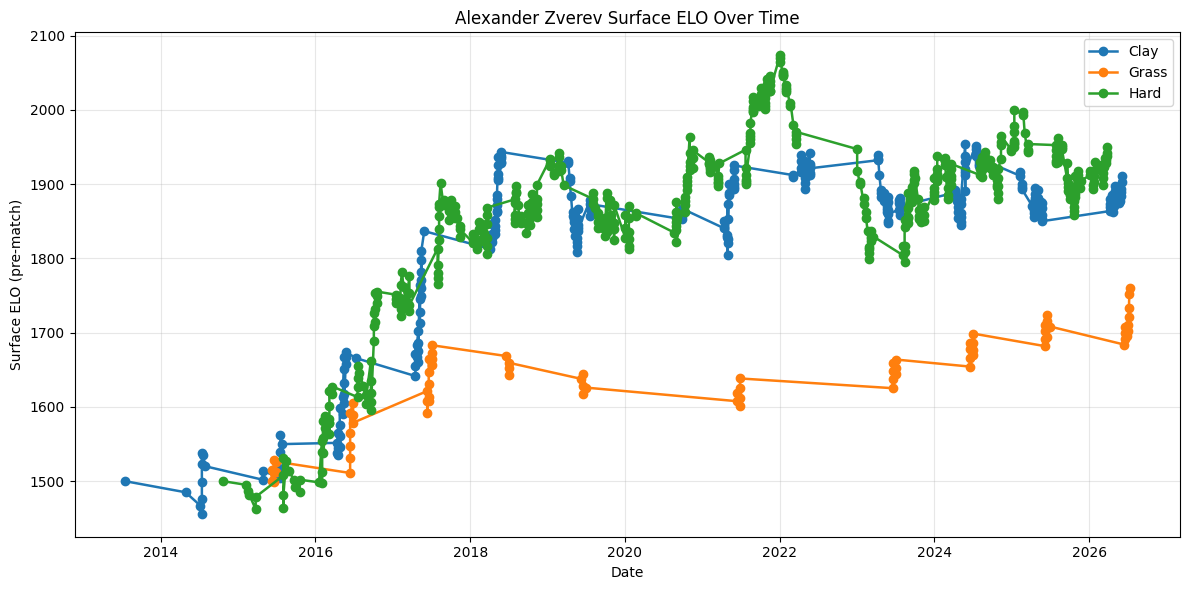

In [92]:
def get_player_surface_elo_history(player_name, df=match_df, surfaces=None):
    player_norm = normalize_name(player_name)

    history = df.copy()
    history["surface_key"] = history["surface"].astype(str).str.strip().str.lower()

    mask = (
        history["winner_name"].map(normalize_name) == player_norm
    ) | (
        history["loser_name"].map(normalize_name) == player_norm
    )

    history = history.loc[mask, [
        "tourney_date",
        "surface",
        "surface_key",
        "winner_name",
        "loser_name",
        "w_surface_elo_pre",
        "l_surface_elo_pre"
    ]].copy()

    if history.empty:
        return history

    history["surface_elo_pre"] = np.where(
        history["winner_name"].map(normalize_name) == player_norm,
        history["w_surface_elo_pre"],
        history["l_surface_elo_pre"]
    )

    if surfaces is not None:
        surfaces = [s.lower() for s in surfaces]
        history = history[history["surface_key"].isin(surfaces)]

    return history.sort_values("tourney_date")


def plot_player_surface_elo_over_time(player_name, df=match_df, surfaces=None, figsize=(12, 6)):
    history = get_player_surface_elo_history(player_name, df=df, surfaces=surfaces)

    if history.empty:
        raise ValueError(f"No surface ELO history found for player: {player_name}")

    if surfaces is None:
        surfaces = sorted(history["surface_key"].dropna().unique())

    fig, ax = plt.subplots(figsize=figsize)

    for surface_key in surfaces:
        sub = history[history["surface_key"] == surface_key]
        if sub.empty:
            continue

        ax.plot(
            sub["tourney_date"],
            sub["surface_elo_pre"],
            marker="o",
            linewidth=1.8,
            label=surface_key.capitalize()
        )

    ax.set_title(f"{player_name} Surface ELO Over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Surface ELO (pre-match)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Example: replace the name below with any player you want to inspect
plot_player_surface_elo_over_time("Alexander Zverev")

### Create neutral_Df

In [36]:
def create_neutral_match_dataset(match_df, seed=42):
    """
    Converts winner/loser match data into neutral Player A / Player B format.

    Player A is randomly assigned to be either the winner or loser.
    The target A_won equals 1 if Player A won, 0 otherwise.
    """
    
    rng = np.random.default_rng(seed)
    winner_is_A = rng.random(len(match_df)) < 0.5
    
    neutral_df = pd.DataFrame({
        "date": match_df["tourney_date"],
        "tourney_id": match_df["tourney_id"],
        "tourney_name": match_df["tourney_name"],
        "surface": match_df["surface"],
        "draw_size": match_df["draw_size"],
        "tourney_level": match_df["tourney_level"],
        "indoor": match_df["indoor"],
        "round": match_df["round"],
        "best_of": match_df["best_of"],
        
        # Player A basic info
        "player_A_id": np.where(winner_is_A, match_df["winner_id"], match_df["loser_id"]),
        "player_A_name": np.where(winner_is_A, match_df["winner_name"], match_df["loser_name"]),
        "player_A_rank": np.where(winner_is_A, match_df["winner_rank"], match_df["loser_rank"]),
        "player_A_rank_points": np.where(winner_is_A, match_df["winner_rank_points"], match_df["loser_rank_points"]),
        "player_A_age": np.where(winner_is_A, match_df["winner_age"], match_df["loser_age"]),
        "player_A_ht": np.where(winner_is_A, match_df["winner_ht"], match_df["loser_ht"]),
        "player_A_hand": np.where(winner_is_A, match_df["winner_hand"], match_df["loser_hand"]),
        
        # Player B basic info
        "player_B_id": np.where(winner_is_A, match_df["loser_id"], match_df["winner_id"]),
        "player_B_name": np.where(winner_is_A, match_df["loser_name"], match_df["winner_name"]),
        "player_B_rank": np.where(winner_is_A, match_df["loser_rank"], match_df["winner_rank"]),
        "player_B_rank_points": np.where(winner_is_A, match_df["loser_rank_points"], match_df["winner_rank_points"]),
        "player_B_age": np.where(winner_is_A, match_df["loser_age"], match_df["winner_age"]),
        "player_B_ht": np.where(winner_is_A, match_df["loser_ht"], match_df["winner_ht"]),
        "player_B_hand": np.where(winner_is_A, match_df["loser_hand"], match_df["winner_hand"]),
        
        # Player A Elo features
        "player_A_elo_pre": np.where(winner_is_A, match_df["w_elo_pre"], match_df["l_elo_pre"]),
        "player_A_surface_elo_pre": np.where(winner_is_A, match_df["w_surface_elo_pre"], match_df["l_surface_elo_pre"]),
        "player_A_score_elo_pre": np.where(winner_is_A, match_df["w_score_elo_pre"], match_df["l_score_elo_pre"]),
        "player_A_score_surface_elo_pre": np.where(winner_is_A, match_df["w_score_surface_elo_pre"], match_df["l_score_surface_elo_pre"]),
        
        # Player B Elo features
        "player_B_elo_pre": np.where(winner_is_A, match_df["l_elo_pre"], match_df["w_elo_pre"]),
        "player_B_surface_elo_pre": np.where(winner_is_A, match_df["l_surface_elo_pre"], match_df["w_surface_elo_pre"]),
        "player_B_score_elo_pre": np.where(winner_is_A, match_df["l_score_elo_pre"], match_df["w_score_elo_pre"]),
        "player_B_score_surface_elo_pre": np.where(winner_is_A, match_df["l_score_surface_elo_pre"], match_df["w_score_surface_elo_pre"]),
        
        # Target
        "A_won": winner_is_A.astype(int)
    })
    
    return neutral_df

In [37]:
neutral_df = create_neutral_match_dataset(match_df, seed=42)

#### Add Rolling Form Columns to netrual_df

In [38]:
form_cols = [
    "last10_win_pct_pre",
    "last20_win_pct_pre",
    "last10_matches_pre",
    "last20_matches_pre",
    "surface_last10_win_pct_pre",
    "surface_last20_win_pct_pre",
    "surface_last10_matches_pre",
    "surface_last20_matches_pre"
]

winner_is_A = neutral_df["A_won"].astype(bool).to_numpy()

for col in form_cols:
    neutral_df[f"player_A_{col}"] = np.where(
        winner_is_A,
        match_df[f"w_{col}"],
        match_df[f"l_{col}"]
    )
    
    neutral_df[f"player_B_{col}"] = np.where(
        winner_is_A,
        match_df[f"l_{col}"],
        match_df[f"w_{col}"]
    )

#### Add ELO differences to neutral_df

In [39]:
neutral_df["elo_diff"] = (
    neutral_df["player_A_elo_pre"] - neutral_df["player_B_elo_pre"]
)

neutral_df["surface_elo_diff"] = (
    neutral_df["player_A_surface_elo_pre"] - neutral_df["player_B_surface_elo_pre"]
)

neutral_df["score_elo_diff"] = (
    neutral_df["player_A_score_elo_pre"] - neutral_df["player_B_score_elo_pre"]
)

neutral_df["score_surface_elo_diff"] = (
    neutral_df["player_A_score_surface_elo_pre"] - neutral_df["player_B_score_surface_elo_pre"]
)

neutral_df["rank_diff"] = (
    neutral_df["player_B_rank"] - neutral_df["player_A_rank"]
)

neutral_df["log_rank_points_A"] = np.log1p(neutral_df["player_A_rank_points"])
neutral_df["log_rank_points_B"] = np.log1p(neutral_df["player_B_rank_points"])

neutral_df["log_rank_points_diff"] = (
    neutral_df["log_rank_points_A"] - neutral_df["log_rank_points_B"]
)

for col in form_cols:
    neutral_df[f"{col}_diff"] = (
        neutral_df[f"player_A_{col}"] - neutral_df[f"player_B_{col}"]
    )

### Prepare Rolling Style Lookup

In [50]:
# ============================================================
# PREPARE ROLLING STYLE LOOKUP TABLE
# ============================================================

date_col = "date" if "date" in neutral_df.columns else "tourney_date"

neutral_df[date_col] = pd.to_datetime(neutral_df[date_col])
rolling_style_snapshots["model_date"] = pd.to_datetime(rolling_style_snapshots["model_date"])

rolling_style_cols = [
    "player_name_norm",
    "model_date",
    "chart_date",
    "serve_points_cum",
    "serve_points_won_cum",
    "return_points_cum",
    "return_points_won_cum",
    "charted_matches_cum",
    "serve_points_won_pct_pre",
    "return_points_won_pct_pre",
    "serve_points_won_pct_shrunk_pre",
    "return_points_won_pct_shrunk_pre",
    "serve_strength_index_pre",
    "return_strength_index_pre",
    "serve_return_balance_pre",
    "total_charted_points_before",
    "has_rolling_style_data"
]

missing_cols = [
    col for col in rolling_style_cols
    if col not in rolling_style_snapshots.columns
]

if missing_cols:
    raise ValueError(f"Missing columns from rolling_style_snapshots: {missing_cols}")

rolling_style_lookup = rolling_style_snapshots[rolling_style_cols].copy()

# Make sure each player-date pair appears only once
rolling_style_lookup = rolling_style_lookup.drop_duplicates(
    subset=["player_name_norm", "model_date"]
)

print("rolling_style_lookup shape:", rolling_style_lookup.shape)
rolling_style_lookup.head()

rolling_style_lookup shape: (51567, 17)


,player_name_norm,model_date,chart_date,serve_points_cum,serve_points_won_cum,return_points_cum,return_points_won_cum,charted_matches_cum,serve_points_won_pct_pre,return_points_won_pct_pre,serve_points_won_pct_shrunk_pre,return_points_won_pct_shrunk_pre,serve_strength_index_pre,return_strength_index_pre,serve_return_balance_pre,total_charted_points_before,has_rolling_style_data
0,aaron gil garcia,2025-09-12,NaT,0.0,0.0,0.0,0.0,0.0,0.642557,0.357443,0.642557,0.357443,0.0,0.0,0.0,0.0,False
1,abdul hazli bin zainuddin,2010-07-09,NaT,0.0,0.0,0.0,0.0,0.0,0.642557,0.357443,0.642557,0.357443,0.0,0.0,0.0,0.0,False
2,abdulhameed alshatti,2014-01-31,NaT,0.0,0.0,0.0,0.0,0.0,0.642557,0.357443,0.642557,0.357443,0.0,0.0,0.0,0.0,False
3,abdulhameed alshatti,2014-04-04,NaT,0.0,0.0,0.0,0.0,0.0,0.642557,0.357443,0.642557,0.357443,0.0,0.0,0.0,0.0,False
4,abdulhamid mubarak,2016-03-04,NaT,0.0,0.0,0.0,0.0,0.0,0.642557,0.357443,0.642557,0.357443,0.0,0.0,0.0,0.0,False


### Merge Rolling Style into neutral_df

In [51]:
# ============================================================
# MERGE ROLLING STYLE FEATURES ONTO NEUTRAL_DF
# ============================================================

neutral_df_with_style = neutral_df.copy()

neutral_df_with_style["model_date"] = pd.to_datetime(neutral_df_with_style[date_col])
neutral_df_with_style["player_A_name_norm"] = neutral_df_with_style["player_A_name"].map(normalize_name)
neutral_df_with_style["player_B_name_norm"] = neutral_df_with_style["player_B_name"].map(normalize_name)

original_rows = len(neutral_df_with_style)

# ----------------------------
# A-player style features
# ----------------------------

A_style_lookup = rolling_style_lookup.rename(columns={
    "player_name_norm": "player_A_name_norm",
    "chart_date": "player_A_style_asof_date",
    "serve_points_cum": "player_A_style_serve_points",
    "serve_points_won_cum": "player_A_style_serve_points_won",
    "return_points_cum": "player_A_style_return_points",
    "return_points_won_cum": "player_A_style_return_points_won",
    "charted_matches_cum": "player_A_style_charted_matches",
    "serve_points_won_pct_pre": "player_A_style_serve_points_won_pct",
    "return_points_won_pct_pre": "player_A_style_return_points_won_pct",
    "serve_points_won_pct_shrunk_pre": "player_A_style_serve_points_won_pct_shrunk",
    "return_points_won_pct_shrunk_pre": "player_A_style_return_points_won_pct_shrunk",
    "serve_strength_index_pre": "player_A_style_serve_strength_index",
    "return_strength_index_pre": "player_A_style_return_strength_index",
    "serve_return_balance_pre": "player_A_style_serve_return_balance",
    "total_charted_points_before": "player_A_style_total_charted_points",
    "has_rolling_style_data": "player_A_has_rolling_style_data"
})

neutral_df_with_style = neutral_df_with_style.merge(
    A_style_lookup,
    on=["player_A_name_norm", "model_date"],
    how="left",
    validate="many_to_one"
)

# ----------------------------
# B-player style features
# ----------------------------

B_style_lookup = rolling_style_lookup.rename(columns={
    "player_name_norm": "player_B_name_norm",
    "chart_date": "player_B_style_asof_date",
    "serve_points_cum": "player_B_style_serve_points",
    "serve_points_won_cum": "player_B_style_serve_points_won",
    "return_points_cum": "player_B_style_return_points",
    "return_points_won_cum": "player_B_style_return_points_won",
    "charted_matches_cum": "player_B_style_charted_matches",
    "serve_points_won_pct_pre": "player_B_style_serve_points_won_pct",
    "return_points_won_pct_pre": "player_B_style_return_points_won_pct",
    "serve_points_won_pct_shrunk_pre": "player_B_style_serve_points_won_pct_shrunk",
    "return_points_won_pct_shrunk_pre": "player_B_style_return_points_won_pct_shrunk",
    "serve_strength_index_pre": "player_B_style_serve_strength_index",
    "return_strength_index_pre": "player_B_style_return_strength_index",
    "serve_return_balance_pre": "player_B_style_serve_return_balance",
    "total_charted_points_before": "player_B_style_total_charted_points",
    "has_rolling_style_data": "player_B_has_rolling_style_data"
})

neutral_df_with_style = neutral_df_with_style.merge(
    B_style_lookup,
    on=["player_B_name_norm", "model_date"],
    how="left",
    validate="many_to_one"
)

if len(neutral_df_with_style) != original_rows:
    raise ValueError(
        f"Row count changed after merge: {original_rows} → {len(neutral_df_with_style)}"
    )

print("neutral_df shape:", neutral_df.shape)
print("neutral_df_with_style shape:", neutral_df_with_style.shape)

neutral_df shape: (47317, 64)
neutral_df_with_style shape: (47317, 97)


### Fill missing style values with neutral defaults

In [53]:
# ============================================================
# FILL MISSING STYLE VALUES WITH NEUTRAL DEFAULTS
# ============================================================

numeric_style_cols = [
    "player_A_style_serve_points",
    "player_A_style_serve_points_won",
    "player_A_style_return_points",
    "player_A_style_return_points_won",
    "player_A_style_charted_matches",
    "player_A_style_serve_points_won_pct",
    "player_A_style_return_points_won_pct",
    "player_A_style_serve_points_won_pct_shrunk",
    "player_A_style_return_points_won_pct_shrunk",
    "player_A_style_serve_strength_index",
    "player_A_style_return_strength_index",
    "player_A_style_serve_return_balance",
    "player_A_style_total_charted_points",
    
    "player_B_style_serve_points",
    "player_B_style_serve_points_won",
    "player_B_style_return_points",
    "player_B_style_return_points_won",
    "player_B_style_charted_matches",
    "player_B_style_serve_points_won_pct",
    "player_B_style_return_points_won_pct",
    "player_B_style_serve_points_won_pct_shrunk",
    "player_B_style_return_points_won_pct_shrunk",
    "player_B_style_serve_strength_index",
    "player_B_style_return_strength_index",
    "player_B_style_serve_return_balance",
    "player_B_style_total_charted_points"
]

for col in numeric_style_cols:
    neutral_df_with_style[col] = neutral_df_with_style[col].fillna(0)

neutral_df_with_style["player_A_has_rolling_style_data"] = (
    neutral_df_with_style["player_A_has_rolling_style_data"].fillna(False)
)

neutral_df_with_style["player_B_has_rolling_style_data"] = (
    neutral_df_with_style["player_B_has_rolling_style_data"].fillna(False)
)

### Matuchup style feautres

In [54]:
# ============================================================
# CREATE STYLE MATCHUP FEATURES
# ============================================================

neutral_df_with_style["style_serve_strength_diff"] = (
    neutral_df_with_style["player_A_style_serve_strength_index"]
    - neutral_df_with_style["player_B_style_serve_strength_index"]
)

neutral_df_with_style["style_return_strength_diff"] = (
    neutral_df_with_style["player_A_style_return_strength_index"]
    - neutral_df_with_style["player_B_style_return_strength_index"]
)

neutral_df_with_style["style_serve_return_balance_diff"] = (
    neutral_df_with_style["player_A_style_serve_return_balance"]
    - neutral_df_with_style["player_B_style_serve_return_balance"]
)

neutral_df_with_style["style_A_serve_vs_B_return_edge"] = (
    neutral_df_with_style["player_A_style_serve_strength_index"]
    - neutral_df_with_style["player_B_style_return_strength_index"]
)

neutral_df_with_style["style_B_serve_vs_A_return_edge"] = (
    neutral_df_with_style["player_B_style_serve_strength_index"]
    - neutral_df_with_style["player_A_style_return_strength_index"]
)

neutral_df_with_style["style_net_serve_return_edge_diff"] = (
    neutral_df_with_style["style_A_serve_vs_B_return_edge"]
    - neutral_df_with_style["style_B_serve_vs_A_return_edge"]
)

neutral_df_with_style["style_total_charted_points_diff"] = (
    np.log1p(neutral_df_with_style["player_A_style_total_charted_points"])
    - np.log1p(neutral_df_with_style["player_B_style_total_charted_points"])
)

neutral_df_with_style["style_charted_matches_diff"] = (
    np.log1p(neutral_df_with_style["player_A_style_charted_matches"])
    - np.log1p(neutral_df_with_style["player_B_style_charted_matches"])
)

ROLLING_STYLE_FEATURE_COLS = [
    "style_serve_strength_diff",
    "style_return_strength_diff",
    "style_net_serve_return_edge_diff"
]

EXTRA_STYLE_DIAGNOSTIC_COLS = [
    "style_serve_return_balance_diff",
    "style_total_charted_points_diff",
    "style_charted_matches_diff"
]

neutral_df_with_style[
    ROLLING_STYLE_FEATURE_COLS + EXTRA_STYLE_DIAGNOSTIC_COLS
].describe()

,style_serve_strength_diff,style_return_strength_diff,style_net_serve_return_edge_diff,style_serve_return_balance_diff,style_total_charted_points_diff,style_charted_matches_diff
count,47317.000000,47317.000000,47317.000000,47317.000000,47317.000000,47317.000000
mean,0.000130,0.000063,0.000193,0.000193,-0.023812,-0.014897
std,0.027502,0.027975,0.036023,0.036023,3.562620,1.642826
min,-0.128251,-0.146737,-0.168080,-0.168080,-11.209818,-6.068426
25%,-0.015701,-0.014171,-0.020345,-0.020345,-1.569231,-1.098612
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.016122,0.014331,0.020805,0.020805,1.509826,1.042025
max,0.126239,0.143787,0.166062,0.166062,11.222520,6.086775


In [56]:
# ============================================================
# ROLLING STYLE COVERAGE IN NEUTRAL_DF
# ============================================================

rolling_style_coverage_summary = pd.Series({
    "A_has_rolling_style_data_rate": neutral_df_with_style["player_A_has_rolling_style_data"].mean(),
    "B_has_rolling_style_data_rate": neutral_df_with_style["player_B_has_rolling_style_data"].mean(),
    "both_have_rolling_style_data_rate": (
        neutral_df_with_style["player_A_has_rolling_style_data"]
        & neutral_df_with_style["player_B_has_rolling_style_data"]
    ).mean(),
    "either_has_rolling_style_data_rate": (
        neutral_df_with_style["player_A_has_rolling_style_data"]
        | neutral_df_with_style["player_B_has_rolling_style_data"]
    ).mean()
})

rolling_style_coverage_summary

A_has_rolling_style_data_rate         0.761840
B_has_rolling_style_data_rate         0.763573
both_have_rolling_style_data_rate     0.648963
either_has_rolling_style_data_rate    0.876450
dtype: float64

In [57]:
# ============================================================
# SANITY CHECK: STYLE FEATURES FOR CURRENT TOP PLAYERS
# ============================================================

current_player_check = neutral_df_with_style[
    neutral_df_with_style["player_A_name"].str.contains(
        "Sinner|Alcaraz|Djokovic|Zverev|Fritz|Shelton|Medvedev|Draper|Musetti|Rune",
        case=False,
        na=False
    )
][[
    "model_date",
    "tourney_name",
    "player_A_name",
    "player_A_style_asof_date",
    "player_A_style_total_charted_points",
    "player_A_style_charted_matches",
    "player_A_style_serve_strength_index",
    "player_A_style_return_strength_index",
    "player_A_style_serve_return_balance",
    "player_A_has_rolling_style_data"
]].sort_values(["player_A_name", "model_date"])

current_player_check.tail(50)

,model_date,tourney_name,player_A_name,player_A_style_asof_date,player_A_style_total_charted_points,player_A_style_charted_matches,player_A_style_serve_strength_index,player_A_style_return_strength_index,player_A_style_serve_return_balance,player_A_has_rolling_style_data
43138,2025-02-03,Dallas,Taylor Fritz,2025-01-18,15825.0,99.0,0.030369,-0.008957,0.021412,True
43200,2025-02-10,Delray Beach,Taylor Fritz,2025-02-05,15926.0,100.0,0.031210,-0.008396,0.022815,True
43419,2025-03-03,Indian Wells Masters,Taylor Fritz,2025-02-05,15926.0,100.0,0.031210,-0.008396,0.022815,True
43514,2025-03-17,Miami Masters,Taylor Fritz,2025-02-05,15926.0,100.0,0.031210,-0.008396,0.022815,True
43546,2025-03-17,Miami Masters,Taylor Fritz,2025-02-05,15926.0,100.0,0.031210,-0.008396,0.022815,True
43569,2025-03-17,Miami Masters,Taylor Fritz,2025-02-05,15926.0,100.0,0.031210,-0.008396,0.022815,True
43823,2025-04-21,Madrid Masters,Taylor Fritz,2025-03-28,16477.0,103.0,0.032907,-0.009342,0.023565,True
43902,2025-05-05,Rome Masters,Taylor Fritz,2025-04-29,16715.0,105.0,0.032526,-0.008723,0.023803,True
44044,2025-05-26,Roland Garros,Taylor Fritz,2025-05-22,16855.0,106.0,0.032686,-0.009363,0.023323,True
44205,2025-06-16,Queen's Club,Taylor Fritz,2025-06-14,17334.0,109.0,0.034297,-0.010724,0.023573,True


### Tournament-date style snapshots

In [43]:
# ============================================================
# BUILD ROLLING STYLE SNAPSHOTS FOR NEUTRAL_DF DATES
# ============================================================

# Pick the date column used by neutral_df
date_col = "date" if "date" in neutral_df.columns else "tourney_date"

neutral_df[date_col] = pd.to_datetime(neutral_df[date_col])
player_match_style["chart_date"] = pd.to_datetime(player_match_style["chart_date"])

# ------------------------------------------------------------
# 1. Collapse charting data to player-day level
# ------------------------------------------------------------

player_day_style = (
    player_match_style
    .groupby(["player_name_norm", "chart_date"], as_index=False)
    .agg(
        player_name=("player_name", "last"),
        serve_points=("serve_points", "sum"),
        serve_points_won=("serve_points_won", "sum"),
        return_points=("return_points", "sum"),
        return_points_won=("return_points_won", "sum"),
        charted_matches=("match_id", "nunique")
    )
)

player_day_style = player_day_style.sort_values(
    ["player_name_norm", "chart_date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Create cumulative style totals through each charting date
# ------------------------------------------------------------

grouped = player_day_style.groupby("player_name_norm", group_keys=False)

player_day_style["serve_points_cum"] = grouped["serve_points"].cumsum()
player_day_style["serve_points_won_cum"] = grouped["serve_points_won"].cumsum()

player_day_style["return_points_cum"] = grouped["return_points"].cumsum()
player_day_style["return_points_won_cum"] = grouped["return_points_won"].cumsum()

player_day_style["charted_matches_cum"] = grouped["charted_matches"].cumsum()

snapshot_source = player_day_style[
    [
        "player_name_norm",
        "player_name",
        "chart_date",
        "serve_points_cum",
        "serve_points_won_cum",
        "return_points_cum",
        "return_points_won_cum",
        "charted_matches_cum"
    ]
].copy()

# ------------------------------------------------------------
# 3. Build only the player-date pairs needed for neutral_df
# ------------------------------------------------------------

A_pairs = neutral_df[
    [date_col, "player_A_name"]
].rename(
    columns={
        date_col: "model_date",
        "player_A_name": "player_name"
    }
)

B_pairs = neutral_df[
    [date_col, "player_B_name"]
].rename(
    columns={
        date_col: "model_date",
        "player_B_name": "player_name"
    }
)

player_date_pairs = pd.concat(
    [A_pairs, B_pairs],
    ignore_index=True
).drop_duplicates()

player_date_pairs["model_date"] = pd.to_datetime(player_date_pairs["model_date"])
player_date_pairs["player_name_norm"] = player_date_pairs["player_name"].map(normalize_name)

# ------------------------------------------------------------
# 4. Merge most recent charting profile strictly before model date
#    Group-by-player version to avoid pandas sorting issues
# ------------------------------------------------------------

merged_groups = []

for player_norm, left_group in player_date_pairs.groupby("player_name_norm"):
    right_group = snapshot_source[
        snapshot_source["player_name_norm"] == player_norm
    ].copy()
    
    left_group = left_group.sort_values("model_date").reset_index(drop=True)
    right_group = right_group.sort_values("chart_date").reset_index(drop=True)
    
    # We only need the cumulative stats from the right side.
    # Drop right-side names to avoid duplicate player_name columns.
    right_group = right_group.drop(
        columns=["player_name_norm", "player_name"],
        errors="ignore"
    )
    
    if right_group.empty:
        temp = left_group.copy()
        temp["chart_date"] = pd.NaT
        temp["serve_points_cum"] = np.nan
        temp["serve_points_won_cum"] = np.nan
        temp["return_points_cum"] = np.nan
        temp["return_points_won_cum"] = np.nan
        temp["charted_matches_cum"] = np.nan
    else:
        temp = pd.merge_asof(
            left_group,
            right_group,
            left_on="model_date",
            right_on="chart_date",
            direction="backward",
            allow_exact_matches=False
        )
    
    merged_groups.append(temp)

rolling_style_snapshots = pd.concat(
    merged_groups,
    ignore_index=True
)

# Safety check: remove any duplicated columns if they somehow remain
rolling_style_snapshots = rolling_style_snapshots.loc[
    :, ~rolling_style_snapshots.columns.duplicated()
].copy()

print("player_day_style shape:", player_day_style.shape)
print("player_date_pairs shape:", player_date_pairs.shape)
print("rolling_style_snapshots shape:", rolling_style_snapshots.shape)

rolling_style_snapshots.head()

player_day_style shape: (11064, 13)
player_date_pairs shape: (51567, 3)
rolling_style_snapshots shape: (51567, 9)


,model_date,player_name,player_name_norm,chart_date,serve_points_cum,serve_points_won_cum,return_points_cum,return_points_won_cum,charted_matches_cum
0,2025-09-12,Aaron Gil Garcia,aaron gil garcia,NaT,NaN,NaN,NaN,NaN,NaN
1,2010-07-09,Abdul-Hazli Bin Zainuddin,abdul hazli bin zainuddin,NaT,NaN,NaN,NaN,NaN,NaN
2,2014-01-31,Abdulhameed Alshatti,abdulhameed alshatti,NaT,NaN,NaN,NaN,NaN,NaN
3,2014-04-04,Abdulhameed Alshatti,abdulhameed alshatti,NaT,NaN,NaN,NaN,NaN,NaN
4,2016-03-04,Abdulhamid Mubarak,abdulhamid mubarak,NaT,NaN,NaN,NaN,NaN,NaN


### IMPORTANT - COLLINEARITY CHECK

ELO and player style could be very collinear

In [58]:
# ============================================================
# CORRELATION CHECK: ROLLING STYLE VS BASELINE FEATURES
# ============================================================

# Use the style feature set we actually care about
ROLLING_STYLE_FEATURE_COLS = [
    "style_serve_strength_diff",
    "style_return_strength_diff",
    "style_serve_return_balance_diff"
]

candidate_existing_features = [
    "elo_diff",
    "surface_elo_diff",
    "score_elo_diff",
    "score_surface_elo_diff",
    "rank_diff",
    "log_rank_points_diff",
    "last10_win_pct_diff",
    "last20_win_pct_diff",
    "surface_last10_win_pct_diff",
    "surface_last20_win_pct_diff"
]

available_existing_features = [
    col for col in candidate_existing_features
    if col in neutral_df_with_style.columns
]

corr_cols = available_existing_features + ROLLING_STYLE_FEATURE_COLS

corr = neutral_df_with_style[corr_cols].corr()

style_vs_existing_corr = corr.loc[
    ROLLING_STYLE_FEATURE_COLS,
    available_existing_features
]

style_vs_existing_corr

,elo_diff,surface_elo_diff,score_elo_diff,score_surface_elo_diff,rank_diff,log_rank_points_diff
style_serve_strength_diff,0.202654,0.210719,0.207137,0.214496,-0.019546,0.112525
style_return_strength_diff,0.179806,0.180798,0.181783,0.183380,-0.004227,0.129767
style_serve_return_balance_diff,0.294356,0.301283,0.299313,0.306172,-0.018208,0.186722


### Build player history from neutral_df

In [170]:
# ============================================================
# PLAYER MATCH HISTORY FOR ROLLING READINESS FEATURES
# ============================================================

import numpy as np
import pandas as pd

date_col = "date" if "date" in neutral_df_with_style.columns else "tourney_date"
neutral_df_with_style[date_col] = pd.to_datetime(neutral_df_with_style[date_col])

SLAM_NAMES = ["Australian Open", "Roland Garros", "Wimbledon", "US Open"]

hist_rows = []

for idx, row in neutral_df_with_style.iterrows():
    if pd.isna(row["A_won"]):
        continue

    match_date = row[date_col]
    surface = row["surface"] if "surface" in neutral_df_with_style.columns else np.nan
    tourney_name = row["tourney_name"]
    is_slam = tourney_name in SLAM_NAMES

    A_norm = normalize_name(row["player_A_name"])
    B_norm = normalize_name(row["player_B_name"])

    A_won = int(row["A_won"])
    B_won = 1 - A_won

    hist_rows.append({
        "player_name_norm": A_norm,
        "match_date": match_date,
        "surface": surface,
        "tourney_name": tourney_name,
        "is_slam": is_slam,
        "won": A_won,
        "match_id": idx
    })

    hist_rows.append({
        "player_name_norm": B_norm,
        "match_date": match_date,
        "surface": surface,
        "tourney_name": tourney_name,
        "is_slam": is_slam,
        "won": B_won,
        "match_id": idx
    })

player_history = pd.DataFrame(hist_rows)

player_history = player_history.sort_values(
    ["player_name_norm", "match_date", "match_id"]
).reset_index(drop=True)

player_history.head()

,player_name_norm,match_date,surface,tourney_name,is_slam,won,match_id
0,aaron gil garcia,2025-09-12,Clay,Davis Cup WG1 R1: CHI vs LUX,False,0,45025
1,abdul hazli bin zainuddin,2010-07-09,Hard,Davis Cup G2 PO: MAS vs POC,False,0,1880
2,abdul hazli bin zainuddin,2010-07-09,Hard,Davis Cup G2 PO: MAS vs POC,False,1,1882
3,abdulhameed alshatti,2014-01-31,Hard,Davis Cup G2 R1: KUW vs INA,False,0,12331
4,abdulhameed alshatti,2014-04-04,Hard,Davis Cup G2 R2: THA vs KUW,False,0,12973


### Build anti-leakage rolilng readiness snapshots

In [171]:
# ============================================================
# ROLLING READINESS FEATURE SNAPSHOTS
# No leakage: only uses history before model_date
# ============================================================

def shrunk_win_pct(wins, matches, prior=0.5, k=8):
    """
    Shrinks small samples toward 50%.
    """
    return (wins + prior * k) / (matches + k)


def build_player_readiness_snapshots(df, player_history):
    """
    Creates rolling player features at every player-date-surface pair needed
    by the match dataframe.
    """

    A_pairs = df[["player_A_name", date_col]].copy()
    A_pairs["player_name_norm"] = A_pairs["player_A_name"].map(normalize_name)
    A_pairs = A_pairs.rename(columns={date_col: "model_date"})
    A_pairs = A_pairs[["player_name_norm", "model_date"]]

    B_pairs = df[["player_B_name", date_col]].copy()
    B_pairs["player_name_norm"] = B_pairs["player_B_name"].map(normalize_name)
    B_pairs = B_pairs.rename(columns={date_col: "model_date"})
    B_pairs = B_pairs[["player_name_norm", "model_date"]]

    player_date_pairs = pd.concat([A_pairs, B_pairs], ignore_index=True)
    player_date_pairs = player_date_pairs.drop_duplicates()

    # Add surface context for that match date/player.
    A_surface = df[["player_A_name", date_col, "surface"]].copy()
    A_surface["player_name_norm"] = A_surface["player_A_name"].map(normalize_name)
    A_surface = A_surface.rename(columns={date_col: "model_date"})
    A_surface = A_surface[["player_name_norm", "model_date", "surface"]]

    B_surface = df[["player_B_name", date_col, "surface"]].copy()
    B_surface["player_name_norm"] = B_surface["player_B_name"].map(normalize_name)
    B_surface = B_surface.rename(columns={date_col: "model_date"})
    B_surface = B_surface[["player_name_norm", "model_date", "surface"]]

    surface_pairs = pd.concat([A_surface, B_surface], ignore_index=True)
    surface_pairs = surface_pairs.drop_duplicates()

    player_date_pairs = player_date_pairs.merge(
        surface_pairs,
        on=["player_name_norm", "model_date"],
        how="left"
    ).drop_duplicates()

    snapshot_rows = []

    for player, pairs in player_date_pairs.groupby("player_name_norm"):
        hist = player_history[
            player_history["player_name_norm"] == player
        ].copy()

        pairs = pairs.sort_values("model_date").copy()

        if hist.empty:
            for _, pair in pairs.iterrows():
                snapshot_rows.append({
                    "player_name_norm": player,
                    "model_date": pair["model_date"],
                    "surface": pair["surface"],
                    "days_since_last_match_pre": 999,
                    "matches_last_30_pre": 0,
                    "matches_last_90_pre": 0,
                    "win_pct_last_90_pre": 0.5,
                    "surface_matches_last_365_pre": 0,
                    "surface_win_pct_last_365_pre": 0.5,
                    "slam_matches_last_3yr_pre": 0,
                    "slam_win_pct_last_3yr_pre": 0.5
                })
            continue

        hist = hist.sort_values("match_date").reset_index(drop=True)
        dates = hist["match_date"].values.astype("datetime64[ns]")
        wins = hist["won"].values
        surfaces = hist["surface"].values
        is_slam = hist["is_slam"].values

        for _, pair in pairs.iterrows():
            model_date = np.datetime64(pair["model_date"])
            current_surface = pair["surface"]

            # History strictly before model date
            end_idx = np.searchsorted(dates, model_date, side="left")
            hist_before = hist.iloc[:end_idx]

            if len(hist_before) == 0:
                days_since_last = 999
            else:
                last_date = hist_before["match_date"].max()
                days_since_last = (pd.Timestamp(model_date) - last_date).days

            def window_stats(days):
                start_date = pd.Timestamp(model_date) - pd.Timedelta(days=days)
                window = hist_before[hist_before["match_date"] >= start_date]
                return len(window), window["won"].sum()

            matches_30, wins_30 = window_stats(30)
            matches_90, wins_90 = window_stats(90)

            # Surface-specific last 365 days
            start_365 = pd.Timestamp(model_date) - pd.Timedelta(days=365)
            surface_window = hist_before[
                (hist_before["match_date"] >= start_365)
                & (hist_before["surface"] == current_surface)
            ]

            surface_matches_365 = len(surface_window)
            surface_wins_365 = surface_window["won"].sum()

            # Slam-specific last 3 years
            start_3yr = pd.Timestamp(model_date) - pd.Timedelta(days=365 * 3)
            slam_window = hist_before[
                (hist_before["match_date"] >= start_3yr)
                & (hist_before["is_slam"])
            ]

            slam_matches_3yr = len(slam_window)
            slam_wins_3yr = slam_window["won"].sum()

            snapshot_rows.append({
                "player_name_norm": player,
                "model_date": pd.Timestamp(model_date),
                "surface": current_surface,

                "days_since_last_match_pre": min(days_since_last, 999),

                "matches_last_30_pre": matches_30,
                "matches_last_90_pre": matches_90,
                "win_pct_last_90_pre": shrunk_win_pct(wins_90, matches_90, k=8),

                "surface_matches_last_365_pre": surface_matches_365,
                "surface_win_pct_last_365_pre": shrunk_win_pct(
                    surface_wins_365,
                    surface_matches_365,
                    k=8
                ),

                "slam_matches_last_3yr_pre": slam_matches_3yr,
                "slam_win_pct_last_3yr_pre": shrunk_win_pct(
                    slam_wins_3yr,
                    slam_matches_3yr,
                    k=8
                )
            })

    snapshots = pd.DataFrame(snapshot_rows)

    return snapshots


player_readiness_snapshots = build_player_readiness_snapshots(
    neutral_df_with_style,
    player_history
)

player_readiness_snapshots.head()

,player_name_norm,model_date,surface,days_since_last_match_pre,matches_last_30_pre,matches_last_90_pre,win_pct_last_90_pre,surface_matches_last_365_pre,surface_win_pct_last_365_pre,slam_matches_last_3yr_pre,slam_win_pct_last_3yr_pre
0,aaron gil garcia,2025-09-12,Clay,999,0,0,0.500000,0,0.500000,0,0.5
1,abdul hazli bin zainuddin,2010-07-09,Hard,999,0,0,0.500000,0,0.500000,0,0.5
2,abdulhameed alshatti,2014-01-31,Hard,999,0,0,0.500000,0,0.500000,0,0.5
3,abdulhameed alshatti,2014-04-04,Hard,63,0,1,0.444444,1,0.444444,0,0.5
4,abdulhamid mubarak,2016-03-04,Clay,999,0,0,0.500000,0,0.500000,0,0.5


### Merge readiness features into neutral_df

In [172]:
# ============================================================
# MERGE READINESS FEATURES INTO MATCH DATA
# ============================================================

readiness_feature_cols = [
    "days_since_last_match_pre",
    "matches_last_30_pre",
    "matches_last_90_pre",
    "win_pct_last_90_pre",
    "surface_matches_last_365_pre",
    "surface_win_pct_last_365_pre",
    "slam_matches_last_3yr_pre",
    "slam_win_pct_last_3yr_pre"
]

readiness_lookup = player_readiness_snapshots[
    ["player_name_norm", "model_date"] + readiness_feature_cols
].drop_duplicates()

df_readiness = neutral_df_with_style.copy()

df_readiness["model_date"] = pd.to_datetime(df_readiness[date_col])
df_readiness["player_A_name_norm"] = df_readiness["player_A_name"].map(normalize_name)
df_readiness["player_B_name_norm"] = df_readiness["player_B_name"].map(normalize_name)

A_lookup = readiness_lookup.rename(
    columns={
        "player_name_norm": "player_A_name_norm",
        **{col: f"player_A_{col}" for col in readiness_feature_cols}
    }
)

B_lookup = readiness_lookup.rename(
    columns={
        "player_name_norm": "player_B_name_norm",
        **{col: f"player_B_{col}" for col in readiness_feature_cols}
    }
)

df_readiness = df_readiness.merge(
    A_lookup,
    on=["player_A_name_norm", "model_date"],
    how="left"
)

df_readiness = df_readiness.merge(
    B_lookup,
    on=["player_B_name_norm", "model_date"],
    how="left"
)

for col in readiness_feature_cols:
    df_readiness[f"player_A_{col}"] = df_readiness[f"player_A_{col}"].fillna(
        999 if "days_since" in col else 0.5 if "win_pct" in col else 0
    )
    df_readiness[f"player_B_{col}"] = df_readiness[f"player_B_{col}"].fillna(
        999 if "days_since" in col else 0.5 if "win_pct" in col else 0
    )

### Create readiness diff features

In [173]:
# ============================================================
# READINESS DIFF FEATURES
# Positive generally means player A has more of that feature
# ============================================================

df_readiness["days_since_last_match_diff"] = (
    df_readiness["player_A_days_since_last_match_pre"]
    - df_readiness["player_B_days_since_last_match_pre"]
)

df_readiness["matches_last_30_diff"] = (
    df_readiness["player_A_matches_last_30_pre"]
    - df_readiness["player_B_matches_last_30_pre"]
)

df_readiness["matches_last_90_diff"] = (
    df_readiness["player_A_matches_last_90_pre"]
    - df_readiness["player_B_matches_last_90_pre"]
)

df_readiness["win_pct_last_90_diff"] = (
    df_readiness["player_A_win_pct_last_90_pre"]
    - df_readiness["player_B_win_pct_last_90_pre"]
)

df_readiness["surface_matches_last_365_diff"] = (
    df_readiness["player_A_surface_matches_last_365_pre"]
    - df_readiness["player_B_surface_matches_last_365_pre"]
)

df_readiness["surface_win_pct_last_365_diff"] = (
    df_readiness["player_A_surface_win_pct_last_365_pre"]
    - df_readiness["player_B_surface_win_pct_last_365_pre"]
)

df_readiness["slam_matches_last_3yr_diff"] = (
    df_readiness["player_A_slam_matches_last_3yr_pre"]
    - df_readiness["player_B_slam_matches_last_3yr_pre"]
)

df_readiness["slam_win_pct_last_3yr_diff"] = (
    df_readiness["player_A_slam_win_pct_last_3yr_pre"]
    - df_readiness["player_B_slam_win_pct_last_3yr_pre"]
)

READINESS_FEATURE_COLS = [
    "days_since_last_match_diff",
    "matches_last_30_diff",
    "matches_last_90_diff",
    "win_pct_last_90_diff",
    "surface_matches_last_365_diff",
    "surface_win_pct_last_365_diff",
    "slam_matches_last_3yr_diff",
    "slam_win_pct_last_3yr_diff"
]

df_readiness[READINESS_FEATURE_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_match_diff,47321.0,-0.518861,210.664785,-998.000000,-7.000000,0.0,7.000000,998.000000
matches_last_30_diff,47321.0,-0.007756,3.343374,-16.000000,-2.000000,0.0,2.000000,16.000000
matches_last_90_diff,47321.0,-0.005093,7.381487,-38.000000,-5.000000,0.0,5.000000,36.000000
win_pct_last_90_diff,47321.0,0.000376,0.126671,-0.553419,-0.078947,0.0,0.079545,0.505882
surface_matches_last_365_diff,47321.0,-0.061981,15.794173,-67.000000,-9.000000,0.0,9.000000,66.000000
surface_win_pct_last_365_diff,47321.0,-0.000427,0.133310,-0.561996,-0.083916,0.0,0.083333,0.560000
slam_matches_last_3yr_diff,47321.0,-0.158936,17.796469,-78.000000,-10.000000,0.0,10.000000,81.000000
slam_win_pct_last_3yr_diff,47321.0,-0.000791,0.156106,-0.606573,-0.097179,0.0,0.095238,0.610860


### Test early roudn perfromance only

In [174]:
# ============================================================
# EARLY ROUND FEATURE TEST
# ============================================================

EARLY_ROUNDS = ["R128", "R64", "R32"]

feature_sets_readiness = {
    "baseline": BASELINE_FEATURE_COLS,
    "baseline_plus_readiness": BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
    "baseline_plus_style": BASELINE_FEATURE_COLS + STYLE_FEATURE_COLS_V2,
    "baseline_plus_style_readiness": BASELINE_FEATURE_COLS + STYLE_FEATURE_COLS_V2 + READINESS_FEATURE_COLS
}

early_round_results = []

for name, features in feature_sets_readiness.items():
    temp_df = df_readiness[df_readiness["round"].isin(EARLY_ROUNDS)].copy()

    result = evaluate_model_time_split(
        df=temp_df,
        feature_cols=features,
        cutoff_date="2023-01-01"
    )

    result["model"] = name
    result["n_features"] = len(features)

    early_round_results.append(result)

early_round_results_df = pd.DataFrame(early_round_results)

early_round_results_df[
    ["model", "n_features", "train_rows", "test_rows", "accuracy", "log_loss", "brier"]
].sort_values("log_loss")

,model,n_features,train_rows,test_rows,accuracy,log_loss,brier
1,baseline_plus_readiness,24,20681,6317,0.658857,0.611852,0.212497
3,baseline_plus_style_readiness,26,20681,6317,0.658857,0.611982,0.212538
0,baseline,16,20681,6317,0.656641,0.613901,0.213378
2,baseline_plus_style,18,20681,6317,0.657116,0.613921,0.213371


### Year by year early rounds test

In [175]:
# ============================================================
# YEAR-BY-YEAR EARLY ROUND READINESS TEST
# ============================================================

EARLY_ROUNDS = ["R128", "R64", "R32"]

YEAR_BY_YEAR_FEATURE_SETS = {
    "baseline": BASELINE_FEATURE_COLS,
    "readiness": BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
}

early_yearly_results = []

for test_year in sorted(df_readiness[date_col].dt.year.unique()):
    if test_year < 2021:
        continue

    train = df_readiness[
        (df_readiness[date_col].dt.year < test_year)
        & (df_readiness["round"].isin(EARLY_ROUNDS))
        & (df_readiness["A_won"].notna())
    ].copy()

    test = df_readiness[
        (df_readiness[date_col].dt.year == test_year)
        & (df_readiness["round"].isin(EARLY_ROUNDS))
        & (df_readiness["A_won"].notna())
    ].copy()

    if len(train) == 0 or len(test) == 0:
        continue

    for model_name, feature_cols in YEAR_BY_YEAR_FEATURE_SETS.items():
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(max_iter=5000, C=0.1))
        ])

        X_train = train[feature_cols]
        y_train = train["A_won"].astype(int)

        X_test = test[feature_cols]
        y_test = test["A_won"].astype(int)

        model.fit(X_train, y_train)

        pred_prob = model.predict_proba(X_test)[:, 1]
        pred_class = (pred_prob >= 0.5).astype(int)

        early_yearly_results.append({
            "test_year": test_year,
            "model": model_name,
            "train_rows": len(train),
            "test_rows": len(test),
            "accuracy": accuracy_score(y_test, pred_class),
            "log_loss": log_loss(y_test, pred_prob),
            "brier": brier_score_loss(y_test, pred_prob)
        })

early_yearly_results_df = pd.DataFrame(early_yearly_results)

early_yearly_pivot = early_yearly_results_df.pivot(
    index="test_year",
    columns="model",
    values=["accuracy", "log_loss", "brier"]
)

early_yearly_pivot

accuracy            log_loss               brier          
model      baseline readiness  baseline readiness  baseline readiness
test_year                                                            
2021       0.666262  0.664442  0.598811  0.595602  0.207634  0.206254
2022       0.674293  0.677303  0.595364  0.593894  0.204992  0.204454
2023       0.660301  0.657986  0.619158  0.615736  0.215308  0.214067
2024       0.657428  0.657428  0.597929  0.597957  0.206906  0.206920
2025       0.645312  0.647641  0.628549  0.626444  0.219999  0.218835
2026       0.676030  0.678839  0.606262  0.603539  0.209665  0.208496

In [176]:
# ============================================================
# READINESS DELTAS BY YEAR
# Negative log_loss_delta / brier_delta is good
# Positive accuracy_delta is good
# ============================================================

baseline_yearly = early_yearly_results_df[
    early_yearly_results_df["model"] == "baseline"
].copy()

readiness_yearly = early_yearly_results_df[
    early_yearly_results_df["model"] == "readiness"
].copy()

readiness_yearly_delta = baseline_yearly.merge(
    readiness_yearly,
    on="test_year",
    suffixes=("_baseline", "_readiness")
)

readiness_yearly_delta["accuracy_delta"] = (
    readiness_yearly_delta["accuracy_readiness"]
    - readiness_yearly_delta["accuracy_baseline"]
)

readiness_yearly_delta["log_loss_delta"] = (
    readiness_yearly_delta["log_loss_readiness"]
    - readiness_yearly_delta["log_loss_baseline"]
)

readiness_yearly_delta["brier_delta"] = (
    readiness_yearly_delta["brier_readiness"]
    - readiness_yearly_delta["brier_baseline"]
)

readiness_yearly_delta[[
    "test_year",
    "accuracy_baseline",
    "accuracy_readiness",
    "accuracy_delta",
    "log_loss_baseline",
    "log_loss_readiness",
    "log_loss_delta",
    "brier_baseline",
    "brier_readiness",
    "brier_delta"
]]

,test_year,accuracy_baseline,accuracy_readiness,accuracy_delta,log_loss_baseline,log_loss_readiness,log_loss_delta,brier_baseline,brier_readiness,brier_delta
0,2021,0.666262,0.664442,-0.001820,0.598811,0.595602,-0.003209,0.207634,0.206254,-0.001380
1,2022,0.674293,0.677303,0.003010,0.595364,0.593894,-0.001470,0.204992,0.204454,-0.000538
2,2023,0.660301,0.657986,-0.002315,0.619158,0.615736,-0.003422,0.215308,0.214067,-0.001241
3,2024,0.657428,0.657428,0.000000,0.597929,0.597957,0.000028,0.206906,0.206920,0.000014
4,2025,0.645312,0.647641,0.002330,0.628549,0.626444,-0.002104,0.219999,0.218835,-0.001163
5,2026,0.676030,0.678839,0.002809,0.606262,0.603539,-0.002723,0.209665,0.208496,-0.001169


In [177]:
pd.DataFrame({
    "metric": [
        "accuracy_years_improved",
        "log_loss_years_improved",
        "brier_years_improved",
        "avg_accuracy_delta",
        "avg_log_loss_delta",
        "avg_brier_delta"
    ],
    "value": [
        (readiness_yearly_delta["accuracy_delta"] > 0).sum(),
        (readiness_yearly_delta["log_loss_delta"] < 0).sum(),
        (readiness_yearly_delta["brier_delta"] < 0).sum(),
        readiness_yearly_delta["accuracy_delta"].mean(),
        readiness_yearly_delta["log_loss_delta"].mean(),
        readiness_yearly_delta["brier_delta"].mean()
    ]
})

,metric,value
0,accuracy_years_improved,3.000000
1,log_loss_years_improved,5.000000
2,brier_years_improved,5.000000
3,avg_accuracy_delta,0.000669
4,avg_log_loss_delta,-0.002150
5,avg_brier_delta,-0.000913


In [178]:
# ============================================================
# MATCHUP FEATURE HELPER V3
# Supports baseline + style + readiness features
# ============================================================

import numpy as np
import pandas as pd


def get_value(profile, key, default=np.nan):
    return profile.get(key, default)


FEATURE_TO_PROFILE_KEYS = {
    # Baseline Elo/rank/body features
    "elo_diff": ("elo_pre", "elo_pre"),
    "surface_elo_diff": ("surface_elo_pre", "surface_elo_pre"),
    "score_elo_diff": ("score_elo_pre", "score_elo_pre"),
    "score_surface_elo_diff": ("score_surface_elo_pre", "score_surface_elo_pre"),
    "rank_diff": ("rank", "rank"),
    "age_diff": ("age", "age"),
    "height_diff": ("ht", "ht"),

    # Recent form
    "last10_win_pct_diff": ("last10_win_pct_pre", "last10_win_pct_pre"),
    "last20_win_pct_diff": ("last20_win_pct_pre", "last20_win_pct_pre"),
    "last10_matches_diff": ("last10_matches_pre", "last10_matches_pre"),
    "last20_matches_diff": ("last20_matches_pre", "last20_matches_pre"),
    "surface_last10_win_pct_diff": ("surface_last10_win_pct_pre", "surface_last10_win_pct_pre"),
    "surface_last20_win_pct_diff": ("surface_last20_win_pct_pre", "surface_last20_win_pct_pre"),
    "surface_last10_matches_diff": ("surface_last10_matches_pre", "surface_last10_matches_pre"),
    "surface_last20_matches_diff": ("surface_last20_matches_pre", "surface_last20_matches_pre"),

    # Style
    "style_serve_strength_diff": ("style_serve_strength_index", "style_serve_strength_index"),
    "style_return_strength_diff": ("style_return_strength_index", "style_return_strength_index"),
    "style_serve_return_balance_diff": ("style_serve_return_balance", "style_serve_return_balance"),

    # Readiness
    "days_since_last_match_diff": ("days_since_last_match_pre", "days_since_last_match_pre"),
    "matches_last_30_diff": ("matches_last_30_pre", "matches_last_30_pre"),
    "matches_last_90_diff": ("matches_last_90_pre", "matches_last_90_pre"),
    "win_pct_last_90_diff": ("win_pct_last_90_pre", "win_pct_last_90_pre"),
    "surface_matches_last_365_diff": ("surface_matches_last_365_pre", "surface_matches_last_365_pre"),
    "surface_win_pct_last_365_diff": ("surface_win_pct_last_365_pre", "surface_win_pct_last_365_pre"),
    "slam_matches_last_3yr_diff": ("slam_matches_last_3yr_pre", "slam_matches_last_3yr_pre"),
    "slam_win_pct_last_3yr_diff": ("slam_win_pct_last_3yr_pre", "slam_win_pct_last_3yr_pre"),
}


def make_matchup_feature_row(player_A_norm, player_B_norm, profile_lookup, feature_cols):
    """
    Creates one feature row for a hypothetical matchup:
    player_A vs player_B.

    Uses pre-tournament player profiles from R128.
    """

    A = profile_lookup[player_A_norm]
    B = profile_lookup[player_B_norm]

    row = {}

    for feature in feature_cols:

        if feature == "log_rank_points_diff":
            row[feature] = (
                np.log1p(get_value(A, "rank_points"))
                - np.log1p(get_value(B, "rank_points"))
            )

        elif feature in FEATURE_TO_PROFILE_KEYS:
            A_key, B_key = FEATURE_TO_PROFILE_KEYS[feature]
            row[feature] = get_value(A, A_key) - get_value(B, B_key)

        else:
            raise ValueError(f"No rule for feature: {feature}")

    return pd.DataFrame([row], columns=feature_cols)


def predict_matchup(player_A_norm, player_B_norm, profile_lookup, model, feature_cols):
    """
    Predicts a hypothetical matchup.
    Returns the model-favored winner and probability.
    """

    X = make_matchup_feature_row(
        player_A_norm=player_A_norm,
        player_B_norm=player_B_norm,
        profile_lookup=profile_lookup,
        feature_cols=feature_cols
    )

    prob_A = model.predict_proba(X)[0, 1]

    if prob_A >= 0.5:
        winner_norm = player_A_norm
        loser_norm = player_B_norm
        win_prob = prob_A
    else:
        winner_norm = player_B_norm
        loser_norm = player_A_norm
        win_prob = 1 - prob_A

    return {
        "winner_norm": winner_norm,
        "loser_norm": loser_norm,
        "prob_winner": win_prob,
        "prob_A": prob_A
    }

## ___________________________________________________________________________

## Testing style features

### General Baseline vs style model test

In [59]:
# ============================================================
# DEFINE BASELINE MODEL FEATURE COLUMNS
# ============================================================

import numpy as np

# Create diff features if they do not already exist
diff_specs = {
    "elo_diff": ("player_A_elo_pre", "player_B_elo_pre"),
    "surface_elo_diff": ("player_A_surface_elo_pre", "player_B_surface_elo_pre"),
    "score_elo_diff": ("player_A_score_elo_pre", "player_B_score_elo_pre"),
    "score_surface_elo_diff": ("player_A_score_surface_elo_pre", "player_B_score_surface_elo_pre"),
    "rank_diff": ("player_A_rank", "player_B_rank"),
    "log_rank_points_diff": ("player_A_rank_points", "player_B_rank_points"),
    "age_diff": ("player_A_age", "player_B_age"),
    "height_diff": ("player_A_ht", "player_B_ht"),
    "last10_win_pct_diff": ("player_A_last10_win_pct_pre", "player_B_last10_win_pct_pre"),
    "last20_win_pct_diff": ("player_A_last20_win_pct_pre", "player_B_last20_win_pct_pre"),
    "last10_matches_diff": ("player_A_last10_matches_pre", "player_B_last10_matches_pre"),
    "last20_matches_diff": ("player_A_last20_matches_pre", "player_B_last20_matches_pre"),
    "surface_last10_win_pct_diff": ("player_A_surface_last10_win_pct_pre", "player_B_surface_last10_win_pct_pre"),
    "surface_last20_win_pct_diff": ("player_A_surface_last20_win_pct_pre", "player_B_surface_last20_win_pct_pre"),
    "surface_last10_matches_diff": ("player_A_surface_last10_matches_pre", "player_B_surface_last10_matches_pre"),
    "surface_last20_matches_diff": ("player_A_surface_last20_matches_pre", "player_B_surface_last20_matches_pre"),
}

for diff_col, (a_col, b_col) in diff_specs.items():
    if diff_col not in neutral_df_with_style.columns:
        if a_col in neutral_df_with_style.columns and b_col in neutral_df_with_style.columns:
            if diff_col == "log_rank_points_diff":
                neutral_df_with_style[diff_col] = (
                    np.log1p(neutral_df_with_style[a_col])
                    - np.log1p(neutral_df_with_style[b_col])
                )
            else:
                neutral_df_with_style[diff_col] = (
                    neutral_df_with_style[a_col]
                    - neutral_df_with_style[b_col]
                )

# Baseline features from the original model idea
candidate_baseline_features = [
    "elo_diff",
    "surface_elo_diff",
    "score_elo_diff",
    "score_surface_elo_diff",
    "rank_diff",
    "log_rank_points_diff",
    "age_diff",
    "height_diff",
    "last10_win_pct_diff",
    "last20_win_pct_diff",
    "last10_matches_diff",
    "last20_matches_diff",
    "surface_last10_win_pct_diff",
    "surface_last20_win_pct_diff",
    "surface_last10_matches_diff",
    "surface_last20_matches_diff",
]

BASELINE_FEATURE_COLS = [
    col for col in candidate_baseline_features
    if col in neutral_df_with_style.columns
]

print("Baseline feature columns:")
for col in BASELINE_FEATURE_COLS:
    print(" -", col)

print("\nNumber of baseline features:", len(BASELINE_FEATURE_COLS))

Baseline feature columns:
 - elo_diff
 - surface_elo_diff
 - score_elo_diff
 - score_surface_elo_diff
 - rank_diff
 - log_rank_points_diff
 - age_diff
 - height_diff
 - last10_win_pct_diff
 - last20_win_pct_diff
 - last10_matches_diff
 - last20_matches_diff
 - surface_last10_win_pct_diff
 - surface_last20_win_pct_diff
 - surface_last10_matches_diff
 - surface_last20_matches_diff

Number of baseline features: 16


In [60]:
# ============================================================
# BASELINE VS STYLE MODEL: SIMPLE TIME-SPLIT TEST
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

date_col = "date" if "date" in neutral_df_with_style.columns else "tourney_date"

neutral_df_with_style[date_col] = pd.to_datetime(neutral_df_with_style[date_col])

STYLE_FEATURE_COLS_V1 = [
    "style_serve_strength_diff",
    "style_return_strength_diff",
    "style_serve_return_balance_diff"
]

STYLE_FEATURE_COLS_V2 = [
    "style_serve_strength_diff",
    "style_return_strength_diff"
]

feature_sets = {
    "baseline": BASELINE_FEATURE_COLS,
    "style_v1": BASELINE_FEATURE_COLS + STYLE_FEATURE_COLS_V1,
    "style_v2": BASELINE_FEATURE_COLS + STYLE_FEATURE_COLS_V2
}

def evaluate_model_time_split(df, feature_cols, cutoff_date="2023-01-01"):
    cutoff_date = pd.to_datetime(cutoff_date)
    
    train = df[
        (df[date_col] < cutoff_date)
        & df["A_won"].notna()
    ].copy()
    
    test = df[
        (df[date_col] >= cutoff_date)
        & df["A_won"].notna()
    ].copy()
    
    X_train = train[feature_cols]
    y_train = train["A_won"].astype(int)
    
    X_test = test[feature_cols]
    y_test = test["A_won"].astype(int)
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000))
    ])
    
    model.fit(X_train, y_train)
    
    pred_prob = model.predict_proba(X_test)[:, 1]
    pred_class = (pred_prob >= 0.5).astype(int)
    
    return {
        "train_rows": len(train),
        "test_rows": len(test),
        "accuracy": accuracy_score(y_test, pred_class),
        "log_loss": log_loss(y_test, pred_prob),
        "brier": brier_score_loss(y_test, pred_prob)
    }

results = []

for model_name, cols in feature_sets.items():
    result = evaluate_model_time_split(
        neutral_df_with_style,
        cols,
        cutoff_date="2023-01-01"
    )
    result["model"] = model_name
    result["n_features"] = len(cols)
    results.append(result)

simple_model_comparison = pd.DataFrame(results)[[
    "model",
    "n_features",
    "train_rows",
    "test_rows",
    "accuracy",
    "log_loss",
    "brier"
]]

simple_model_comparison

,model,n_features,train_rows,test_rows,accuracy,log_loss,brier
0,baseline,16,36601,10716,0.654442,0.616594,0.214385
1,style_v1,19,36601,10716,0.654349,0.616438,0.214313
2,style_v2,18,36601,10716,0.654162,0.616418,0.214305


### Grand Slam Only Baseline vs Model Test

In [61]:
# ============================================================
# BASELINE VS STYLE MODEL: GRAND SLAM MATCHES ONLY
# ============================================================

slam_names = [
    "Australian Open",
    "Roland Garros",
    "Wimbledon",
    "US Open"
]

slam_df = neutral_df_with_style[
    neutral_df_with_style["tourney_name"].isin(slam_names)
].copy()

slam_results = []

for model_name, cols in feature_sets.items():
    result = evaluate_model_time_split(
        slam_df,
        cols,
        cutoff_date="2023-01-01"
    )
    result["model"] = model_name
    result["n_features"] = len(cols)
    slam_results.append(result)

slam_model_comparison = pd.DataFrame(slam_results)[[
    "model",
    "n_features",
    "train_rows",
    "test_rows",
    "accuracy",
    "log_loss",
    "brier"
]]

slam_model_comparison

,model,n_features,train_rows,test_rows,accuracy,log_loss,brier
0,baseline,16,6477,1905,0.714961,0.545907,0.184231
1,style_v1,19,6477,1905,0.713911,0.545906,0.184237
2,style_v2,18,6477,1905,0.713911,0.545886,0.184231


### Early Round Grand Slam Matches Test

In [62]:
# ============================================================
# BASELINE VS STYLE MODEL: GRAND SLAM EARLY ROUNDS ONLY
# ============================================================

early_rounds = ["R128", "R64", "R32"]

slam_early_df = slam_df[
    slam_df["round"].isin(early_rounds)
].copy()

early_results = []

for model_name, cols in feature_sets.items():
    result = evaluate_model_time_split(
        slam_early_df,
        cols,
        cutoff_date="2023-01-01"
    )
    result["model"] = model_name
    result["n_features"] = len(cols)
    early_results.append(result)

slam_early_model_comparison = pd.DataFrame(early_results)[[
    "model",
    "n_features",
    "train_rows",
    "test_rows",
    "accuracy",
    "log_loss",
    "brier"
]]

slam_early_model_comparison

,model,n_features,train_rows,test_rows,accuracy,log_loss,brier
0,baseline,16,5712,1680,0.702976,0.561721,0.190646
1,style_v1,19,5712,1680,0.705357,0.562929,0.190934
2,style_v2,18,5712,1680,0.704762,0.562890,0.190922


### Close Grand Slam Matches

In [63]:
# ============================================================
# COMPARE MODELS ON CLOSE GRAND SLAM MATCHES
# ============================================================

def get_model_predictions_time_split(df, feature_cols, cutoff_date="2023-01-01"):
    cutoff_date = pd.to_datetime(cutoff_date)
    
    train = df[
        (df[date_col] < cutoff_date)
        & df["A_won"].notna()
    ].copy()
    
    test = df[
        (df[date_col] >= cutoff_date)
        & df["A_won"].notna()
    ].copy()
    
    X_train = train[feature_cols]
    y_train = train["A_won"].astype(int)
    
    X_test = test[feature_cols]
    y_test = test["A_won"].astype(int)
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000))
    ])
    
    model.fit(X_train, y_train)
    
    out = test.copy()
    out["pred_prob"] = model.predict_proba(X_test)[:, 1]
    out["pred_class"] = (out["pred_prob"] >= 0.5).astype(int)
    out["actual"] = y_test.values
    
    return out


baseline_preds = get_model_predictions_time_split(
    slam_df,
    feature_sets["baseline"],
    cutoff_date="2023-01-01"
)

style_v2_preds = get_model_predictions_time_split(
    slam_df,
    feature_sets["style_v2"],
    cutoff_date="2023-01-01"
)

close_mask = baseline_preds["pred_prob"].between(0.40, 0.60)

close_results = []

for model_name, preds in [
    ("baseline", baseline_preds),
    ("style_v2", style_v2_preds)
]:
    close = preds.loc[close_mask].copy()
    
    close_results.append({
        "model": model_name,
        "rows": len(close),
        "accuracy": accuracy_score(close["actual"], close["pred_class"]),
        "log_loss": log_loss(close["actual"], close["pred_prob"]),
        "brier": brier_score_loss(close["actual"], close["pred_prob"])
    })

close_model_comparison = pd.DataFrame(close_results)

close_model_comparison

,model,rows,accuracy,log_loss,brier
0,baseline,394,0.507614,0.698159,0.252470
1,style_v2,394,0.502538,0.700527,0.253627


### Early Grand Slam Matches where both players have style data

In [64]:
# ============================================================
# GRAND SLAM EARLY ROUNDS: BOTH PLAYERS HAVE STYLE DATA
# ============================================================

slam_early_both_style_df = slam_early_df[
    (slam_early_df["player_A_has_rolling_style_data"])
    & (slam_early_df["player_B_has_rolling_style_data"])
].copy()

both_style_results = []

for model_name, cols in feature_sets.items():
    result = evaluate_model_time_split(
        slam_early_both_style_df,
        cols,
        cutoff_date="2023-01-01"
    )
    result["model"] = model_name
    result["n_features"] = len(cols)
    both_style_results.append(result)

slam_early_both_style_comparison = pd.DataFrame(both_style_results)[[
    "model",
    "n_features",
    "train_rows",
    "test_rows",
    "accuracy",
    "log_loss",
    "brier"
]]

slam_early_both_style_comparison

,model,n_features,train_rows,test_rows,accuracy,log_loss,brier
0,baseline,16,3452,1525,0.701639,0.568666,0.193448
1,style_v1,19,3452,1525,0.702951,0.570579,0.193917
2,style_v2,18,3452,1525,0.702951,0.570563,0.193913


### Regularize by weighting style features less

In [65]:
# ============================================================
# REGULARIZATION TEST: BASELINE VS STYLE MODELS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

def evaluate_model_time_split_with_C(df, feature_cols, cutoff_date="2023-01-01", C=1.0):
    cutoff_date = pd.to_datetime(cutoff_date)
    
    train = df[
        (df[date_col] < cutoff_date)
        & df["A_won"].notna()
    ].copy()
    
    test = df[
        (df[date_col] >= cutoff_date)
        & df["A_won"].notna()
    ].copy()
    
    X_train = train[feature_cols]
    y_train = train["A_won"].astype(int)
    
    X_test = test[feature_cols]
    y_test = test["A_won"].astype(int)
    
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=C))
    ])
    
    model.fit(X_train, y_train)
    
    pred_prob = model.predict_proba(X_test)[:, 1]
    pred_class = (pred_prob >= 0.5).astype(int)
    
    return {
        "C": C,
        "train_rows": len(train),
        "test_rows": len(test),
        "accuracy": accuracy_score(y_test, pred_class),
        "log_loss": log_loss(y_test, pred_prob),
        "brier": brier_score_loss(y_test, pred_prob)
    }


C_values = [1.0, 0.5, 0.25, 0.1, 0.05, 0.025, 0.01]

regularization_results = []

for C in C_values:
    for model_name, cols in feature_sets.items():
        result = evaluate_model_time_split_with_C(
            slam_df,
            cols,
            cutoff_date="2023-01-01",
            C=C
        )
        result["model"] = model_name
        result["n_features"] = len(cols)
        regularization_results.append(result)

regularization_comparison = pd.DataFrame(regularization_results)[[
    "model",
    "C",
    "n_features",
    "train_rows",
    "test_rows",
    "accuracy",
    "log_loss",
    "brier"
]].sort_values(["log_loss", "brier"])

regularization_comparison

,model,C,n_features,train_rows,test_rows,accuracy,log_loss,brier
2,style_v2,1.000,18,6477,1905,0.713911,0.545886,0.184231
1,style_v1,1.000,19,6477,1905,0.713911,0.545906,0.184237
0,baseline,1.000,16,6477,1905,0.714961,0.545907,0.184231
5,style_v2,0.500,18,6477,1905,0.712336,0.545982,0.184295
4,style_v1,0.500,19,6477,1905,0.712336,0.545991,0.184294
3,baseline,0.500,16,6477,1905,0.714961,0.546005,0.184292
7,style_v1,0.250,19,6477,1905,0.714961,0.546157,0.184383
6,baseline,0.250,16,6477,1905,0.716010,0.546166,0.184369
8,style_v2,0.250,18,6477,1905,0.714436,0.546178,0.184389
10,style_v1,0.100,19,6477,1905,0.712336,0.546391,0.184492


### Year By Year Grandslam performance

In [66]:
# ============================================================
# YEAR-BY-YEAR GRAND SLAM MODEL COMPARISON
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

date_col = "date" if "date" in neutral_df_with_style.columns else "tourney_date"
neutral_df_with_style[date_col] = pd.to_datetime(neutral_df_with_style[date_col])

slam_names = [
    "Australian Open",
    "Roland Garros",
    "Wimbledon",
    "US Open"
]

candidate_models = {
    "baseline_C1": {
        "features": BASELINE_FEATURE_COLS,
        "C": 1.0
    },
    "baseline_C01": {
        "features": BASELINE_FEATURE_COLS,
        "C": 0.1
    },
    "style_v2_C1": {
        "features": BASELINE_FEATURE_COLS + [
            "style_serve_strength_diff",
            "style_return_strength_diff"
        ],
        "C": 1.0
    }
}


def fit_predict_split(train, test, feature_cols, C=1.0):
    X_train = train[feature_cols]
    y_train = train["A_won"].astype(int)

    X_test = test[feature_cols]
    y_test = test["A_won"].astype(int)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=C))
    ])

    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]
    pred_class = (pred_prob >= 0.5).astype(int)

    return {
        "test_rows": len(test),
        "accuracy": accuracy_score(y_test, pred_class),
        "log_loss": log_loss(y_test, pred_prob),
        "brier": brier_score_loss(y_test, pred_prob)
    }


yearly_results = []

test_years = [2021, 2022, 2023, 2024, 2025, 2026]

for year in test_years:
    for slam in slam_names:
        test = neutral_df_with_style[
            (neutral_df_with_style["tourney_name"] == slam)
            & (neutral_df_with_style[date_col].dt.year == year)
            & (neutral_df_with_style["A_won"].notna())
        ].copy()

        if len(test) == 0:
            continue

        tournament_start_date = test[date_col].min()

        train = neutral_df_with_style[
            (neutral_df_with_style[date_col] < tournament_start_date)
            & (neutral_df_with_style["A_won"].notna())
        ].copy()

        for model_name, spec in candidate_models.items():
            result = fit_predict_split(
                train=train,
                test=test,
                feature_cols=spec["features"],
                C=spec["C"]
            )

            result["year"] = year
            result["slam"] = slam
            result["model"] = model_name
            result["train_rows"] = len(train)
            yearly_results.append(result)

yearly_model_comparison = pd.DataFrame(yearly_results)

yearly_model_comparison.sort_values(["year", "slam", "log_loss"])

,test_rows,accuracy,log_loss,brier,year,slam,model,train_rows
0,127,0.700787,0.529373,0.181602,2021,Australian Open,baseline_C1,31146
2,127,0.716535,0.530358,0.182179,2021,Australian Open,style_v2_C1,31146
1,127,0.708661,0.531140,0.182310,2021,Australian Open,baseline_C01,31146
4,127,0.716535,0.524894,0.175627,2021,Roland Garros,baseline_C01,32133
5,127,0.724409,0.526722,0.176865,2021,Roland Garros,style_v2_C1,32133
3,127,0.724409,0.527263,0.176979,2021,Roland Garros,baseline_C1,32133
11,127,0.661417,0.595305,0.207473,2021,US Open,style_v2_C1,33007
10,127,0.653543,0.597581,0.208314,2021,US Open,baseline_C01,33007
9,127,0.669291,0.597648,0.208393,2021,US Open,baseline_C1,33007
8,127,0.779528,0.520977,0.172886,2021,Wimbledon,style_v2_C1,32404


#### Summarized Year By Year Grand Slam Performance

In [67]:
# ============================================================
# SUMMARY OF YEAR-BY-YEAR RESULTS
# ============================================================

yearly_summary = (
    yearly_model_comparison
    .groupby("model")
    .agg(
        tournaments=("slam", "count"),
        avg_accuracy=("accuracy", "mean"),
        avg_log_loss=("log_loss", "mean"),
        avg_brier=("brier", "mean"),
        total_test_rows=("test_rows", "sum")
    )
    .sort_values("avg_log_loss")
)

yearly_summary

,tournaments,avg_accuracy,avg_log_loss,avg_brier,total_test_rows
model,,,,,
style_v2_C1,23,0.719617,0.541934,0.182879,2921
baseline_C01,23,0.720301,0.542080,0.182842,2921
baseline_C1,23,0.718932,0.542442,0.183020,2921


### Sum totals of Performance

In [68]:
# ============================================================
# HOW OFTEN EACH MODEL WINS BY TOURNAMENT
# ============================================================

metric_wins = []

for metric, ascending in [
    ("accuracy", False),
    ("log_loss", True),
    ("brier", True)
]:
    temp = yearly_model_comparison.copy()
    temp["rank"] = temp.groupby(["year", "slam"])[metric].rank(
        method="min",
        ascending=ascending
    )

    wins = (
        temp[temp["rank"] == 1]
        .groupby("model")
        .size()
        .rename(f"{metric}_wins")
    )

    metric_wins.append(wins)

model_win_counts = pd.concat(metric_wins, axis=1).fillna(0).astype(int)

model_win_counts

,accuracy_wins,log_loss_wins,brier_wins
model,,,
baseline_C01,12,9,10
baseline_C1,9,3,3
style_v2_C1,11,11,10


In [69]:
# ============================================================
# YEAR-SLAM DELTAS VS BASELINE_C01
# ============================================================

pivot_log_loss = yearly_model_comparison.pivot_table(
    index=["year", "slam"],
    columns="model",
    values="log_loss"
)

pivot_brier = yearly_model_comparison.pivot_table(
    index=["year", "slam"],
    columns="model",
    values="brier"
)

deltas = pd.DataFrame({
    "style_v2_log_loss_minus_baseline_C01": (
        pivot_log_loss["style_v2_C1"] - pivot_log_loss["baseline_C01"]
    ),
    "style_v2_brier_minus_baseline_C01": (
        pivot_brier["style_v2_C1"] - pivot_brier["baseline_C01"]
    )
}).reset_index()

deltas.sort_values("style_v2_log_loss_minus_baseline_C01")

,year,slam,style_v2_log_loss_minus_baseline_C01,style_v2_brier_minus_baseline_C01
19,2025,Wimbledon,-0.003343,-0.001336
15,2024,Wimbledon,-0.002672,-0.001089
2,2021,US Open,-0.002276,-0.000842
5,2022,Roland Garros,-0.001899,-0.000363
16,2025,Australian Open,-0.001880,-0.000837
8,2023,Australian Open,-0.001797,-0.000744
20,2026,Australian Open,-0.001342,0.000098
3,2021,Wimbledon,-0.001194,-0.000538
12,2024,Australian Open,-0.001091,-0.000240
11,2023,Wimbledon,-0.001023,-0.000226


Final Model Candidates: baseline_C01, style_vs_C1

In [70]:
FINAL_MODEL_CANDIDATES = {
    "baseline_C01": {
        "features": BASELINE_FEATURE_COLS,
        "C": 0.1
    },
    "style_v2_C1": {
        "features": BASELINE_FEATURE_COLS + [
            "style_serve_strength_diff",
            "style_return_strength_diff"
        ],
        "C": 1.0
    }
}

## ___________________________________________________________________________

# Bracket-level Backtests

## Favorite Pick Backtest

### Define Model Candidates

In [71]:
# ============================================================
# BRACKET BACKTEST MODEL CANDIDATES
# ============================================================

FINAL_MODEL_CANDIDATES = {
    "baseline_C01": {
        "features": BASELINE_FEATURE_COLS,
        "C": 0.1
    },
    "style_v2_C1": {
        "features": BASELINE_FEATURE_COLS + [
            "style_serve_strength_diff",
            "style_return_strength_diff"
        ],
        "C": 1.0
    }
}

ROUND_SEQUENCE_128 = ["R128", "R64", "R32", "R16", "QF", "SF", "F"]

ROUND_POINTS = {
    "R128": 10,
    "R64": 20,
    "R32": 40,
    "R16": 80,
    "QF": 160,
    "SF": 320,
    "F": 640
}

### Create Actual Winner Columns

In [101]:
# ============================================================
# PREPARE TOURNAMENT MATCH ROWS
# ============================================================

def prepare_tourney_df_for_tree(tourney_df):
    df = tourney_df.copy()

    df["player_A_norm"] = df["player_A_name"].map(normalize_name)
    df["player_B_norm"] = df["player_B_name"].map(normalize_name)

    df["actual_winner_norm"] = np.where(
        df["A_won"].astype(int) == 1,
        df["player_A_norm"],
        df["player_B_norm"]
    )

    df["actual_loser_norm"] = np.where(
        df["A_won"].astype(int) == 1,
        df["player_B_norm"],
        df["player_A_norm"]
    )

    return df

### Infer acutal backtest tree from results

In [102]:
# ============================================================
# INFER ACTUAL BRACKET TREE FROM MATCH RESULTS
# ============================================================

def infer_actual_bracket_tree(tourney_df):
    """
    Reconstructs the bracket tree from actual match results.
    
    Each node is one actual match.
    Later-round nodes are linked to previous-round child nodes by matching
    their participants to previous-round winners.
    """

    df = prepare_tourney_df_for_tree(tourney_df)

    nodes = {}
    winner_to_node = {}

    node_counter = 0

    # R128 base layer
    r128 = df[df["round"] == "R128"].copy()

    if len(r128) != 64:
        raise ValueError(f"Expected 64 R128 matches, found {len(r128)}.")

    # Sorting R128 only determines display order; tree links later are inferred.
    if "match_num" in r128.columns:
        r128 = r128.sort_values("match_num")
    else:
        r128 = r128.reset_index(drop=True)

    for _, row in r128.iterrows():
        node_id = node_counter
        node_counter += 1

        nodes[node_id] = {
            "node_id": node_id,
            "round": "R128",
            "player_1": row["player_A_norm"],
            "player_2": row["player_B_norm"],
            "actual_winner": row["actual_winner_norm"],
            "left_child": None,
            "right_child": None
        }

        winner_to_node[row["actual_winner_norm"]] = node_id

    # Higher rounds
    for round_name in ROUND_SEQUENCE_128[1:]:
        round_df = df[df["round"] == round_name].copy()

        if len(round_df) == 0:
            continue

        # Order within the round doesn't matter for tree linkage.
        for _, row in round_df.iterrows():
            p1 = row["player_A_norm"]
            p2 = row["player_B_norm"]

            if p1 not in winner_to_node or p2 not in winner_to_node:
                raise ValueError(
                    f"Could not find child nodes for {round_name}: {p1} vs {p2}"
                )

            left_child = winner_to_node[p1]
            right_child = winner_to_node[p2]

            node_id = node_counter
            node_counter += 1

            nodes[node_id] = {
                "node_id": node_id,
                "round": round_name,
                "player_1": p1,
                "player_2": p2,
                "actual_winner": row["actual_winner_norm"],
                "left_child": left_child,
                "right_child": right_child
            }

            winner_to_node[row["actual_winner_norm"]] = node_id

    final_nodes = [
        node_id for node_id, node in nodes.items()
        if node["round"] == "F"
    ]

    if len(final_nodes) != 1:
        raise ValueError(f"Expected 1 final node, found {len(final_nodes)}.")

    root_id = final_nodes[0]

    return nodes, root_id

### Predict a bracket through the inferred tree

In [103]:
# ============================================================
# PREDICT BRACKET USING ACTUAL TREE STRUCTURE
# ============================================================

def predict_tree_node(node_id, nodes, profile_lookup, model, feature_cols, predictions):
    node = nodes[node_id]

    # Base match: actual R128 players
    if node["round"] == "R128":
        p1 = node["player_1"]
        p2 = node["player_2"]
    else:
        left_pred = predict_tree_node(
            node["left_child"],
            nodes,
            profile_lookup,
            model,
            feature_cols,
            predictions
        )

        right_pred = predict_tree_node(
            node["right_child"],
            nodes,
            profile_lookup,
            model,
            feature_cols,
            predictions
        )

        p1 = left_pred
        p2 = right_pred

    result = predict_matchup(
        p1,
        p2,
        profile_lookup,
        model,
        feature_cols
    )

    predictions[node_id] = {
        "node_id": node_id,
        "round": node["round"],
        "predicted_winner": result["winner_norm"],
        "actual_winner": node["actual_winner"],
        "correct": result["winner_norm"] == node["actual_winner"],
        "points": ROUND_POINTS[node["round"]] if result["winner_norm"] == node["actual_winner"] else 0,
        "prob_winner": result["prob_winner"],
        "player_1": p1,
        "player_2": p2
    }

    return result["winner_norm"]


def generate_tree_based_bracket(tourney_df, profile_lookup, model, feature_cols):
    nodes, root_id = infer_actual_bracket_tree(tourney_df)

    predictions = {}

    champion_pick = predict_tree_node(
        root_id,
        nodes,
        profile_lookup,
        model,
        feature_cols,
        predictions
    )

    prediction_df = pd.DataFrame(predictions.values())

    return champion_pick, prediction_df, nodes, root_id

### Score tree based bracket

In [104]:
# ============================================================
# SCORE TREE-BASED BRACKET
# ============================================================

def score_tree_based_predictions(prediction_df):
    total_score = prediction_df["points"].sum()
    total_correct = prediction_df["correct"].sum()
    total_picks = len(prediction_df)

    summary = {
        "score": total_score,
        "correct_picks": total_correct,
        "total_picks": total_picks,
        "pick_accuracy": total_correct / total_picks if total_picks > 0 else np.nan
    }

    return summary

### Tournament backtest function

In [105]:
# ============================================================
# RUN ONE TOURNAMENT TREE-BASED BRACKET BACKTEST
# ============================================================

def run_one_tournament_tree_bracket_backtest(df, year, slam, model_name, model_spec):
    tourney_df = df[
        (df["tourney_name"] == slam)
        & (df[date_col].dt.year == year)
        & (df["A_won"].notna())
    ].copy()

    if len(tourney_df) == 0:
        return None, None

    round_counts = (
        tourney_df.groupby("round").size()
        .reindex(ROUND_SEQUENCE_128)
        .fillna(0)
        .astype(int)
    )

    if round_counts.get("R128", 0) != 64:
        print(f"Skipping {year} {slam}: R128 count = {round_counts.get('R128', 0)}")
        return None, None

    tournament_start_date = tourney_df[date_col].min()

    model, train_rows = train_model_before_tournament(
        df=df,
        tournament_start_date=tournament_start_date,
        feature_cols=model_spec["features"],
        C=model_spec["C"]
    )

    profile_lookup = build_player_profiles_from_r128(tourney_df)

    champion_pick, prediction_df, nodes, root_id = generate_tree_based_bracket(
        tourney_df=tourney_df,
        profile_lookup=profile_lookup,
        model=model,
        feature_cols=model_spec["features"]
    )

    summary = score_tree_based_predictions(prediction_df)

    actual_champion = prediction_df.loc[
        prediction_df["round"] == "F",
        "actual_winner"
    ].iloc[0]

    summary.update({
        "year": year,
        "slam": slam,
        "model": model_name,
        "C": model_spec["C"],
        "n_features": len(model_spec["features"]),
        "train_rows": train_rows,
        "tournament_start_date": tournament_start_date,
        "champion_pick": champion_pick,
        "actual_champion": actual_champion,
        "champion_correct": champion_pick == actual_champion
    })

    prediction_df["year"] = year
    prediction_df["slam"] = slam
    prediction_df["model"] = model_name

    return summary, prediction_df

In [109]:
# ============================================================
# MATCHUP FEATURE + PREDICTION HELPERS
# Needed by tree bracket backtests + optimizer backtests
# ============================================================

import numpy as np
import pandas as pd


def get_value(profile, key, default=np.nan):
    return profile.get(key, default)


def make_matchup_feature_row(player_A_norm, player_B_norm, profile_lookup, feature_cols):
    """
    Creates one feature row for a hypothetical matchup:
    player_A vs player_B.
    
    Uses pre-tournament player profiles from R128.
    """

    A = profile_lookup[player_A_norm]
    B = profile_lookup[player_B_norm]

    row = {}

    for feature in feature_cols:

        if feature == "elo_diff":
            row[feature] = get_value(A, "elo_pre") - get_value(B, "elo_pre")

        elif feature == "surface_elo_diff":
            row[feature] = get_value(A, "surface_elo_pre") - get_value(B, "surface_elo_pre")

        elif feature == "score_elo_diff":
            row[feature] = get_value(A, "score_elo_pre") - get_value(B, "score_elo_pre")

        elif feature == "score_surface_elo_diff":
            row[feature] = get_value(A, "score_surface_elo_pre") - get_value(B, "score_surface_elo_pre")

        elif feature == "rank_diff":
            row[feature] = get_value(A, "rank") - get_value(B, "rank")

        elif feature == "log_rank_points_diff":
            row[feature] = (
                np.log1p(get_value(A, "rank_points"))
                - np.log1p(get_value(B, "rank_points"))
            )

        elif feature == "age_diff":
            row[feature] = get_value(A, "age") - get_value(B, "age")

        elif feature == "height_diff":
            row[feature] = get_value(A, "ht") - get_value(B, "ht")

        elif feature == "last10_win_pct_diff":
            row[feature] = get_value(A, "last10_win_pct_pre") - get_value(B, "last10_win_pct_pre")

        elif feature == "last20_win_pct_diff":
            row[feature] = get_value(A, "last20_win_pct_pre") - get_value(B, "last20_win_pct_pre")

        elif feature == "last10_matches_diff":
            row[feature] = get_value(A, "last10_matches_pre") - get_value(B, "last10_matches_pre")

        elif feature == "last20_matches_diff":
            row[feature] = get_value(A, "last20_matches_pre") - get_value(B, "last20_matches_pre")

        elif feature == "surface_last10_win_pct_diff":
            row[feature] = (
                get_value(A, "surface_last10_win_pct_pre")
                - get_value(B, "surface_last10_win_pct_pre")
            )

        elif feature == "surface_last20_win_pct_diff":
            row[feature] = (
                get_value(A, "surface_last20_win_pct_pre")
                - get_value(B, "surface_last20_win_pct_pre")
            )

        elif feature == "surface_last10_matches_diff":
            row[feature] = (
                get_value(A, "surface_last10_matches_pre")
                - get_value(B, "surface_last10_matches_pre")
            )

        elif feature == "surface_last20_matches_diff":
            row[feature] = (
                get_value(A, "surface_last20_matches_pre")
                - get_value(B, "surface_last20_matches_pre")
            )

        elif feature == "style_serve_strength_diff":
            row[feature] = (
                get_value(A, "style_serve_strength_index")
                - get_value(B, "style_serve_strength_index")
            )

        elif feature == "style_return_strength_diff":
            row[feature] = (
                get_value(A, "style_return_strength_index")
                - get_value(B, "style_return_strength_index")
            )

        elif feature == "style_serve_return_balance_diff":
            row[feature] = (
                get_value(A, "style_serve_return_balance")
                - get_value(B, "style_serve_return_balance")
            )

        else:
            raise ValueError(f"No rule for feature: {feature}")

    return pd.DataFrame([row], columns=feature_cols)


def predict_matchup(player_A_norm, player_B_norm, profile_lookup, model, feature_cols):
    """
    Predicts a hypothetical matchup.
    
    Returns the model-favored winner and probability.
    """

    X = make_matchup_feature_row(
        player_A_norm=player_A_norm,
        player_B_norm=player_B_norm,
        profile_lookup=profile_lookup,
        feature_cols=feature_cols
    )

    prob_A = model.predict_proba(X)[0, 1]

    if prob_A >= 0.5:
        winner_norm = player_A_norm
        loser_norm = player_B_norm
        win_prob = prob_A
    else:
        winner_norm = player_B_norm
        loser_norm = player_A_norm
        win_prob = 1 - prob_A

    return {
        "winner_norm": winner_norm,
        "loser_norm": loser_norm,
        "prob_winner": win_prob,
        "prob_A": prob_A
    }

### Backtest all brackets

In [110]:
# ============================================================
# RUN TREE-BASED BRACKET BACKTESTS FOR ALL SLAMS
# ============================================================

all_tree_bracket_summaries = []
all_tree_bracket_details = []

for year in test_years:
    for slam in slam_names:
        for model_name, model_spec in FINAL_MODEL_CANDIDATES.items():

            summary, detail = run_one_tournament_tree_bracket_backtest(
                df=neutral_df_with_style,
                year=year,
                slam=slam,
                model_name=model_name,
                model_spec=model_spec
            )

            if summary is None:
                continue

            all_tree_bracket_summaries.append(summary)
            all_tree_bracket_details.append(detail)

tree_bracket_summary_df = pd.DataFrame(all_tree_bracket_summaries)
tree_bracket_detail_df = pd.concat(all_tree_bracket_details, ignore_index=True)

tree_bracket_summary_df.sort_values(["year", "slam", "model"])

,score,correct_picks,total_picks,pick_accuracy,year,slam,model,C,n_features,train_rows,tournament_start_date,champion_pick,actual_champion,champion_correct
0,2620,83,127,0.653543,2021,Australian Open,baseline_C01,0.1,16,31146,2021-02-08,daniil medvedev,novak djokovic,False
1,2610,82,127,0.645669,2021,Australian Open,style_v2_C1,1.0,18,31146,2021-02-08,daniil medvedev,novak djokovic,False
2,2570,81,127,0.637795,2021,Roland Garros,baseline_C01,0.1,16,32133,2021-05-31,rafael nadal,novak djokovic,False
3,2570,81,127,0.637795,2021,Roland Garros,style_v2_C1,1.0,18,32133,2021-05-31,rafael nadal,novak djokovic,False
6,2430,72,127,0.566929,2021,US Open,baseline_C01,0.1,16,33007,2021-08-30,novak djokovic,daniil medvedev,False
7,2460,72,127,0.566929,2021,US Open,style_v2_C1,1.0,18,33007,2021-08-30,novak djokovic,daniil medvedev,False
4,2600,83,127,0.653543,2021,Wimbledon,baseline_C01,0.1,16,32404,2021-06-28,novak djokovic,novak djokovic,True
5,2590,82,127,0.645669,2021,Wimbledon,style_v2_C1,1.0,18,32404,2021-06-28,novak djokovic,novak djokovic,True
8,2470,90,127,0.708661,2022,Australian Open,baseline_C01,0.1,16,33845,2022-01-17,daniil medvedev,rafael nadal,False
9,2480,91,127,0.716535,2022,Australian Open,style_v2_C1,1.0,18,33845,2022-01-17,daniil medvedev,rafael nadal,False


### Summarize Results

In [111]:
# ============================================================
# TREE-BASED BRACKET BACKTEST SUMMARY
# ============================================================

tree_bracket_model_summary = (
    tree_bracket_summary_df
    .groupby("model")
    .agg(
        tournaments=("slam", "count"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        avg_pick_accuracy=("pick_accuracy", "mean"),
        champion_accuracy=("champion_correct", "mean"),
        total_score=("score", "sum")
    )
    .sort_values("avg_score", ascending=False)
)

tree_bracket_model_summary

,tournaments,avg_score,median_score,avg_pick_accuracy,champion_accuracy,total_score
model,,,,,,
baseline_C01,23,2596.086957,2600.0,0.636426,0.434783,59710
style_v2_C1,23,2587.826087,2580.0,0.636426,0.434783,59520


## Expected Score Optimizer Backtest

### Expected Score Optimizer Setup

In [112]:
# ============================================================
# EXPECTED-SCORE OPTIMIZER SETUP
# ============================================================

FINAL_MODEL_CANDIDATES = {
    "baseline_C01": {
        "features": BASELINE_FEATURE_COLS,
        "C": 0.1
    },
    "style_v2_C1": {
        "features": BASELINE_FEATURE_COLS + [
            "style_serve_strength_diff",
            "style_return_strength_diff"
        ],
        "C": 1.0
    }
}

ROUND_SEQUENCE_128 = ["R128", "R64", "R32", "R16", "QF", "SF", "F"]

ROUND_POINTS = {
    "R128": 10,
    "R64": 20,
    "R32": 40,
    "R16": 80,
    "QF": 160,
    "SF": 320,
    "F": 640
}

### Cached Match Probability

In [113]:
# ============================================================
# CACHED MATCHUP PROBABILITIES
# ============================================================

def get_matchup_prob_A(player_A_norm, player_B_norm, profile_lookup, model, feature_cols, prob_cache):
    """
    Returns P(player_A beats player_B).
    Uses cache so the optimizer does not recompute the same matchup constantly.
    """

    key = (player_A_norm, player_B_norm)

    if key in prob_cache:
        return prob_cache[key]

    reverse_key = (player_B_norm, player_A_norm)

    if reverse_key in prob_cache:
        prob_A = 1 - prob_cache[reverse_key]
        prob_cache[key] = prob_A
        return prob_A

    X = make_matchup_feature_row(
        player_A_norm,
        player_B_norm,
        profile_lookup,
        feature_cols
    )

    prob_A = model.predict_proba(X)[0, 1]

    prob_cache[key] = prob_A

    return prob_A

### Actual advancement probabilities for every node

In [114]:
# ============================================================
# COMPUTE MODEL-IMPLIED WIN PROBABILITIES BY BRACKET NODE
# ============================================================

def compute_node_player_probs(node_id, nodes, profile_lookup, model, feature_cols, prob_cache, node_prob_cache):
    """
    Returns dictionary:
        player_norm -> probability this player wins this node
    
    This is based on the model's matchup probabilities and the bracket tree.
    """

    if node_id in node_prob_cache:
        return node_prob_cache[node_id]

    node = nodes[node_id]

    # Base R128 match
    if node["round"] == "R128":
        p1 = node["player_1"]
        p2 = node["player_2"]

        prob_p1 = get_matchup_prob_A(
            p1,
            p2,
            profile_lookup,
            model,
            feature_cols,
            prob_cache
        )

        probs = {
            p1: prob_p1,
            p2: 1 - prob_p1
        }

        node_prob_cache[node_id] = probs
        return probs

    # Internal node
    left_probs = compute_node_player_probs(
        node["left_child"],
        nodes,
        profile_lookup,
        model,
        feature_cols,
        prob_cache,
        node_prob_cache
    )

    right_probs = compute_node_player_probs(
        node["right_child"],
        nodes,
        profile_lookup,
        model,
        feature_cols,
        prob_cache,
        node_prob_cache
    )

    probs = {}

    for left_player, left_adv_prob in left_probs.items():
        for right_player, right_adv_prob in right_probs.items():

            meet_prob = left_adv_prob * right_adv_prob

            prob_left_beats_right = get_matchup_prob_A(
                left_player,
                right_player,
                profile_lookup,
                model,
                feature_cols,
                prob_cache
            )

            probs[left_player] = probs.get(left_player, 0) + meet_prob * prob_left_beats_right
            probs[right_player] = probs.get(right_player, 0) + meet_prob * (1 - prob_left_beats_right)

    node_prob_cache[node_id] = probs

    return probs

### Expected score dynamic programming optimizer

In [115]:
# ============================================================
# EXPECTED-SCORE BRACKET OPTIMIZER
# ============================================================

def solve_expected_score_node(node_id, nodes, node_player_probs, solution_cache):
    """
    Returns:
        solutions: dict
            picked_winner_norm -> {
                expected_score,
                picks
            }
    
    The solution is the best possible bracket inside this subtree
    conditional on choosing picked_winner_norm to win this node.
    """

    if node_id in solution_cache:
        return solution_cache[node_id]

    node = nodes[node_id]
    round_name = node["round"]
    round_points = ROUND_POINTS[round_name]
    probs_this_node = node_player_probs[node_id]

    # Base R128 node
    if round_name == "R128":
        p1 = node["player_1"]
        p2 = node["player_2"]

        solutions = {}

        for picked_winner in [p1, p2]:
            expected_score = probs_this_node[picked_winner] * round_points

            picks = [{
                "node_id": node_id,
                "round": round_name,
                "predicted_winner": picked_winner,
                "expected_points": expected_score,
                "actual_winner": node["actual_winner"],
                "correct": picked_winner == node["actual_winner"],
                "points": round_points if picked_winner == node["actual_winner"] else 0,
                "predicted_win_prob_at_node": probs_this_node[picked_winner]
            }]

            solutions[picked_winner] = {
                "expected_score": expected_score,
                "picks": picks
            }

        solution_cache[node_id] = solutions
        return solutions

    # Internal node
    left_id = node["left_child"]
    right_id = node["right_child"]

    left_solutions = solve_expected_score_node(
        left_id,
        nodes,
        node_player_probs,
        solution_cache
    )

    right_solutions = solve_expected_score_node(
        right_id,
        nodes,
        node_player_probs,
        solution_cache
    )

    # Best unconstrained solution for each child subtree
    best_left_winner = max(
        left_solutions,
        key=lambda p: left_solutions[p]["expected_score"]
    )

    best_right_winner = max(
        right_solutions,
        key=lambda p: right_solutions[p]["expected_score"]
    )

    best_left_solution = left_solutions[best_left_winner]
    best_right_solution = right_solutions[best_right_winner]

    solutions = {}

    # If picked winner comes from left subtree
    for picked_winner, left_solution in left_solutions.items():
        expected_score = (
            left_solution["expected_score"]
            + best_right_solution["expected_score"]
            + probs_this_node[picked_winner] * round_points
        )

        picks = (
            left_solution["picks"]
            + best_right_solution["picks"]
            + [{
                "node_id": node_id,
                "round": round_name,
                "predicted_winner": picked_winner,
                "expected_points": probs_this_node[picked_winner] * round_points,
                "actual_winner": node["actual_winner"],
                "correct": picked_winner == node["actual_winner"],
                "points": round_points if picked_winner == node["actual_winner"] else 0,
                "predicted_win_prob_at_node": probs_this_node[picked_winner]
            }]
        )

        solutions[picked_winner] = {
            "expected_score": expected_score,
            "picks": picks
        }

    # If picked winner comes from right subtree
    for picked_winner, right_solution in right_solutions.items():
        expected_score = (
            best_left_solution["expected_score"]
            + right_solution["expected_score"]
            + probs_this_node[picked_winner] * round_points
        )

        picks = (
            best_left_solution["picks"]
            + right_solution["picks"]
            + [{
                "node_id": node_id,
                "round": round_name,
                "predicted_winner": picked_winner,
                "expected_points": probs_this_node[picked_winner] * round_points,
                "actual_winner": node["actual_winner"],
                "correct": picked_winner == node["actual_winner"],
                "points": round_points if picked_winner == node["actual_winner"] else 0,
                "predicted_win_prob_at_node": probs_this_node[picked_winner]
            }]
        )

        solutions[picked_winner] = {
            "expected_score": expected_score,
            "picks": picks
        }

    solution_cache[node_id] = solutions

    return solutions

### Generate optimized brackets for one tournament

In [116]:
# ============================================================
# GENERATE EXPECTED-SCORE OPTIMIZED BRACKETS
# ============================================================

def generate_expected_score_optimized_brackets(tourney_df, profile_lookup, model, feature_cols, top_n=3):
    nodes, root_id = infer_actual_bracket_tree(tourney_df)

    prob_cache = {}
    node_prob_cache = {}

    # Compute actual model-implied advancement probabilities for every node
    node_player_probs = {}

    for node_id in nodes:
        node_player_probs[node_id] = compute_node_player_probs(
            node_id,
            nodes,
            profile_lookup,
            model,
            feature_cols,
            prob_cache,
            node_prob_cache
        )

    # Solve expected-score DP
    solution_cache = {}

    root_solutions = solve_expected_score_node(
        root_id,
        nodes,
        node_player_probs,
        solution_cache
    )

    # Champion probabilities
    root_probs = node_player_probs[root_id]

    champion_probs_df = (
        pd.DataFrame([
            {
                "champion": player,
                "champion_probability": prob
            }
            for player, prob in root_probs.items()
        ])
        .sort_values("champion_probability", ascending=False)
        .reset_index(drop=True)
    )

    champion_probs_df["champion_prob_rank"] = champion_probs_df.index + 1

    # Unconstrained best expected-score bracket
    unconstrained_champ = max(
        root_solutions,
        key=lambda p: root_solutions[p]["expected_score"]
    )

    optimized_brackets = []

    unconstrained_solution = root_solutions[unconstrained_champ]

    unconstrained_df = pd.DataFrame(unconstrained_solution["picks"])
    unconstrained_df["strategy"] = "optimized_unconstrained"
    unconstrained_df["constrained_champion"] = None
    unconstrained_df["champion_prob_rank"] = None
    unconstrained_df["optimized_expected_score"] = unconstrained_solution["expected_score"]

    optimized_brackets.append(unconstrained_df)

    # Top-N champion constrained brackets
    top_champions = champion_probs_df.head(top_n)["champion"].tolist()

    for rank, champion in enumerate(top_champions, start=1):
        solution = root_solutions[champion]

        bracket_df = pd.DataFrame(solution["picks"])
        bracket_df["strategy"] = f"top{top_n}_champion_constrained_rank_{rank}"
        bracket_df["constrained_champion"] = champion
        bracket_df["champion_prob_rank"] = rank
        bracket_df["optimized_expected_score"] = solution["expected_score"]

        optimized_brackets.append(bracket_df)

    optimized_brackets_df = pd.concat(
        optimized_brackets,
        ignore_index=True
    )

    return optimized_brackets_df, champion_probs_df, nodes, root_id

### Score each optimzied bracket

In [117]:
# ============================================================
# SCORE OPTIMIZED BRACKETS
# ============================================================

def score_optimized_brackets(optimized_brackets_df):
    summaries = []

    for strategy, group in optimized_brackets_df.groupby("strategy"):
        score = group["points"].sum()
        correct_picks = group["correct"].sum()
        total_picks = len(group)

        final_row = group[group["round"] == "F"].iloc[0]

        summaries.append({
            "strategy": strategy,
            "score": score,
            "correct_picks": correct_picks,
            "total_picks": total_picks,
            "pick_accuracy": correct_picks / total_picks if total_picks > 0 else np.nan,
            "champion_pick": final_row["predicted_winner"],
            "actual_champion": final_row["actual_winner"],
            "champion_correct": final_row["correct"],
            "optimized_expected_score": final_row["optimized_expected_score"],
            "constrained_champion": final_row["constrained_champion"],
            "champion_prob_rank": final_row["champion_prob_rank"]
        })

    return pd.DataFrame(summaries)

### Run one tournament optimized bracket

In [118]:
# ============================================================
# RUN ONE TOURNAMENT EXPECTED-SCORE OPTIMIZER BACKTEST
# ============================================================

def run_one_tournament_expected_optimizer_backtest(df, year, slam, model_name, model_spec, top_n=3):
    tourney_df = df[
        (df["tourney_name"] == slam)
        & (df[date_col].dt.year == year)
        & (df["A_won"].notna())
    ].copy()

    if len(tourney_df) == 0:
        return None, None, None

    round_counts = (
        tourney_df.groupby("round").size()
        .reindex(ROUND_SEQUENCE_128)
        .fillna(0)
        .astype(int)
    )

    if round_counts.get("R128", 0) != 64:
        print(f"Skipping {year} {slam}: R128 count = {round_counts.get('R128', 0)}")
        return None, None, None

    tournament_start_date = tourney_df[date_col].min()

    model, train_rows = train_model_before_tournament(
        df=df,
        tournament_start_date=tournament_start_date,
        feature_cols=model_spec["features"],
        C=model_spec["C"]
    )

    profile_lookup = build_player_profiles_from_r128(tourney_df)

    optimized_brackets_df, champion_probs_df, nodes, root_id = generate_expected_score_optimized_brackets(
        tourney_df=tourney_df,
        profile_lookup=profile_lookup,
        model=model,
        feature_cols=model_spec["features"],
        top_n=top_n
    )

    bracket_summaries = score_optimized_brackets(optimized_brackets_df)

    bracket_summaries["year"] = year
    bracket_summaries["slam"] = slam
    bracket_summaries["model"] = model_name
    bracket_summaries["C"] = model_spec["C"]
    bracket_summaries["n_features"] = len(model_spec["features"])
    bracket_summaries["train_rows"] = train_rows
    bracket_summaries["tournament_start_date"] = tournament_start_date

    optimized_brackets_df["year"] = year
    optimized_brackets_df["slam"] = slam
    optimized_brackets_df["model"] = model_name

    champion_probs_df["year"] = year
    champion_probs_df["slam"] = slam
    champion_probs_df["model"] = model_name

    return bracket_summaries, optimized_brackets_df, champion_probs_df

### Run all optimized bracket backtests

In [119]:
# ============================================================
# RUN EXPECTED-SCORE OPTIMIZER BACKTESTS FOR ALL SLAMS
# ============================================================

slam_names = [
    "Australian Open",
    "Roland Garros",
    "Wimbledon",
    "US Open"
]

test_years = [2021, 2022, 2023, 2024, 2025, 2026]

all_optimizer_summaries = []
all_optimizer_details = []
all_champion_probs = []

for year in test_years:
    for slam in slam_names:
        for model_name, model_spec in FINAL_MODEL_CANDIDATES.items():

            summaries, details, champion_probs = run_one_tournament_expected_optimizer_backtest(
                df=neutral_df_with_style,
                year=year,
                slam=slam,
                model_name=model_name,
                model_spec=model_spec,
                top_n=3
            )

            if summaries is None:
                continue

            all_optimizer_summaries.append(summaries)
            all_optimizer_details.append(details)
            all_champion_probs.append(champion_probs)

optimizer_summary_df = pd.concat(all_optimizer_summaries, ignore_index=True)
optimizer_detail_df = pd.concat(all_optimizer_details, ignore_index=True)
optimizer_champion_probs_df = pd.concat(all_champion_probs, ignore_index=True)

optimizer_summary_df.sort_values(["year", "slam", "model", "strategy"])

,strategy,score,correct_picks,total_picks,pick_accuracy,champion_pick,actual_champion,champion_correct,optimized_expected_score,constrained_champion,champion_prob_rank,year,slam,model,C,n_features,train_rows,tournament_start_date
0,optimized_unconstrained,2720,86,127,0.677165,daniil medvedev,novak djokovic,False,2088.762989,None,NaN,2021,Australian Open,baseline_C01,0.1,16,31146,2021-02-08
1,top3_champion_constrained_rank_1,2720,86,127,0.677165,daniil medvedev,novak djokovic,False,2088.762989,daniil medvedev,1.0,2021,Australian Open,baseline_C01,0.1,16,31146,2021-02-08
2,top3_champion_constrained_rank_2,3360,87,127,0.685039,novak djokovic,novak djokovic,True,2083.198609,novak djokovic,2.0,2021,Australian Open,baseline_C01,0.1,16,31146,2021-02-08
3,top3_champion_constrained_rank_3,2400,85,127,0.669291,rafael nadal,novak djokovic,False,2063.479467,rafael nadal,3.0,2021,Australian Open,baseline_C01,0.1,16,31146,2021-02-08
4,optimized_unconstrained,2310,81,127,0.637795,rafael nadal,novak djokovic,False,2086.287284,None,NaN,2021,Australian Open,style_v2_C1,1.0,18,31146,2021-02-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,top3_champion_constrained_rank_3,2620,80,127,0.629921,alexander zverev,jannik sinner,False,1844.408566,alexander zverev,3.0,2026,Wimbledon,baseline_C01,0.1,16,47190,2026-06-29
180,optimized_unconstrained,3300,82,127,0.645669,jannik sinner,jannik sinner,True,2048.307887,None,NaN,2026,Wimbledon,style_v2_C1,1.0,18,47190,2026-06-29
181,top3_champion_constrained_rank_1,3300,82,127,0.645669,jannik sinner,jannik sinner,True,2048.307887,jannik sinner,1.0,2026,Wimbledon,style_v2_C1,1.0,18,47190,2026-06-29
182,top3_champion_constrained_rank_2,2340,80,127,0.629921,novak djokovic,jannik sinner,False,1753.841796,novak djokovic,2.0,2026,Wimbledon,style_v2_C1,1.0,18,47190,2026-06-29


### Summary by model and strategy

In [120]:
# ============================================================
# OPTIMIZER SUMMARY BY MODEL + STRATEGY
# ============================================================

optimizer_model_strategy_summary = (
    optimizer_summary_df
    .groupby(["model", "strategy"])
    .agg(
        tournaments=("slam", "count"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        total_score=("score", "sum"),
        avg_pick_accuracy=("pick_accuracy", "mean"),
        champion_accuracy=("champion_correct", "mean"),
        avg_optimized_expected_score=("optimized_expected_score", "mean")
    )
    .sort_values("avg_score", ascending=False)
)

optimizer_model_strategy_summary

tournaments    avg_score  \
model        strategy                                                     
baseline_C01 top3_champion_constrained_rank_2           23  2703.913043   
style_v2_C1  optimized_unconstrained                    23  2606.086957   
             top3_champion_constrained_rank_1           23  2606.086957   
baseline_C01 optimized_unconstrained                    23  2599.565217   
             top3_champion_constrained_rank_1           23  2599.565217   
style_v2_C1  top3_champion_constrained_rank_2           23  2557.391304   
             top3_champion_constrained_rank_3           23  2453.043478   
baseline_C01 top3_champion_constrained_rank_3           23  2370.000000   

                                               median_score  total_score  \
model        strategy                                                      
baseline_C01 top3_champion_constrained_rank_2        2530.0        62190   
style_v2_C1  optimized_unconstrained                 2620.0        59940   
             top3_champion_constrained_rank_1        2620.0        59940   
baseline_C01 optimized_unconstrained                 2720.0        59790   
             top3_champion_constrained_rank_1        2720.0        59790   
style_v2_C1  top3_champion_constrained_rank_2        2440.0        58820   
             top3_champion_constrained_rank_3        2410.0        56420   
baseline_C01 top3_champion_constrained_rank_3        2360.0        54510   

                                               avg_pick_accuracy  \
model        strategy                                              
baseline_C01 top3_champion_constrained_rank_2           0.642246   
style_v2_C1  optimized_unconstrained                    0.639849   
             top3_champion_constrained_rank_1           0.639849   
baseline_C01 optimized_unconstrained                    0.640192   
             top3_champion_constrained_rank_1           0.640192   
style_v2_C1  top3_champion_constrained_rank_2           0.639165   
             top3_champion_constrained_rank_3           0.637795   
baseline_C01 top3_champion_constrained_rank_3           0.636426   

                                               champion_accuracy  \
model        strategy                                              
baseline_C01 top3_champion_constrained_rank_2           0.478261   
style_v2_C1  optimized_unconstrained                    0.434783   
             top3_champion_constrained_rank_1           0.434783   
baseline_C01 optimized_unconstrained                    0.391304   
             top3_champion_constrained_rank_1           0.391304   
style_v2_C1  top3_champion_constrained_rank_2           0.347826   
             top3_champion_constrained_rank_3           0.217391   
baseline_C01 top3_champion_constrained_rank_3           0.130435   

                                               avg_optimized_expected_score  
model        strategy                                                        
baseline_C01 top3_champion_constrained_rank_2                   2052.360189  
style_v2_C1  optimized_unconstrained                            2171.806503  
             top3_champion_constrained_rank_1                   2171.806503  
baseline_C01 optimized_unconstrained                            2153.552580  
             top3_champion_constrained_rank_1                   2153.552580  
style_v2_C1  top3_champion_constrained_rank_2                   2070.277068  
             top3_champion_constrained_rank_3                   2003.092784  
baseline_C01 top3_champion_constrained_rank_3                   1984.858882

### Top 3 Strategy Aggregate

In [121]:
# ============================================================
# OPTIMIZER SUMMARY BY MODEL + STRATEGY
# ============================================================

optimizer_model_strategy_summary = (
    optimizer_summary_df
    .groupby(["model", "strategy"])
    .agg(
        tournaments=("slam", "count"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        total_score=("score", "sum"),
        avg_pick_accuracy=("pick_accuracy", "mean"),
        champion_accuracy=("champion_correct", "mean"),
        avg_optimized_expected_score=("optimized_expected_score", "mean")
    )
    .sort_values("avg_score", ascending=False)
)

optimizer_model_strategy_summary

tournaments    avg_score  \
model        strategy                                                     
baseline_C01 top3_champion_constrained_rank_2           23  2703.913043   
style_v2_C1  optimized_unconstrained                    23  2606.086957   
             top3_champion_constrained_rank_1           23  2606.086957   
baseline_C01 optimized_unconstrained                    23  2599.565217   
             top3_champion_constrained_rank_1           23  2599.565217   
style_v2_C1  top3_champion_constrained_rank_2           23  2557.391304   
             top3_champion_constrained_rank_3           23  2453.043478   
baseline_C01 top3_champion_constrained_rank_3           23  2370.000000   

                                               median_score  total_score  \
model        strategy                                                      
baseline_C01 top3_champion_constrained_rank_2        2530.0        62190   
style_v2_C1  optimized_unconstrained                 2620.0        59940   
             top3_champion_constrained_rank_1        2620.0        59940   
baseline_C01 optimized_unconstrained                 2720.0        59790   
             top3_champion_constrained_rank_1        2720.0        59790   
style_v2_C1  top3_champion_constrained_rank_2        2440.0        58820   
             top3_champion_constrained_rank_3        2410.0        56420   
baseline_C01 top3_champion_constrained_rank_3        2360.0        54510   

                                               avg_pick_accuracy  \
model        strategy                                              
baseline_C01 top3_champion_constrained_rank_2           0.642246   
style_v2_C1  optimized_unconstrained                    0.639849   
             top3_champion_constrained_rank_1           0.639849   
baseline_C01 optimized_unconstrained                    0.640192   
             top3_champion_constrained_rank_1           0.640192   
style_v2_C1  top3_champion_constrained_rank_2           0.639165   
             top3_champion_constrained_rank_3           0.637795   
baseline_C01 top3_champion_constrained_rank_3           0.636426   

                                               champion_accuracy  \
model        strategy                                              
baseline_C01 top3_champion_constrained_rank_2           0.478261   
style_v2_C1  optimized_unconstrained                    0.434783   
             top3_champion_constrained_rank_1           0.434783   
baseline_C01 optimized_unconstrained                    0.391304   
             top3_champion_constrained_rank_1           0.391304   
style_v2_C1  top3_champion_constrained_rank_2           0.347826   
             top3_champion_constrained_rank_3           0.217391   
baseline_C01 top3_champion_constrained_rank_3           0.130435   

                                               avg_optimized_expected_score  
model        strategy                                                        
baseline_C01 top3_champion_constrained_rank_2                   2052.360189  
style_v2_C1  optimized_unconstrained                            2171.806503  
             top3_champion_constrained_rank_1                   2171.806503  
baseline_C01 optimized_unconstrained                            2153.552580  
             top3_champion_constrained_rank_1                   2153.552580  
style_v2_C1  top3_champion_constrained_rank_2                   2070.277068  
             top3_champion_constrained_rank_3                   2003.092784  
baseline_C01 top3_champion_constrained_rank_3                   1984.858882

### Top 3 Portfolio Summary

In [122]:
# ============================================================
# TRUE BEST-OF-3 PORTFOLIO BACKTEST
# ============================================================

top3_only = optimizer_summary_df[
    optimizer_summary_df["strategy"].str.contains("champion_constrained", na=False)
].copy()

portfolio_by_tournament = (
    top3_only
    .groupby(["year", "slam", "model"])
    .agg(
        best_of_3_score=("score", "max"),
        avg_of_3_score=("score", "mean"),
        worst_of_3_score=("score", "min"),
        actual_champion=("actual_champion", "first"),
        champion_picks=("champion_pick", lambda x: list(x)),
        actual_champion_in_top3=("champion_correct", "max")
    )
    .reset_index()
)

portfolio_summary = (
    portfolio_by_tournament
    .groupby("model")
    .agg(
        tournaments=("slam", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        avg_avg_of_3_score=("avg_of_3_score", "mean"),
        avg_worst_of_3_score=("worst_of_3_score", "mean"),
        champion_top3_coverage=("actual_champion_in_top3", "mean")
    )
    .sort_values("avg_best_of_3_score", ascending=False)
)

portfolio_summary

,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,avg_avg_of_3_score,avg_worst_of_3_score,champion_top3_coverage
model,,,,,,,
baseline_C01,23,3100.434783,3080.0,71310,2557.826087,2182.173913,1.0
style_v2_C1,23,3058.260870,3050.0,70340,2538.840580,2167.826087,1.0


### True Best of 3 H2H

In [123]:
# ============================================================
# TRUE BEST-OF-3 HEAD-TO-HEAD
# ============================================================

portfolio_pivot = portfolio_by_tournament.pivot_table(
    index=["year", "slam"],
    columns="model",
    values="best_of_3_score"
).reset_index()

portfolio_pivot["style_minus_baseline"] = (
    portfolio_pivot["style_v2_C1"] - portfolio_pivot["baseline_C01"]
)

portfolio_pivot.sort_values("style_minus_baseline")

model,year,slam,baseline_C01,style_v2_C1,style_minus_baseline
0,2021,Australian Open,3360.0,2950.0,-410.0
8,2023,Australian Open,2880.0,2550.0,-330.0
20,2026,Australian Open,3500.0,3260.0,-240.0
3,2021,Wimbledon,2800.0,2650.0,-150.0
10,2023,US Open,3080.0,3000.0,-80.0
1,2021,Roland Garros,3550.0,3530.0,-20.0
13,2024,Roland Garros,3320.0,3300.0,-20.0
12,2024,Australian Open,3380.0,3370.0,-10.0
17,2025,Roland Garros,3440.0,3430.0,-10.0
7,2022,Wimbledon,2630.0,2620.0,-10.0


## Hybrid Style-Basline Test

### Build all 3 fixed entry portfolios

In [124]:
# ============================================================
# HYBRID PORTFOLIO BACKTEST
# Tests every fixed 3-entry combo from baseline/style rank 1/2/3
# ============================================================

from itertools import combinations

top3_only = optimizer_summary_df[
    optimizer_summary_df["strategy"].str.contains("champion_constrained", na=False)
].copy()

top3_only["entry_type"] = (
    top3_only["model"] 
    + "__" 
    + top3_only["strategy"].str.replace("top3_champion_constrained_", "", regex=False)
)

entry_types = sorted(top3_only["entry_type"].unique())

entry_types

['baseline_C01__rank_1',
 'baseline_C01__rank_2',
 'baseline_C01__rank_3',
 'style_v2_C1__rank_1',
 'style_v2_C1__rank_2',
 'style_v2_C1__rank_3']

### Evaluate every 3 entry portfolio

In [125]:
# ============================================================
# EVALUATE ALL 3-ENTRY PORTFOLIOS
# ============================================================

portfolio_rows = []

all_portfolio_templates = list(combinations(entry_types, 3))

for portfolio_template in all_portfolio_templates:
    portfolio_name = " + ".join(portfolio_template)

    for (year, slam), group in top3_only.groupby(["year", "slam"]):
        selected = group[group["entry_type"].isin(portfolio_template)].copy()

        # Make sure this fixed portfolio has exactly 3 entries for this tournament
        if len(selected) != 3:
            continue

        champion_picks = selected["champion_pick"].tolist()

        portfolio_rows.append({
            "year": year,
            "slam": slam,
            "portfolio": portfolio_name,
            "entries": portfolio_template,
            "best_of_3_score": selected["score"].max(),
            "avg_of_3_score": selected["score"].mean(),
            "worst_of_3_score": selected["score"].min(),
            "actual_champion": selected["actual_champion"].iloc[0],
            "champion_picks": champion_picks,
            "unique_champion_picks": len(set(champion_picks)),
            "actual_champion_in_portfolio": selected["champion_correct"].max()
        })

hybrid_portfolio_df = pd.DataFrame(portfolio_rows)

hybrid_portfolio_df.head()

,year,slam,portfolio,entries,best_of_3_score,avg_of_3_score,worst_of_3_score,actual_champion,champion_picks,unique_champion_picks,actual_champion_in_portfolio
0,2021,Australian Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3360,2826.666667,2400,novak djokovic,"[daniil medvedev, novak djokovic, rafael nadal]",3,True
1,2021,Roland Garros,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3550,2910.000000,2590,novak djokovic,"[rafael nadal, novak djokovic, stefanos tsitsi...",3,True
2,2021,US Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3070,2536.666667,2110,daniil medvedev,"[daniil medvedev, novak djokovic, alexander zv...",3,True
3,2021,Wimbledon,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",2800,2373.333333,2160,novak djokovic,"[novak djokovic, roger federer, daniil medvedev]",3,True
4,2022,Australian Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3650,2903.333333,2530,rafael nadal,"[daniil medvedev, alexander zverev, rafael nadal]",3,True


### Summarize all hybrid portfolios

In [126]:
# ============================================================
# HYBRID PORTFOLIO SUMMARY
# ============================================================

hybrid_portfolio_summary = (
    hybrid_portfolio_df
    .groupby("portfolio")
    .agg(
        tournaments=("slam", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        avg_avg_of_3_score=("avg_of_3_score", "mean"),
        avg_worst_of_3_score=("worst_of_3_score", "mean"),
        champion_coverage=("actual_champion_in_portfolio", "mean"),
        avg_unique_champion_picks=("unique_champion_picks", "mean")
    )
    .sort_values("avg_best_of_3_score", ascending=False)
)

hybrid_portfolio_summary

,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,avg_avg_of_3_score,avg_worst_of_3_score,champion_coverage,avg_unique_champion_picks
portfolio,,,,,,,,
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_3,23,3101.739130,3080.0,71340,2585.507246,2208.260870,1.000000,2.869565
baseline_C01__rank_1 + baseline_C01__rank_2 + baseline_C01__rank_3,23,3100.434783,3080.0,71310,2557.826087,2182.173913,1.000000,3.000000
baseline_C01__rank_2 + style_v2_C1__rank_1 + style_v2_C1__rank_3,23,3087.391304,3100.0,71010,2587.681159,2201.304348,1.000000,2.826087
baseline_C01__rank_2 + baseline_C01__rank_3 + style_v2_C1__rank_1,23,3086.086957,3100.0,70980,2560.000000,2165.652174,1.000000,2.913043
style_v2_C1__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3,23,3058.260870,3050.0,70340,2538.840580,2167.826087,1.000000,3.000000
baseline_C01__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3,23,3046.086957,3070.0,70060,2536.666667,2189.565217,0.956522,2.913043
baseline_C01__rank_3 + style_v2_C1__rank_1 + style_v2_C1__rank_2,23,3002.173913,3000.0,69050,2511.159420,2160.000000,0.913043,2.869565
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_1,23,2994.347826,3020.0,68870,2636.521739,2290.869565,0.869565,2.043478
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_2,23,2984.782609,3050.0,68650,2620.289855,2291.304348,0.869565,2.086957


### Compare every portfolio to pure baseline

In [127]:
# ============================================================
# COMPARE TO PURE BASELINE PORTFOLIO
# ============================================================

baseline_portfolio_name = " + ".join([
    "baseline_C01__rank_1",
    "baseline_C01__rank_2",
    "baseline_C01__rank_3"
])

baseline_portfolio_score = hybrid_portfolio_summary.loc[
    baseline_portfolio_name,
    "avg_best_of_3_score"
]

hybrid_portfolio_summary["avg_score_minus_pure_baseline"] = (
    hybrid_portfolio_summary["avg_best_of_3_score"]
    - baseline_portfolio_score
)

hybrid_portfolio_summary.sort_values("avg_best_of_3_score", ascending=False)

,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,avg_avg_of_3_score,avg_worst_of_3_score,champion_coverage,avg_unique_champion_picks,avg_score_minus_pure_baseline
portfolio,,,,,,,,,
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_3,23,3101.739130,3080.0,71340,2585.507246,2208.260870,1.000000,2.869565,1.304348
baseline_C01__rank_1 + baseline_C01__rank_2 + baseline_C01__rank_3,23,3100.434783,3080.0,71310,2557.826087,2182.173913,1.000000,3.000000,0.000000
baseline_C01__rank_2 + style_v2_C1__rank_1 + style_v2_C1__rank_3,23,3087.391304,3100.0,71010,2587.681159,2201.304348,1.000000,2.826087,-13.043478
baseline_C01__rank_2 + baseline_C01__rank_3 + style_v2_C1__rank_1,23,3086.086957,3100.0,70980,2560.000000,2165.652174,1.000000,2.913043,-14.347826
style_v2_C1__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3,23,3058.260870,3050.0,70340,2538.840580,2167.826087,1.000000,3.000000,-42.173913
baseline_C01__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3,23,3046.086957,3070.0,70060,2536.666667,2189.565217,0.956522,2.913043,-54.347826
baseline_C01__rank_3 + style_v2_C1__rank_1 + style_v2_C1__rank_2,23,3002.173913,3000.0,69050,2511.159420,2160.000000,0.913043,2.869565,-98.260870
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_1,23,2994.347826,3020.0,68870,2636.521739,2290.869565,0.869565,2.043478,-106.086957
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_2,23,2984.782609,3050.0,68650,2620.289855,2291.304348,0.869565,2.086957,-115.652174


### H2H Vs Pure Baseline by tournament

In [128]:
# ============================================================
# HEAD-TO-HEAD VS PURE BASELINE BY TOURNAMENT
# ============================================================

best_hybrid_name = hybrid_portfolio_summary.index[0]

compare_baseline_vs_best_hybrid = hybrid_portfolio_df[
    hybrid_portfolio_df["portfolio"].isin([
        baseline_portfolio_name,
        best_hybrid_name
    ])
].copy()

compare_pivot = compare_baseline_vs_best_hybrid.pivot_table(
    index=["year", "slam"],
    columns="portfolio",
    values="best_of_3_score"
).reset_index()

compare_pivot["best_hybrid_minus_baseline"] = (
    compare_pivot[best_hybrid_name]
    - compare_pivot[baseline_portfolio_name]
)

compare_pivot.sort_values("best_hybrid_minus_baseline")

portfolio,year,slam,baseline_C01__rank_1 + baseline_C01__rank_2 + baseline_C01__rank_3,baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_3,best_hybrid_minus_baseline
0,2021,Australian Open,3360.0,3360.0,0.0
1,2021,Roland Garros,3550.0,3550.0,0.0
2,2021,US Open,3070.0,3070.0,0.0
3,2021,Wimbledon,2800.0,2800.0,0.0
5,2022,Roland Garros,2850.0,2850.0,0.0
7,2022,Wimbledon,2630.0,2630.0,0.0
9,2023,Roland Garros,2830.0,2830.0,0.0
8,2023,Australian Open,2880.0,2880.0,0.0
12,2024,Australian Open,3380.0,3380.0,0.0
13,2024,Roland Garros,3320.0,3320.0,0.0


### Win count

In [129]:
# ============================================================
# WIN COUNTS: BEST HYBRID VS PURE BASELINE
# ============================================================

compare_pivot["winner"] = np.where(
    compare_pivot["best_hybrid_minus_baseline"] > 0,
    "best_hybrid",
    np.where(
        compare_pivot["best_hybrid_minus_baseline"] < 0,
        "pure_baseline",
        "tie"
    )
)

compare_pivot["winner"].value_counts()

winner
tie            21
best_hybrid     2
Name: count, dtype: int64

### US Open-only hybrid summary

In [130]:
# ============================================================
# US OPEN ONLY HYBRID SUMMARY
# ============================================================

us_open_hybrid_summary = (
    hybrid_portfolio_df[
        hybrid_portfolio_df["slam"] == "US Open"
    ]
    .groupby("portfolio")
    .agg(
        tournaments=("slam", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        champion_coverage=("actual_champion_in_portfolio", "mean"),
        avg_unique_champion_picks=("unique_champion_picks", "mean")
    )
    .sort_values("avg_best_of_3_score", ascending=False)
)

us_open_hybrid_summary

,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,champion_coverage,avg_unique_champion_picks
portfolio,,,,,,
baseline_C01__rank_2 + style_v2_C1__rank_1 + style_v2_C1__rank_3,5,2948.0,3000.0,14740,1.0,3.0
style_v2_C1__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3,5,2948.0,3000.0,14740,1.0,3.0
baseline_C01__rank_3 + style_v2_C1__rank_1 + style_v2_C1__rank_2,5,2944.0,3000.0,14720,1.0,3.0
baseline_C01__rank_2 + baseline_C01__rank_3 + style_v2_C1__rank_1,5,2944.0,3000.0,14720,1.0,3.0
baseline_C01__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3,5,2936.0,3070.0,14680,1.0,3.0
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_3,5,2936.0,3070.0,14680,1.0,3.0
baseline_C01__rank_1 + baseline_C01__rank_2 + baseline_C01__rank_3,5,2932.0,3070.0,14660,1.0,3.0
baseline_C01__rank_1 + baseline_C01__rank_3 + style_v2_C1__rank_2,5,2932.0,3070.0,14660,1.0,3.0
baseline_C01__rank_1 + style_v2_C1__rank_1 + style_v2_C1__rank_3,5,2836.0,2830.0,14180,0.8,2.0


### Clean up labels

In [131]:
# ============================================================
# OPTIONAL: CLEAN PORTFOLIO LABELS
# ============================================================

def clean_portfolio_name(name):
    return (
        name
        .replace("baseline_C01__rank_1", "B1")
        .replace("baseline_C01__rank_2", "B2")
        .replace("baseline_C01__rank_3", "B3")
        .replace("style_v2_C1__rank_1", "S1")
        .replace("style_v2_C1__rank_2", "S2")
        .replace("style_v2_C1__rank_3", "S3")
        .replace(" + ", "-")
    )

hybrid_portfolio_summary_clean = hybrid_portfolio_summary.copy()
hybrid_portfolio_summary_clean["clean_portfolio"] = hybrid_portfolio_summary_clean.index.map(clean_portfolio_name)

hybrid_portfolio_summary_clean = (
    hybrid_portfolio_summary_clean
    .reset_index()
    .set_index("clean_portfolio")
    .drop(columns=["portfolio"])
)

hybrid_portfolio_summary_clean.sort_values("avg_best_of_3_score", ascending=False)

,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,avg_avg_of_3_score,avg_worst_of_3_score,champion_coverage,avg_unique_champion_picks,avg_score_minus_pure_baseline
clean_portfolio,,,,,,,,,
B1-B2-S3,23,3101.739130,3080.0,71340,2585.507246,2208.260870,1.000000,2.869565,1.304348
B1-B2-B3,23,3100.434783,3080.0,71310,2557.826087,2182.173913,1.000000,3.000000,0.000000
B2-S1-S3,23,3087.391304,3100.0,71010,2587.681159,2201.304348,1.000000,2.826087,-13.043478
B2-B3-S1,23,3086.086957,3100.0,70980,2560.000000,2165.652174,1.000000,2.913043,-14.347826
S1-S2-S3,23,3058.260870,3050.0,70340,2538.840580,2167.826087,1.000000,3.000000,-42.173913
B1-S2-S3,23,3046.086957,3070.0,70060,2536.666667,2189.565217,0.956522,2.913043,-54.347826
B3-S1-S2,23,3002.173913,3000.0,69050,2511.159420,2160.000000,0.913043,2.869565,-98.260870
B1-B2-S1,23,2994.347826,3020.0,68870,2636.521739,2290.869565,0.869565,2.043478,-106.086957
B1-B2-S2,23,2984.782609,3050.0,68650,2620.289855,2291.304348,0.869565,2.086957,-115.652174


### Actual Champion Picks By US Open year

In [132]:
# ============================================================
# US OPEN PORTFOLIO DETAIL FOR RECOMMENDED STRATEGY
# ============================================================

recommended_us_open_portfolio = (
    "baseline_C01__rank_2 + style_v2_C1__rank_1 + style_v2_C1__rank_3"
)

us_open_recommended_detail = hybrid_portfolio_df[
    (hybrid_portfolio_df["slam"] == "US Open")
    & (hybrid_portfolio_df["portfolio"] == recommended_us_open_portfolio)
].copy()

us_open_recommended_detail[[
    "year",
    "slam",
    "best_of_3_score",
    "avg_of_3_score",
    "worst_of_3_score",
    "actual_champion",
    "champion_picks",
    "actual_champion_in_portfolio"
]].sort_values("year")

,year,slam,best_of_3_score,avg_of_3_score,worst_of_3_score,actual_champion,champion_picks,actual_champion_in_portfolio
324,2021,US Open,3100,2556.666667,2140,daniil medvedev,"[novak djokovic, daniil medvedev, alexander zv...",True
328,2022,US Open,2560,1913.333333,1580,carlos alcaraz,"[daniil medvedev, rafael nadal, carlos alcaraz]",True
332,2023,US Open,3000,2706.666667,2440,novak djokovic,"[carlos alcaraz, novak djokovic, daniil medvedev]",True
336,2024,US Open,2830,2260.000000,1870,jannik sinner,"[novak djokovic, jannik sinner, carlos alcaraz]",True
340,2025,US Open,3250,2716.666667,2290,carlos alcaraz,"[carlos alcaraz, jannik sinner, alexander zverev]",True


### Where is there disagreement?

#### Define the 3 portfolios

In [133]:
# ============================================================
# DEFINE PORTFOLIOS TO COMPARE
# ============================================================

PORTFOLIO_DEFS = {
    "baseline_B1_B2_B3": [
        ("baseline_C01", "top3_champion_constrained_rank_1", "B1"),
        ("baseline_C01", "top3_champion_constrained_rank_2", "B2"),
        ("baseline_C01", "top3_champion_constrained_rank_3", "B3"),
    ],
    "style_S1_S2_S3": [
        ("style_v2_C1", "top3_champion_constrained_rank_1", "S1"),
        ("style_v2_C1", "top3_champion_constrained_rank_2", "S2"),
        ("style_v2_C1", "top3_champion_constrained_rank_3", "S3"),
    ],
    "hybrid_B2_S1_S3": [
        ("baseline_C01", "top3_champion_constrained_rank_2", "B2"),
        ("style_v2_C1", "top3_champion_constrained_rank_1", "S1"),
        ("style_v2_C1", "top3_champion_constrained_rank_3", "S3"),
    ],
}

#### Build portolfio level pick table

In [134]:
# ============================================================
# BUILD PORTFOLIO PICK TABLE
# ============================================================

portfolio_pick_rows = []

for portfolio_name, entries in PORTFOLIO_DEFS.items():
    for model_name, strategy_name, entry_label in entries:
        temp = optimizer_detail_df[
            (optimizer_detail_df["model"] == model_name)
            & (optimizer_detail_df["strategy"] == strategy_name)
        ].copy()

        temp["portfolio"] = portfolio_name
        temp["entry_label"] = entry_label

        portfolio_pick_rows.append(temp)

portfolio_picks_df = pd.concat(portfolio_pick_rows, ignore_index=True)

portfolio_picks_df[[
    "year",
    "slam",
    "portfolio",
    "entry_label",
    "node_id",
    "round",
    "predicted_winner",
    "actual_winner",
    "correct",
    "points"
]].head()

,year,slam,portfolio,entry_label,node_id,round,predicted_winner,actual_winner,correct,points
0,2021,Australian Open,baseline_B1_B2_B3,B1,25,R128,hubert hurkacz,mikael ymer,False,0
1,2021,Australian Open,baseline_B1_B2_B3,B1,32,R128,carlos alcaraz,carlos alcaraz,True,10
2,2021,Australian Open,baseline_B1_B2_B3,B1,95,R64,hubert hurkacz,mikael ymer,False,0
3,2021,Australian Open,baseline_B1_B2_B3,B1,47,R128,soonwoo kwon,thanasi kokkinakis,False,0
4,2021,Australian Open,baseline_B1_B2_B3,B1,4,R128,stefanos tsitsipas,stefanos tsitsipas,True,10


#### Summarize each portfolio's picks at each bracket node

In [135]:
# ============================================================
# SUMMARIZE PORTFOLIO PICK SETS BY NODE
# ============================================================

portfolio_node_summary = (
    portfolio_picks_df
    .groupby(["year", "slam", "node_id", "round", "portfolio"])
    .agg(
        portfolio_pick_set=("predicted_winner", lambda x: tuple(sorted(set(x)))),
        portfolio_pick_list=("predicted_winner", lambda x: list(x)),
        unique_picks=("predicted_winner", lambda x: len(set(x))),
        actual_winner=("actual_winner", "first"),
        entries_correct=("correct", "sum"),
        entries_total=("correct", "count"),
        points_from_entries=("points", "sum")
    )
    .reset_index()
)

portfolio_node_summary.head()

,year,slam,node_id,round,portfolio,portfolio_pick_set,portfolio_pick_list,unique_picks,actual_winner,entries_correct,entries_total,points_from_entries
0,2021,Australian Open,0,R128,baseline_B1_B2_B3,"(novak djokovic,)","[novak djokovic, novak djokovic, novak djokovic]",1,novak djokovic,3,3,30
1,2021,Australian Open,0,R128,hybrid_B2_S1_S3,"(novak djokovic,)","[novak djokovic, novak djokovic, novak djokovic]",1,novak djokovic,3,3,30
2,2021,Australian Open,0,R128,style_S1_S2_S3,"(novak djokovic,)","[novak djokovic, novak djokovic, novak djokovic]",1,novak djokovic,3,3,30
3,2021,Australian Open,1,R128,baseline_B1_B2_B3,"(rafael nadal,)","[rafael nadal, rafael nadal, rafael nadal]",1,rafael nadal,3,3,30
4,2021,Australian Open,1,R128,hybrid_B2_S1_S3,"(rafael nadal,)","[rafael nadal, rafael nadal, rafael nadal]",1,rafael nadal,3,3,30


#### Find nodes where baseline/style/hybrid disagree

In [136]:
# ============================================================
# FIND PORTFOLIO DISAGREEMENT NODES
# ============================================================

portfolio_disagreement_pivot = portfolio_node_summary.pivot_table(
    index=["year", "slam", "node_id", "round", "actual_winner"],
    columns="portfolio",
    values="portfolio_pick_set",
    aggfunc="first"
).reset_index()

portfolio_disagreement_pivot.columns.name = None

portfolio_cols = [
    "baseline_B1_B2_B3",
    "style_S1_S2_S3",
    "hybrid_B2_S1_S3"
]

portfolio_disagreement_pivot["num_distinct_portfolio_pick_sets"] = (
    portfolio_disagreement_pivot[portfolio_cols]
    .apply(lambda row: len(set(row.dropna())), axis=1)
)

portfolio_disagreements = portfolio_disagreement_pivot[
    portfolio_disagreement_pivot["num_distinct_portfolio_pick_sets"] >= 2
].copy()

portfolio_disagreements.sort_values(
    ["year", "slam", "round", "node_id"]
)

,year,slam,node_id,round,actual_winner,baseline_B1_B2_B3,hybrid_B2_S1_S3,style_S1_S2_S3,num_distinct_portfolio_pick_sets
126,2021,Australian Open,126,F,novak djokovic,"(daniil medvedev, novak djokovic, rafael nadal)","(novak djokovic, rafael nadal)","(daniil medvedev, novak djokovic, rafael nadal)",2
15,2021,Australian Open,15,R128,fabio fognini,"(fabio fognini,)","(fabio fognini, pierre hugues herbert)","(pierre hugues herbert,)",3
105,2021,Australian Open,105,R32,felix auger aliassime,"(felix auger aliassime,)","(felix auger aliassime, jannik sinner)","(jannik sinner,)",3
76,2021,Australian Open,76,R64,fabio fognini,"(fabio fognini,)","(fabio fognini, pierre hugues herbert)","(pierre hugues herbert,)",3
87,2021,Australian Open,87,R64,nick kyrgios,"(nick kyrgios,)","(nick kyrgios, ugo humbert)","(ugo humbert,)",3
209,2021,Roland Garros,82,R64,carlos alcaraz,"(nikoloz basilashvili,)","(carlos alcaraz, nikoloz basilashvili)","(carlos alcaraz,)",3
211,2021,Roland Garros,84,R64,john isner,"(john isner,)","(filip krajinovic, john isner)","(filip krajinovic,)",3
212,2021,Roland Garros,85,R64,reilly opelka,"(reilly opelka,)","(jaume munar, reilly opelka)","(jaume munar,)",3
268,2021,US Open,14,R128,corentin moutet,"(corentin moutet,)","(corentin moutet, stefano travaglia)","(stefano travaglia,)",3
369,2021,US Open,115,R16,lloyd harris,"(pablo carreno busta,)","(karen khachanov, pablo carreno busta)","(karen khachanov,)",3


#### US Open only disagreements

In [137]:
# ============================================================
# US OPEN ONLY PORTFOLIO DISAGREEMENTS
# ============================================================

us_open_portfolio_disagreements = portfolio_disagreements[
    portfolio_disagreements["slam"] == "US Open"
].copy()

us_open_portfolio_disagreements.sort_values(
    ["year", "round", "node_id"]
)

,year,slam,node_id,round,actual_winner,baseline_B1_B2_B3,hybrid_B2_S1_S3,style_S1_S2_S3,num_distinct_portfolio_pick_sets
268,2021,US Open,14,R128,corentin moutet,"(corentin moutet,)","(corentin moutet, stefano travaglia)","(stefano travaglia,)",3
369,2021,US Open,115,R16,lloyd harris,"(pablo carreno busta,)","(karen khachanov, pablo carreno busta)","(karen khachanov,)",3
363,2021,US Open,109,R32,diego schwartzman,"(john isner,)","(diego schwartzman, john isner)","(diego schwartzman,)",3
883,2022,US Open,121,QF,casper ruud,"(stefanos tsitsipas,)","(stefanos tsitsipas, taylor fritz)","(taylor fritz,)",3
827,2022,US Open,65,R64,yibing wu,"(nikoloz basilashvili,)","(ben shelton, nikoloz basilashvili)","(ben shelton,)",3
851,2022,US Open,89,R64,holger rune,"(john isner,)","(holger rune, john isner)","(holger rune,)",3
1386,2023,US Open,116,R16,frances tiafoe,"(frances tiafoe,)","(casper ruud, frances tiafoe)","(casper ruud,)",3
1784,2024,US Open,6,R128,juncheng shang,"(alexander bublik,)","(alexander bublik, juncheng shang)","(juncheng shang,)",3
1827,2024,US Open,49,R128,facundo diaz acosta,"(hugo gaston,)","(facundo diaz acosta, hugo gaston)","(facundo diaz acosta,)",3
1832,2024,US Open,54,R128,max purcell,"(max purcell,)","(aleksandar vukic, max purcell)","(aleksandar vukic,)",3


In [138]:
# ============================================================
# CLEAN DISPLAY VERSION
# ============================================================

def pick_set_to_string(pick_set):
    if isinstance(pick_set, tuple):
        return " / ".join(pick_set)
    return str(pick_set)

readable_disagreements = portfolio_disagreements.copy()

for col in portfolio_cols:
    readable_disagreements[col] = readable_disagreements[col].map(pick_set_to_string)

readable_disagreements = readable_disagreements[[
    "year",
    "slam",
    "round",
    "node_id",
    "actual_winner",
    "baseline_B1_B2_B3",
    "style_S1_S2_S3",
    "hybrid_B2_S1_S3",
    "num_distinct_portfolio_pick_sets"
]].sort_values(["year", "slam", "round", "node_id"])

readable_disagreements

,year,slam,round,node_id,actual_winner,baseline_B1_B2_B3,style_S1_S2_S3,hybrid_B2_S1_S3,num_distinct_portfolio_pick_sets
126,2021,Australian Open,F,126,novak djokovic,daniil medvedev / novak djokovic / rafael nadal,daniil medvedev / novak djokovic / rafael nadal,novak djokovic / rafael nadal,2
15,2021,Australian Open,R128,15,fabio fognini,fabio fognini,pierre hugues herbert,fabio fognini / pierre hugues herbert,3
105,2021,Australian Open,R32,105,felix auger aliassime,felix auger aliassime,jannik sinner,felix auger aliassime / jannik sinner,3
76,2021,Australian Open,R64,76,fabio fognini,fabio fognini,pierre hugues herbert,fabio fognini / pierre hugues herbert,3
87,2021,Australian Open,R64,87,nick kyrgios,nick kyrgios,ugo humbert,nick kyrgios / ugo humbert,3
209,2021,Roland Garros,R64,82,carlos alcaraz,nikoloz basilashvili,carlos alcaraz,carlos alcaraz / nikoloz basilashvili,3
211,2021,Roland Garros,R64,84,john isner,john isner,filip krajinovic,filip krajinovic / john isner,3
212,2021,Roland Garros,R64,85,reilly opelka,reilly opelka,jaume munar,jaume munar / reilly opelka,3
268,2021,US Open,R128,14,corentin moutet,corentin moutet,stefano travaglia,corentin moutet / stefano travaglia,3
369,2021,US Open,R16,115,lloyd harris,pablo carreno busta,karen khachanov,karen khachanov / pablo carreno busta,3


#### Add actual matchup to disagreement table

In [139]:
# ============================================================
# BUILD NODE MATCHUP LOOKUP FOR EACH TOURNAMENT
# ============================================================

node_lookup_rows = []

for year in test_years:
    for slam in slam_names:
        tourney_df = neutral_df_with_style[
            (neutral_df_with_style["tourney_name"] == slam)
            & (neutral_df_with_style[date_col].dt.year == year)
            & (neutral_df_with_style["A_won"].notna())
        ].copy()

        if len(tourney_df) == 0:
            continue

        round_counts = (
            tourney_df.groupby("round").size()
            .reindex(ROUND_SEQUENCE_128)
            .fillna(0)
            .astype(int)
        )

        if round_counts.get("R128", 0) != 64:
            continue

        nodes, root_id = infer_actual_bracket_tree(tourney_df)

        for node_id, node in nodes.items():
            node_lookup_rows.append({
                "year": year,
                "slam": slam,
                "node_id": node_id,
                "round": node["round"],
                "actual_player_1": node["player_1"],
                "actual_player_2": node["player_2"],
                "actual_winner_check": node["actual_winner"]
            })

node_lookup_df = pd.DataFrame(node_lookup_rows)

node_lookup_df.head()

# ============================================================
# DISAGREEMENTS WITH ACTUAL MATCHUP
# ============================================================

readable_disagreements_with_matchup = readable_disagreements.merge(
    node_lookup_df,
    on=["year", "slam", "node_id", "round"],
    how="left"
)

readable_disagreements_with_matchup = readable_disagreements_with_matchup[[
    "year",
    "slam",
    "round",
    "node_id",
    "actual_player_1",
    "actual_player_2",
    "actual_winner",
    "baseline_B1_B2_B3",
    "style_S1_S2_S3",
    "hybrid_B2_S1_S3",
    "num_distinct_portfolio_pick_sets"
]].sort_values(["year", "slam", "round", "node_id"])

readable_disagreements_with_matchup

,year,slam,round,node_id,actual_player_1,actual_player_2,actual_winner,baseline_B1_B2_B3,style_S1_S2_S3,hybrid_B2_S1_S3,num_distinct_portfolio_pick_sets
0,2021,Australian Open,F,126,daniil medvedev,novak djokovic,novak djokovic,daniil medvedev / novak djokovic / rafael nadal,daniil medvedev / novak djokovic / rafael nadal,novak djokovic / rafael nadal,2
1,2021,Australian Open,R128,15,fabio fognini,pierre hugues herbert,fabio fognini,fabio fognini,pierre hugues herbert,fabio fognini / pierre hugues herbert,3
2,2021,Australian Open,R32,105,felix auger aliassime,denis shapovalov,felix auger aliassime,felix auger aliassime,jannik sinner,felix auger aliassime / jannik sinner,3
3,2021,Australian Open,R64,76,salvatore caruso,fabio fognini,fabio fognini,fabio fognini,pierre hugues herbert,fabio fognini / pierre hugues herbert,3
4,2021,Australian Open,R64,87,ugo humbert,nick kyrgios,nick kyrgios,nick kyrgios,ugo humbert,nick kyrgios / ugo humbert,3
5,2021,Roland Garros,R64,82,carlos alcaraz,nikoloz basilashvili,carlos alcaraz,nikoloz basilashvili,carlos alcaraz,carlos alcaraz / nikoloz basilashvili,3
6,2021,Roland Garros,R64,84,john isner,filip krajinovic,john isner,john isner,filip krajinovic,filip krajinovic / john isner,3
7,2021,Roland Garros,R64,85,jaume munar,reilly opelka,reilly opelka,reilly opelka,jaume munar,jaume munar / reilly opelka,3
8,2021,US Open,R128,14,corentin moutet,stefano travaglia,corentin moutet,corentin moutet,stefano travaglia,corentin moutet / stefano travaglia,3
9,2021,US Open,R16,115,lloyd harris,reilly opelka,lloyd harris,pablo carreno busta,karen khachanov,karen khachanov / pablo carreno busta,3


### Is the hybrid strategy winning through coherent brackets or just "coverage?"

In [140]:
# ============================================================
# FOR RECOMMENDED US OPEN PORTFOLIO:
# SHOW ALL 3 ACTUAL BRACKET SCORES BY YEAR
# ============================================================

recommended_entries = [
    ("baseline_C01", "top3_champion_constrained_rank_2", "B2"),
    ("style_v2_C1", "top3_champion_constrained_rank_1", "S1"),
    ("style_v2_C1", "top3_champion_constrained_rank_3", "S3"),
]

recommended_rows = []

for model_name, strategy_name, entry_label in recommended_entries:
    temp = optimizer_summary_df[
        (optimizer_summary_df["slam"] == "US Open")
        & (optimizer_summary_df["model"] == model_name)
        & (optimizer_summary_df["strategy"] == strategy_name)
    ].copy()

    temp["entry_label"] = entry_label
    recommended_rows.append(temp)

recommended_us_open_entry_scores = pd.concat(
    recommended_rows,
    ignore_index=True
)

recommended_us_open_entry_scores[[
    "year",
    "entry_label",
    "model",
    "strategy",
    "score",
    "champion_pick",
    "actual_champion",
    "champion_correct",
    "pick_accuracy"
]].sort_values(["year", "score"], ascending=[True, False])

,year,entry_label,model,strategy,score,champion_pick,actual_champion,champion_correct,pick_accuracy
5,2021,S1,style_v2_C1,top3_champion_constrained_rank_1,3100,daniil medvedev,daniil medvedev,True,0.574803
0,2021,B2,baseline_C01,top3_champion_constrained_rank_2,2430,novak djokovic,daniil medvedev,False,0.566929
10,2021,S3,style_v2_C1,top3_champion_constrained_rank_3,2140,alexander zverev,daniil medvedev,False,0.559055
11,2022,S3,style_v2_C1,top3_champion_constrained_rank_3,2560,carlos alcaraz,carlos alcaraz,True,0.614173
6,2022,S1,style_v2_C1,top3_champion_constrained_rank_1,1600,rafael nadal,carlos alcaraz,False,0.598425
1,2022,B2,baseline_C01,top3_champion_constrained_rank_2,1580,daniil medvedev,carlos alcaraz,False,0.590551
7,2023,S1,style_v2_C1,top3_champion_constrained_rank_1,3000,novak djokovic,novak djokovic,True,0.622047
12,2023,S3,style_v2_C1,top3_champion_constrained_rank_3,2680,daniil medvedev,novak djokovic,False,0.622047
2,2023,B2,baseline_C01,top3_champion_constrained_rank_2,2440,carlos alcaraz,novak djokovic,False,0.622047
8,2024,S1,style_v2_C1,top3_champion_constrained_rank_1,2830,jannik sinner,jannik sinner,True,0.661417


In [141]:
# ============================================================
# WHICH ENTRY ACTUALLY WON EACH YEAR?
# ============================================================

best_recommended_entry_each_year = (
    recommended_us_open_entry_scores
    .sort_values(["year", "score"], ascending=[True, False])
    .groupby("year")
    .head(1)
    [[
        "year",
        "entry_label",
        "score",
        "champion_pick",
        "actual_champion",
        "champion_correct",
        "pick_accuracy"
    ]]
)

best_recommended_entry_each_year

,year,entry_label,score,champion_pick,actual_champion,champion_correct,pick_accuracy
5,2021,S1,3100,daniil medvedev,daniil medvedev,True,0.574803
11,2022,S3,2560,carlos alcaraz,carlos alcaraz,True,0.614173
7,2023,S1,3000,novak djokovic,novak djokovic,True,0.622047
8,2024,S1,2830,jannik sinner,jannik sinner,True,0.661417
4,2025,B2,3250,carlos alcaraz,carlos alcaraz,True,0.614173


## Test for overfitting

### Rebuild Portfolio Table

In [150]:
# ============================================================
# REBUILD HYBRID PORTFOLIO TABLE
# ============================================================

from itertools import combinations
import numpy as np
import pandas as pd

# Check required object
if "optimizer_summary_df" not in globals():
    raise NameError(
        "optimizer_summary_df is not defined. "
        "Rerun the expected-score optimizer backtest cells first."
    )

top3_only = optimizer_summary_df[
    optimizer_summary_df["strategy"].str.contains("champion_constrained", na=False)
].copy()

top3_only["entry_type"] = (
    top3_only["model"]
    + "__"
    + top3_only["strategy"].str.replace("top3_champion_constrained_", "", regex=False)
)

entry_types = sorted(top3_only["entry_type"].unique())

print(entry_types)

portfolio_rows = []

all_portfolio_templates = list(combinations(entry_types, 3))

for portfolio_template in all_portfolio_templates:
    portfolio_name = " + ".join(portfolio_template)

    for (year, slam), group in top3_only.groupby(["year", "slam"]):
        selected = group[group["entry_type"].isin(portfolio_template)].copy()

        if len(selected) != 3:
            continue

        champion_picks = selected["champion_pick"].tolist()

        portfolio_rows.append({
            "year": year,
            "slam": slam,
            "portfolio": portfolio_name,
            "entries": portfolio_template,
            "best_of_3_score": selected["score"].max(),
            "avg_of_3_score": selected["score"].mean(),
            "worst_of_3_score": selected["score"].min(),
            "actual_champion": selected["actual_champion"].iloc[0],
            "champion_picks": champion_picks,
            "unique_champion_picks": len(set(champion_picks)),
            "actual_champion_in_portfolio": selected["champion_correct"].max(),
            "tournament_start_date": selected["tournament_start_date"].iloc[0]
        })

hybrid_portfolio_df = pd.DataFrame(portfolio_rows)

hybrid_portfolio_df["tournament_start_date"] = pd.to_datetime(
    hybrid_portfolio_df["tournament_start_date"]
)

hybrid_portfolio_df.head()

['baseline_C01__rank_1', 'baseline_C01__rank_2', 'baseline_C01__rank_3', 'style_v2_C1__rank_1', 'style_v2_C1__rank_2', 'style_v2_C1__rank_3']


,year,slam,portfolio,entries,best_of_3_score,avg_of_3_score,worst_of_3_score,actual_champion,champion_picks,unique_champion_picks,actual_champion_in_portfolio,tournament_start_date
0,2021,Australian Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3360,2826.666667,2400,novak djokovic,"[daniil medvedev, novak djokovic, rafael nadal]",3,True,2021-02-08
1,2021,Roland Garros,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3550,2910.000000,2590,novak djokovic,"[rafael nadal, novak djokovic, stefanos tsitsi...",3,True,2021-05-31
2,2021,US Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3070,2536.666667,2110,daniil medvedev,"[daniil medvedev, novak djokovic, alexander zv...",3,True,2021-08-30
3,2021,Wimbledon,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",2800,2373.333333,2160,novak djokovic,"[novak djokovic, roger federer, daniil medvedev]",3,True,2021-06-28
4,2022,Australian Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,"(baseline_C01__rank_1, baseline_C01__rank_2, b...",3650,2903.333333,2530,rafael nadal,"[daniil medvedev, alexander zverev, rafael nadal]",3,True,2022-01-17


### Define protfolios we care about

In [151]:
# ============================================================
# PORTFOLIO NAMES
# ============================================================

PURE_BASELINE_PORTFOLIO = (
    "baseline_C01__rank_1 + "
    "baseline_C01__rank_2 + "
    "baseline_C01__rank_3"
)

PURE_STYLE_PORTFOLIO = (
    "style_v2_C1__rank_1 + "
    "style_v2_C1__rank_2 + "
    "style_v2_C1__rank_3"
)

US_OPEN_HYBRID_PORTFOLIO = (
    "baseline_C01__rank_2 + "
    "style_v2_C1__rank_1 + "
    "style_v2_C1__rank_3"
)

OVERALL_BEST_HYBRID_PORTFOLIO = (
    "baseline_C01__rank_1 + "
    "baseline_C01__rank_2 + "
    "style_v2_C1__rank_3"
)

for p in [
    PURE_BASELINE_PORTFOLIO,
    PURE_STYLE_PORTFOLIO,
    US_OPEN_HYBRID_PORTFOLIO,
    OVERALL_BEST_HYBRID_PORTFOLIO
]:
    print(p, "exists:", p in hybrid_portfolio_df["portfolio"].unique())

baseline_C01__rank_1 + baseline_C01__rank_2 + baseline_C01__rank_3 exists: True
style_v2_C1__rank_1 + style_v2_C1__rank_2 + style_v2_C1__rank_3 exists: True
baseline_C01__rank_2 + style_v2_C1__rank_1 + style_v2_C1__rank_3 exists: True
baseline_C01__rank_1 + baseline_C01__rank_2 + style_v2_C1__rank_3 exists: True


### Test 1: Walk forward Portfolio Selection

In [152]:
# ============================================================
# WALK-FORWARD PORTFOLIO SELECTION
# ============================================================

def run_walk_forward_portfolio_selection(
    hybrid_df,
    target_slam="US Open",
    selection_slams=None,
    min_prior_tournaments=4
):
    """
    For each target tournament, select the best portfolio using only prior tournaments.
    
    selection_slams:
        None = use all prior Slams
        ["US Open"] = use only prior US Opens
    """

    target_events = (
        hybrid_df[hybrid_df["slam"] == target_slam]
        [["year", "slam", "tournament_start_date"]]
        .drop_duplicates()
        .sort_values("tournament_start_date")
    )

    results = []

    for _, target in target_events.iterrows():
        target_year = target["year"]
        target_date = target["tournament_start_date"]

        prior_pool = hybrid_df[
            hybrid_df["tournament_start_date"] < target_date
        ].copy()

        if selection_slams is not None:
            prior_pool = prior_pool[
                prior_pool["slam"].isin(selection_slams)
            ].copy()

        prior_tournament_count = (
            prior_pool[["year", "slam"]]
            .drop_duplicates()
            .shape[0]
        )

        if prior_tournament_count < min_prior_tournaments:
            continue

        prior_summary = (
            prior_pool
            .groupby("portfolio")
            .agg(
                prior_avg_best_of_3_score=("best_of_3_score", "mean"),
                prior_tournaments=("slam", "count"),
                prior_champion_coverage=("actual_champion_in_portfolio", "mean")
            )
            .sort_values("prior_avg_best_of_3_score", ascending=False)
        )

        selected_portfolio = prior_summary.index[0]

        target_portfolios = hybrid_df[
            (hybrid_df["year"] == target_year)
            & (hybrid_df["slam"] == target_slam)
        ].copy()

        selected_row = target_portfolios[
            target_portfolios["portfolio"] == selected_portfolio
        ].iloc[0]

        baseline_row = target_portfolios[
            target_portfolios["portfolio"] == PURE_BASELINE_PORTFOLIO
        ].iloc[0]

        style_row = target_portfolios[
            target_portfolios["portfolio"] == PURE_STYLE_PORTFOLIO
        ].iloc[0]

        chosen_hybrid_row = target_portfolios[
            target_portfolios["portfolio"] == US_OPEN_HYBRID_PORTFOLIO
        ].iloc[0]

        overall_best_hybrid_row = target_portfolios[
            target_portfolios["portfolio"] == OVERALL_BEST_HYBRID_PORTFOLIO
        ].iloc[0]

        oracle_row = target_portfolios.sort_values(
            "best_of_3_score",
            ascending=False
        ).iloc[0]

        results.append({
            "target_year": target_year,
            "target_slam": target_slam,
            "selected_portfolio": selected_portfolio,
            "prior_tournament_count": prior_tournament_count,
            "prior_avg_score": prior_summary.loc[
                selected_portfolio,
                "prior_avg_best_of_3_score"
            ],
            "walk_forward_score": selected_row["best_of_3_score"],
            "pure_baseline_score": baseline_row["best_of_3_score"],
            "pure_style_score": style_row["best_of_3_score"],
            "chosen_us_open_hybrid_score": chosen_hybrid_row["best_of_3_score"],
            "overall_best_hybrid_score": overall_best_hybrid_row["best_of_3_score"],
            "oracle_best_score": oracle_row["best_of_3_score"],
            "oracle_portfolio": oracle_row["portfolio"],
            "walk_forward_minus_baseline": (
                selected_row["best_of_3_score"]
                - baseline_row["best_of_3_score"]
            ),
            "chosen_hybrid_minus_baseline": (
                chosen_hybrid_row["best_of_3_score"]
                - baseline_row["best_of_3_score"]
            )
        })

    return pd.DataFrame(results)

In [153]:
walk_forward_all_slams = run_walk_forward_portfolio_selection(
    hybrid_portfolio_df,
    target_slam="US Open",
    selection_slams=None,
    min_prior_tournaments=4
)

walk_forward_all_slams

,target_year,target_slam,selected_portfolio,prior_tournament_count,prior_avg_score,walk_forward_score,pure_baseline_score,pure_style_score,chosen_us_open_hybrid_score,overall_best_hybrid_score,oracle_best_score,oracle_portfolio,walk_forward_minus_baseline,chosen_hybrid_minus_baseline
0,2022,US Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,7,3131.428571,2560,2540,2560,2560,2560,2560,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,20,20
1,2023,US Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,11,3060.000000,3080,3080,3000,3000,3080,3080,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,0,-80
2,2024,US Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,15,3122.666667,2720,2720,2830,2830,2720,2830,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,0,110
3,2025,US Open,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,19,3103.684211,3250,3250,3250,3250,3250,3250,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,0,0


In [154]:
walk_forward_summary = pd.DataFrame({
    "strategy": [
        "walk_forward_selected",
        "pure_baseline",
        "pure_style",
        "chosen_us_open_hybrid_B2_S1_S3",
        "overall_best_hybrid_B1_B2_S3",
        "oracle"
    ],
    "avg_score": [
        walk_forward_all_slams["walk_forward_score"].mean(),
        walk_forward_all_slams["pure_baseline_score"].mean(),
        walk_forward_all_slams["pure_style_score"].mean(),
        walk_forward_all_slams["chosen_us_open_hybrid_score"].mean(),
        walk_forward_all_slams["overall_best_hybrid_score"].mean(),
        walk_forward_all_slams["oracle_best_score"].mean()
    ],
    "total_score": [
        walk_forward_all_slams["walk_forward_score"].sum(),
        walk_forward_all_slams["pure_baseline_score"].sum(),
        walk_forward_all_slams["pure_style_score"].sum(),
        walk_forward_all_slams["chosen_us_open_hybrid_score"].sum(),
        walk_forward_all_slams["overall_best_hybrid_score"].sum(),
        walk_forward_all_slams["oracle_best_score"].sum()
    ]
})

walk_forward_summary.sort_values("avg_score", ascending=False)

,strategy,avg_score,total_score
5,oracle,2930.0,11720
2,pure_style,2910.0,11640
3,chosen_us_open_hybrid_B2_S1_S3,2910.0,11640
0,walk_forward_selected,2902.5,11610
4,overall_best_hybrid_B1_B2_S3,2902.5,11610
1,pure_baseline,2897.5,11590


### Test 2: LEave one US Open Out

In [155]:
# ============================================================
# LEAVE-ONE-US-OPEN-OUT TEST
# ============================================================

us_open_hybrid_df = hybrid_portfolio_df[
    hybrid_portfolio_df["slam"] == "US Open"
].copy()

loyo_rows = []

for test_year in sorted(us_open_hybrid_df["year"].unique()):
    train = us_open_hybrid_df[
        us_open_hybrid_df["year"] != test_year
    ].copy()

    test = us_open_hybrid_df[
        us_open_hybrid_df["year"] == test_year
    ].copy()

    train_summary = (
        train
        .groupby("portfolio")
        .agg(train_avg_best_of_3_score=("best_of_3_score", "mean"))
        .sort_values("train_avg_best_of_3_score", ascending=False)
    )

    selected_portfolio = train_summary.index[0]

    selected_row = test[test["portfolio"] == selected_portfolio].iloc[0]
    baseline_row = test[test["portfolio"] == PURE_BASELINE_PORTFOLIO].iloc[0]
    style_row = test[test["portfolio"] == PURE_STYLE_PORTFOLIO].iloc[0]
    chosen_hybrid_row = test[test["portfolio"] == US_OPEN_HYBRID_PORTFOLIO].iloc[0]

    loyo_rows.append({
        "test_year": test_year,
        "selected_portfolio": selected_portfolio,
        "selected_score": selected_row["best_of_3_score"],
        "pure_baseline_score": baseline_row["best_of_3_score"],
        "pure_style_score": style_row["best_of_3_score"],
        "chosen_us_open_hybrid_score": chosen_hybrid_row["best_of_3_score"],
        "selected_minus_baseline": (
            selected_row["best_of_3_score"]
            - baseline_row["best_of_3_score"]
        )
    })

loyo_us_open_results = pd.DataFrame(loyo_rows)

loyo_us_open_results

,test_year,selected_portfolio,selected_score,pure_baseline_score,pure_style_score,chosen_us_open_hybrid_score,selected_minus_baseline
0,2021,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,3100,3070,3100,3100,30
1,2022,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,1600,2540,2560,2560,-940
2,2023,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,3000,3080,3000,3000,-80
3,2024,baseline_C01__rank_1 + baseline_C01__rank_2 + ...,2720,2720,2830,2830,0
4,2025,baseline_C01__rank_1 + style_v2_C1__rank_1 + s...,2610,3250,3250,3250,-640


In [156]:
loyo_summary = pd.DataFrame({
    "strategy": [
        "leave_one_year_selected",
        "pure_baseline",
        "pure_style",
        "chosen_us_open_hybrid_B2_S1_S3"
    ],
    "avg_score": [
        loyo_us_open_results["selected_score"].mean(),
        loyo_us_open_results["pure_baseline_score"].mean(),
        loyo_us_open_results["pure_style_score"].mean(),
        loyo_us_open_results["chosen_us_open_hybrid_score"].mean()
    ],
    "total_score": [
        loyo_us_open_results["selected_score"].sum(),
        loyo_us_open_results["pure_baseline_score"].sum(),
        loyo_us_open_results["pure_style_score"].sum(),
        loyo_us_open_results["chosen_us_open_hybrid_score"].sum()
    ]
})

loyo_summary.sort_values("avg_score", ascending=False)

,strategy,avg_score,total_score
3,chosen_us_open_hybrid_B2_S1_S3,2948.0,14740
2,pure_style,2948.0,14740
1,pure_baseline,2932.0,14660
0,leave_one_year_selected,2606.0,13030


### Test 3: Yearly Rank of chosen hybrid

In [157]:
# ============================================================
# YEARLY RANK OF CHOSEN US OPEN HYBRID
# ============================================================

us_open_portfolio_ranks = us_open_hybrid_df.copy()

us_open_portfolio_ranks["score_rank"] = (
    us_open_portfolio_ranks
    .groupby(["year", "slam"])["best_of_3_score"]
    .rank(method="min", ascending=False)
)

chosen_hybrid_rank_by_year = us_open_portfolio_ranks[
    us_open_portfolio_ranks["portfolio"] == US_OPEN_HYBRID_PORTFOLIO
][[
    "year",
    "slam",
    "portfolio",
    "best_of_3_score",
    "score_rank",
    "actual_champion_in_portfolio",
    "champion_picks"
]].sort_values("year")

chosen_hybrid_rank_by_year

,year,slam,portfolio,best_of_3_score,score_rank,actual_champion_in_portfolio,champion_picks
324,2021,US Open,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,3100,1.0,True,"[novak djokovic, daniil medvedev, alexander zv..."
328,2022,US Open,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,2560,1.0,True,"[daniil medvedev, rafael nadal, carlos alcaraz]"
332,2023,US Open,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,3000,11.0,True,"[carlos alcaraz, novak djokovic, daniil medvedev]"
336,2024,US Open,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,2830,1.0,True,"[novak djokovic, jannik sinner, carlos alcaraz]"
340,2025,US Open,baseline_C01__rank_2 + style_v2_C1__rank_1 + s...,3250,1.0,True,"[carlos alcaraz, jannik sinner, alexander zverev]"


In [158]:
chosen_hybrid_rank_by_year["score_rank"].describe()

count     5.000000
mean      3.000000
std       4.472136
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max      11.000000
Name: score_rank, dtype: float64

Not much evidence of overfitting, moving on

## ___________________________________________________________________________

## Readiness features for better early round predictions

In [179]:
# ============================================================
# FINAL MODEL CANDIDATES V3
# ============================================================

FINAL_MODEL_CANDIDATES_V3 = {
    "baseline_C01": {
        "features": BASELINE_FEATURE_COLS,
        "C": 0.1
    },

    "readiness_C01": {
        "features": BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
        "C": 0.1
    },

    "style_v2_C1": {
        "features": BASELINE_FEATURE_COLS + STYLE_FEATURE_COLS_V2,
        "C": 1.0
    }
}

### Run bracket optimizer readiness model

In [180]:
# ============================================================
# EXPECTED-SCORE OPTIMIZER BACKTEST WITH READINESS MODEL
# ============================================================

all_v3_optimizer_summaries = []
all_v3_optimizer_details = []
all_v3_champion_probs = []

for year in test_years:
    for slam in slam_names:
        for model_name, model_spec in FINAL_MODEL_CANDIDATES_V3.items():

            print(f"Running {year} {slam} {model_name}...")

            summaries, details, champion_probs = run_one_tournament_expected_optimizer_backtest(
                df=df_readiness,
                year=year,
                slam=slam,
                model_name=model_name,
                model_spec=model_spec,
                top_n=3
            )

            if summaries is None:
                continue

            all_v3_optimizer_summaries.append(summaries)
            all_v3_optimizer_details.append(details)
            all_v3_champion_probs.append(champion_probs)

v3_optimizer_summary_df = pd.concat(all_v3_optimizer_summaries, ignore_index=True)
v3_optimizer_detail_df = pd.concat(all_v3_optimizer_details, ignore_index=True)
v3_champion_probs_df = pd.concat(all_v3_champion_probs, ignore_index=True)

v3_optimizer_summary_df.head()

Running 2021 Australian Open baseline_C01...
Running 2021 Australian Open readiness_C01...
Running 2021 Australian Open style_v2_C1...
Running 2021 Roland Garros baseline_C01...
Running 2021 Roland Garros readiness_C01...
Running 2021 Roland Garros style_v2_C1...
Running 2021 Wimbledon baseline_C01...
Running 2021 Wimbledon readiness_C01...
Running 2021 Wimbledon style_v2_C1...
Running 2021 US Open baseline_C01...
Running 2021 US Open readiness_C01...
Running 2021 US Open style_v2_C1...
Running 2022 Australian Open baseline_C01...
Running 2022 Australian Open readiness_C01...
Running 2022 Australian Open style_v2_C1...
Running 2022 Roland Garros baseline_C01...
Running 2022 Roland Garros readiness_C01...
Running 2022 Roland Garros style_v2_C1...
Running 2022 Wimbledon baseline_C01...
Running 2022 Wimbledon readiness_C01...
Running 2022 Wimbledon style_v2_C1...
Running 2022 US Open baseline_C01...
Running 2022 US Open readiness_C01...
Running 2022 US Open style_v2_C1...
Running 2023 Aus

,strategy,score,correct_picks,total_picks,pick_accuracy,champion_pick,actual_champion,champion_correct,optimized_expected_score,constrained_champion,champion_prob_rank,year,slam,model,C,n_features,train_rows,tournament_start_date
0,optimized_unconstrained,2720,86,127,0.677165,daniil medvedev,novak djokovic,False,2089.664625,None,NaN,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
1,top3_champion_constrained_rank_1,2720,86,127,0.677165,daniil medvedev,novak djokovic,False,2089.664625,daniil medvedev,1.0,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
2,top3_champion_constrained_rank_2,3360,87,127,0.685039,novak djokovic,novak djokovic,True,2083.914820,novak djokovic,2.0,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
3,top3_champion_constrained_rank_3,2400,85,127,0.669291,rafael nadal,novak djokovic,False,2064.156779,rafael nadal,3.0,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
4,optimized_unconstrained,2650,83,127,0.653543,daniil medvedev,novak djokovic,False,2106.057962,None,NaN,2021,Australian Open,readiness_C01,0.1,24,31150,2021-02-08


In [181]:
# ============================================================
# INDIVIDUAL BRACKET STRATEGY SUMMARY
# ============================================================

v3_individual_summary = (
    v3_optimizer_summary_df
    .groupby(["model", "strategy"])
    .agg(
        tournaments=("score", "count"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        total_score=("score", "sum"),
        avg_pick_accuracy=("pick_accuracy", "mean"),
        champion_accuracy=("champion_correct", "mean"),
        avg_optimized_expected_score=("optimized_expected_score", "mean")
    )
    .reset_index()
    .sort_values("avg_score", ascending=False)
)

v3_individual_summary

,model,strategy,tournaments,avg_score,median_score,total_score,avg_pick_accuracy,champion_accuracy,avg_optimized_expected_score
2,baseline_C01,top3_champion_constrained_rank_2,23,2703.913043,2530.0,62190,0.642246,0.478261,2052.293310
6,readiness_C01,top3_champion_constrained_rank_2,23,2649.130435,2540.0,60930,0.644642,0.434783,2064.351456
4,readiness_C01,optimized_unconstrained,23,2628.260870,2620.0,60450,0.644300,0.434783,2161.497716
5,readiness_C01,top3_champion_constrained_rank_1,23,2628.260870,2620.0,60450,0.644300,0.434783,2161.497716
9,style_v2_C1,top3_champion_constrained_rank_1,23,2605.652174,2620.0,59930,0.639507,0.434783,2171.838307
8,style_v2_C1,optimized_unconstrained,23,2605.652174,2620.0,59930,0.639507,0.434783,2171.838307
0,baseline_C01,optimized_unconstrained,23,2599.565217,2720.0,59790,0.640192,0.391304,2153.475266
1,baseline_C01,top3_champion_constrained_rank_1,23,2599.565217,2720.0,59790,0.640192,0.391304,2153.475266
10,style_v2_C1,top3_champion_constrained_rank_2,23,2556.956522,2440.0,58810,0.638822,0.347826,2070.192735
11,style_v2_C1,top3_champion_constrained_rank_3,23,2452.608696,2410.0,56410,0.637453,0.217391,2003.097043


In [182]:
# ============================================================
# BEST-OF-3 BY MODEL
# ============================================================

top3_rows = v3_optimizer_summary_df[
    v3_optimizer_summary_df["strategy"].str.contains("champion_constrained", na=False)
].copy()

best_of_3_rows = []

for (year, slam, model), group in top3_rows.groupby(["year", "slam", "model"]):
    best_of_3_rows.append({
        "year": year,
        "slam": slam,
        "model": model,
        "best_of_3_score": group["score"].max(),
        "avg_of_3_score": group["score"].mean(),
        "worst_of_3_score": group["score"].min(),
        "actual_champion": group["actual_champion"].iloc[0],
        "champion_picks": list(group["champion_pick"]),
        "actual_champion_in_top3": group["champion_correct"].max()
    })

v3_best_of_3_df = pd.DataFrame(best_of_3_rows)

v3_best_of_3_summary = (
    v3_best_of_3_df
    .groupby("model")
    .agg(
        tournaments=("best_of_3_score", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        hit_3200_rate=("best_of_3_score", lambda x: (x >= 3200).mean()),
        champion_top3_coverage=("actual_champion_in_top3", "mean")
    )
    .reset_index()
    .sort_values("avg_best_of_3_score", ascending=False)
)

v3_best_of_3_summary

,model,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,hit_3200_rate,champion_top3_coverage
0,baseline_C01,23,3100.434783,3080.0,71310,0.478261,1.0
1,readiness_C01,23,3080.434783,3100.0,70850,0.434783,1.0
2,style_v2_C1,23,3057.826087,3050.0,70330,0.434783,1.0


In [183]:
# ============================================================
# WIMBLEDON BEST-OF-3 MODEL COMPARISON
# ============================================================

wimbledon_v3_summary = (
    v3_best_of_3_df[v3_best_of_3_df["slam"] == "Wimbledon"]
    .groupby("model")
    .agg(
        tournaments=("best_of_3_score", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        hit_3200_rate=("best_of_3_score", lambda x: (x >= 3200).mean()),
        champion_top3_coverage=("actual_champion_in_top3", "mean")
    )
    .reset_index()
    .sort_values("avg_best_of_3_score", ascending=False)
)

wimbledon_v3_summary

,model,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,hit_3200_rate,champion_top3_coverage
0,baseline_C01,6,3096.666667,3140.0,18580,0.5,1.0
2,style_v2_C1,6,3080.000000,3175.0,18480,0.5,1.0
1,readiness_C01,6,3033.333333,3150.0,18200,0.5,1.0


In [184]:
# ============================================================
# EARLY ROUND POINTS BY MODEL
# ============================================================

EARLY_ROUNDS = ["R128", "R64", "R32"]

early_detail = v3_optimizer_detail_df[
    v3_optimizer_detail_df["round"].isin(EARLY_ROUNDS)
].copy()

early_points_by_entry = (
    early_detail
    .groupby(["year", "slam", "model", "strategy"])
    .agg(
        early_points=("points", "sum"),
        early_correct=("correct", "sum"),
        early_picks=("correct", "count")
    )
    .reset_index()
)

early_points_by_entry["early_accuracy"] = (
    early_points_by_entry["early_correct"]
    / early_points_by_entry["early_picks"]
)

early_best_of_3_rows = []

for (year, slam, model), group in early_points_by_entry.groupby(["year", "slam", "model"]):
    early_best_of_3_rows.append({
        "year": year,
        "slam": slam,
        "model": model,
        "best_early_points_of_3": group["early_points"].max(),
        "avg_early_points_of_3": group["early_points"].mean(),
        "best_early_accuracy_of_3": group["early_accuracy"].max()
    })

early_best_of_3_df = pd.DataFrame(early_best_of_3_rows)

early_best_of_3_summary = (
    early_best_of_3_df
    .groupby("model")
    .agg(
        avg_best_early_points=("best_early_points_of_3", "mean"),
        median_best_early_points=("best_early_points_of_3", "median"),
        avg_early_accuracy=("best_early_accuracy_of_3", "mean")
    )
    .reset_index()
    .sort_values("avg_best_early_points", ascending=False)
)

early_best_of_3_summary

,model,avg_best_early_points,median_best_early_points,avg_early_accuracy
1,readiness_C01,1205.652174,1210.0,0.652174
2,style_v2_C1,1200.434783,1190.0,0.647127
0,baseline_C01,1197.826087,1190.0,0.647127


In [185]:
v3_best_of_3_summary

,model,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,hit_3200_rate,champion_top3_coverage
0,baseline_C01,23,3100.434783,3080.0,71310,0.478261,1.0
1,readiness_C01,23,3080.434783,3100.0,70850,0.434783,1.0
2,style_v2_C1,23,3057.826087,3050.0,70330,0.434783,1.0


### Mixed Models Portfolio Test

In [187]:
# ============================================================
# MIXED MODEL PORTFOLIO TEST - ROBUST VERSION
# baseline + readiness + style
# ============================================================

from itertools import combinations
import pandas as pd
import numpy as np

# Keep only champion-constrained top 3 rows
v3_top3 = v3_optimizer_summary_df[
    v3_optimizer_summary_df["strategy"].astype(str).str.contains("champion_constrained", na=False)
].copy()

# Remove unconstrained / bad rank rows
v3_top3 = v3_top3[v3_top3["champion_prob_rank"].notna()].copy()
v3_top3["champion_prob_rank"] = v3_top3["champion_prob_rank"].astype(int)

# Keep only rank 1-3
v3_top3 = v3_top3[v3_top3["champion_prob_rank"].isin([1, 2, 3])].copy()

# Model short labels
model_abbrev = {
    "baseline_C01": "B",
    "readiness_C01": "R",
    "style_v2_C1": "S"
}

v3_top3["model_short"] = v3_top3["model"].map(model_abbrev)

# Drop anything unmapped
v3_top3 = v3_top3[v3_top3["model_short"].notna()].copy()

v3_top3["candidate_id"] = (
    v3_top3["model_short"]
    + v3_top3["champion_prob_rank"].astype(str)
)

# Critical: deduplicate in case cells were rerun
v3_top3 = v3_top3.drop_duplicates(
    subset=["year", "slam", "model", "champion_prob_rank", "candidate_id"],
    keep="last"
).reset_index(drop=True)

print("Candidate IDs:", sorted(v3_top3["candidate_id"].unique()))

print(
    v3_top3.groupby(["year", "slam"])
    .agg(
        rows=("candidate_id", "count"),
        unique_candidates=("candidate_id", "nunique")
    )
    .reset_index()
    .head(20)
)

portfolio_rows = []

for (year, slam), group in v3_top3.groupby(["year", "slam"]):
    candidate_ids = sorted(group["candidate_id"].unique())

    # Need 9 candidates: B1-B3, R1-R3, S1-S3
    if len(candidate_ids) < 3:
        continue

    for combo in combinations(candidate_ids, 3):
        selected = group[group["candidate_id"].isin(combo)].copy()

        # After dedupe this should be exactly 3
        if selected["candidate_id"].nunique() != 3:
            continue

        # One row per candidate ID
        selected = selected.drop_duplicates("candidate_id", keep="last")

        if len(selected) != 3:
            continue

        portfolio_rows.append({
            "year": year,
            "slam": slam,
            "portfolio": " + ".join(combo),
            "best_of_3_score": selected["score"].max(),
            "avg_of_3_score": selected["score"].mean(),
            "worst_of_3_score": selected["score"].min(),
            "actual_champion": selected["actual_champion"].iloc[0],
            "champion_picks": list(selected["champion_pick"]),
            "unique_champion_picks": selected["champion_pick"].nunique(),
            "actual_champion_in_portfolio": selected["champion_correct"].max()
        })

mixed_portfolio_df = pd.DataFrame(portfolio_rows)

print("mixed_portfolio_df shape:", mixed_portfolio_df.shape)

if mixed_portfolio_df.empty:
    raise ValueError(
        "mixed_portfolio_df is empty. Check whether v3_top3 has B/R/S candidate rows."
    )

mixed_portfolio_summary = (
    mixed_portfolio_df
    .groupby("portfolio")
    .agg(
        tournaments=("best_of_3_score", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        hit_3200_rate=("best_of_3_score", lambda x: (x >= 3200).mean()),
        champion_coverage=("actual_champion_in_portfolio", "mean"),
        avg_unique_champions=("unique_champion_picks", "mean")
    )
    .reset_index()
    .sort_values(["avg_best_of_3_score", "hit_3200_rate"], ascending=False)
)

mixed_portfolio_summary.head(25)

Candidate IDs: ['B1', 'B2', 'B3', 'R1', 'R2', 'R3', 'S1', 'S2', 'S3']
    year             slam  rows  unique_candidates
0   2021  Australian Open     9                  9
1   2021    Roland Garros     9                  9
2   2021          US Open     9                  9
3   2021        Wimbledon     9                  9
4   2022  Australian Open     9                  9
5   2022    Roland Garros     9                  9
6   2022          US Open     9                  9
7   2022        Wimbledon     9                  9
8   2023  Australian Open     9                  9
9   2023    Roland Garros     9                  9
10  2023          US Open     9                  9
11  2023        Wimbledon     9                  9
12  2024  Australian Open     9                  9
13  2024    Roland Garros     9                  9
14  2024          US Open     9                  9
15  2024        Wimbledon     9                  9
16  2025  Australian Open     9                  9
17  2025    

,portfolio,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,hit_3200_rate,champion_coverage,avg_unique_champions
6,B1 + B2 + S3,23,3101.739130,3080.0,71340,0.478261,1.000000,2.869565
0,B1 + B2 + B3,23,3100.434783,3080.0,71310,0.478261,1.000000,3.000000
38,B2 + R1 + S3,23,3098.695652,3150.0,71270,0.478261,1.000000,2.782609
28,B2 + B3 + R1,23,3097.391304,3150.0,71240,0.478261,1.000000,2.869565
47,B2 + S1 + S3,23,3086.956522,3100.0,71000,0.478261,1.000000,2.826087
31,B2 + B3 + S1,23,3085.652174,3100.0,70970,0.478261,1.000000,2.913043
64,R1 + R2 + R3,23,3080.434783,3100.0,70850,0.434783,1.000000,3.000000
3,B1 + B2 + R3,23,3074.782609,3070.0,70720,0.434783,0.956522,2.782609
73,R1 + S2 + S3,23,3069.565217,3070.0,70600,0.434783,1.000000,2.869565
74,R2 + R3 + S1,23,3068.695652,3100.0,70580,0.434783,1.000000,2.869565


In [188]:
SENSIBLE_PORTFOLIOS = [
    "B1 + B2 + B3",
    "R1 + R2 + R3",
    "S1 + S2 + S3",

    "B1 + B2 + R1",
    "B1 + B2 + R2",
    "B1 + R1 + R2",
    "B1 + R1 + S1",
    "B1 + B2 + S1",
    "B1 + B2 + S3",
    "B2 + R1 + S1",
    "B2 + S1 + S3",
]

mixed_portfolio_summary[
    mixed_portfolio_summary["portfolio"].isin(SENSIBLE_PORTFOLIOS)
].sort_values("avg_best_of_3_score", ascending=False)

,portfolio,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,hit_3200_rate,champion_coverage,avg_unique_champions
6,B1 + B2 + S3,23,3101.739130,3080.0,71340,0.478261,1.000000,2.869565
0,B1 + B2 + B3,23,3100.434783,3080.0,71310,0.478261,1.000000,3.000000
47,B2 + S1 + S3,23,3086.956522,3100.0,71000,0.478261,1.000000,2.826087
64,R1 + R2 + R3,23,3080.434783,3100.0,70850,0.434783,1.000000,3.000000
83,S1 + S2 + S3,23,3057.826087,3050.0,70330,0.434783,1.000000,3.000000
2,B1 + B2 + R2,23,3018.695652,3070.0,69430,0.434783,0.913043,2.217391
1,B1 + B2 + R1,23,3005.652174,3070.0,69130,0.391304,0.869565,2.043478
13,B1 + R1 + R2,23,2996.521739,3070.0,68920,0.347826,0.869565,2.043478
4,B1 + B2 + S1,23,2993.913043,3020.0,68860,0.391304,0.869565,2.043478
36,B2 + R1 + S1,23,2989.130435,3070.0,68750,0.391304,0.869565,2.043478


## New Approach: Use readiness only for early rounds

### Test round specialist probabilities

In [191]:
# ============================================================
# ROUND-SPECIALIST MODEL EVALUATION
# Early rounds: readiness
# Late rounds: baseline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import numpy as np
import pandas as pd

EARLY_ROUNDS = ["R128", "R64", "R32"]
LATE_ROUNDS = ["R16", "QF", "SF", "F"]

def train_logit_model(train_df, feature_cols, C=0.1):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=C))
    ])

    X_train = train_df[feature_cols]
    y_train = train_df["A_won"].astype(int)

    model.fit(X_train, y_train)

    return model


# ============================================================
# PATCHED ROUND-SPECIALIST MODEL EVALUATION
# Fixes one-label log_loss issue
# ============================================================

def evaluate_round_specialist_time_split(
    df,
    cutoff_date="2023-01-01",
    baseline_features=BASELINE_FEATURE_COLS,
    readiness_features=None,
    baseline_C=0.1,
    readiness_C=0.1
):
    if readiness_features is None:
        readiness_features = BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS

    cutoff_date = pd.to_datetime(cutoff_date)

    train = df[
        (df[date_col] < cutoff_date)
        & (df["A_won"].notna())
    ].copy()

    test = df[
        (df[date_col] >= cutoff_date)
        & (df["A_won"].notna())
    ].copy()

    baseline_model = train_logit_model(
        train,
        baseline_features,
        C=baseline_C
    )

    readiness_model = train_logit_model(
        train,
        readiness_features,
        C=readiness_C
    )

    baseline_probs = baseline_model.predict_proba(
        test[baseline_features]
    )[:, 1]

    readiness_probs = readiness_model.predict_proba(
        test[readiness_features]
    )[:, 1]

    specialist_probs = np.where(
        test["round"].isin(EARLY_ROUNDS),
        readiness_probs,
        baseline_probs
    )

    y_test = test["A_won"].astype(int)
    pred_class = (specialist_probs >= 0.5).astype(int)

    overall_result = {
        "model": "round_specialist_readiness_early_baseline_late",
        "test_rows": len(test),
        "accuracy": accuracy_score(y_test, pred_class),
        "log_loss": log_loss(y_test, specialist_probs, labels=[0, 1]),
        "brier": brier_score_loss(y_test, specialist_probs)
    }

    round_results = []

    probs_series = pd.Series(specialist_probs, index=test.index)

    for round_name, group in test.groupby("round"):
        idx = group.index
        probs = probs_series.loc[idx].values

        y_round = group["A_won"].astype(int)
        pred_round = (probs >= 0.5).astype(int)

        round_results.append({
            "round": round_name,
            "rows": len(group),
            "positive_rate": y_round.mean(),
            "accuracy": accuracy_score(y_round, pred_round),
            "log_loss": log_loss(y_round, probs, labels=[0, 1]),
            "brier": brier_score_loss(y_round, probs)
        })

    return overall_result, pd.DataFrame(round_results)

In [192]:
# ============================================================
# COMPARE BASELINE VS READINESS VS ROUND-SPECIALIST
# ============================================================

baseline_result = evaluate_model_time_split(
    df=df_readiness,
    feature_cols=BASELINE_FEATURE_COLS,
    cutoff_date="2023-01-01"
)

baseline_result["model"] = "baseline_C01"

readiness_result = evaluate_model_time_split(
    df=df_readiness,
    feature_cols=BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
    cutoff_date="2023-01-01"
)

readiness_result["model"] = "readiness_C01"

specialist_result, specialist_round_results = evaluate_round_specialist_time_split(
    df=df_readiness,
    cutoff_date="2023-01-01"
)

round_specialist_comparison = pd.DataFrame([
    baseline_result,
    readiness_result,
    specialist_result
])

round_specialist_comparison[
    ["model", "test_rows", "accuracy", "log_loss", "brier"]
].sort_values("log_loss")

,model,test_rows,accuracy,log_loss,brier
2,round_specialist_readiness_early_baseline_late,10716,0.657055,0.615151,0.213791
1,readiness_C01,10716,0.656215,0.615177,0.213809
0,baseline_C01,10716,0.654629,0.616585,0.214381


In [193]:
# ============================================================
# TIME SPLIT EVALUATION WITH C
# ============================================================

def evaluate_model_time_split_with_C(df, feature_cols, cutoff_date="2023-01-01", C=0.1):
    cutoff_date = pd.to_datetime(cutoff_date)

    train = df[
        (df[date_col] < cutoff_date)
        & (df["A_won"].notna())
    ].copy()

    test = df[
        (df[date_col] >= cutoff_date)
        & (df["A_won"].notna())
    ].copy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=C))
    ])

    X_train = train[feature_cols]
    y_train = train["A_won"].astype(int)

    X_test = test[feature_cols]
    y_test = test["A_won"].astype(int)

    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]
    pred_class = (pred_prob >= 0.5).astype(int)

    return {
        "test_rows": len(test),
        "accuracy": accuracy_score(y_test, pred_class),
        "log_loss": log_loss(y_test, pred_prob, labels=[0, 1]),
        "brier": brier_score_loss(y_test, pred_prob)
    }

In [194]:
# ============================================================
# APPLES-TO-APPLES C=0.1 COMPARISON
# ============================================================

baseline_result = evaluate_model_time_split_with_C(
    df=df_readiness,
    feature_cols=BASELINE_FEATURE_COLS,
    cutoff_date="2023-01-01",
    C=0.1
)
baseline_result["model"] = "baseline_C01"

readiness_result = evaluate_model_time_split_with_C(
    df=df_readiness,
    feature_cols=BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
    cutoff_date="2023-01-01",
    C=0.1
)
readiness_result["model"] = "readiness_C01"

specialist_result, specialist_round_results = evaluate_round_specialist_time_split(
    df=df_readiness,
    cutoff_date="2023-01-01",
    baseline_C=0.1,
    readiness_C=0.1
)

round_specialist_comparison = pd.DataFrame([
    baseline_result,
    readiness_result,
    specialist_result
])

round_specialist_comparison[
    ["model", "test_rows", "accuracy", "log_loss", "brier"]
].sort_values("log_loss")

,model,test_rows,accuracy,log_loss,brier
1,readiness_C01,10716,0.658175,0.614967,0.213738
2,round_specialist_readiness_early_baseline_late,10716,0.657055,0.615151,0.213791
0,baseline_C01,10716,0.655002,0.616419,0.214333


### Per round comparison

In [195]:
# ============================================================
# PER-ROUND COMPARISON: BASELINE VS READINESS VS SPECIALIST
# ============================================================

def get_probs_time_split_with_C(df, feature_cols, cutoff_date="2023-01-01", C=0.1):
    cutoff_date = pd.to_datetime(cutoff_date)

    train = df[
        (df[date_col] < cutoff_date)
        & (df["A_won"].notna())
    ].copy()

    test = df[
        (df[date_col] >= cutoff_date)
        & (df["A_won"].notna())
    ].copy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=C))
    ])

    model.fit(train[feature_cols], train["A_won"].astype(int))

    probs = model.predict_proba(test[feature_cols])[:, 1]

    return test.copy(), probs


test_df, baseline_probs = get_probs_time_split_with_C(
    df_readiness,
    BASELINE_FEATURE_COLS,
    cutoff_date="2023-01-01",
    C=0.1
)

_, readiness_probs = get_probs_time_split_with_C(
    df_readiness,
    BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
    cutoff_date="2023-01-01",
    C=0.1
)

specialist_probs = np.where(
    test_df["round"].isin(EARLY_ROUNDS),
    readiness_probs,
    baseline_probs
)

round_metric_rows = []

for round_name, group in test_df.groupby("round"):
    idx = group.index
    y = group["A_won"].astype(int)

    local_probs = {
        "baseline_C01": pd.Series(baseline_probs, index=test_df.index).loc[idx].values,
        "readiness_C01": pd.Series(readiness_probs, index=test_df.index).loc[idx].values,
        "round_specialist": pd.Series(specialist_probs, index=test_df.index).loc[idx].values
    }

    for model_name, probs in local_probs.items():
        preds = (probs >= 0.5).astype(int)

        round_metric_rows.append({
            "round": round_name,
            "model": model_name,
            "rows": len(group),
            "accuracy": accuracy_score(y, preds),
            "log_loss": log_loss(y, probs, labels=[0, 1]),
            "brier": brier_score_loss(y, probs)
        })

per_round_model_metrics = pd.DataFrame(round_metric_rows)

round_order = {
    "R128": 1,
    "R64": 2,
    "R32": 3,
    "R16": 4,
    "QF": 5,
    "SF": 6,
    "F": 7
}

per_round_model_metrics["round_order"] = per_round_model_metrics["round"].map(round_order)

per_round_model_metrics.sort_values(["round_order", "log_loss"])

,round,model,rows,accuracy,log_loss,brier,round_order
10,R128,readiness_C01,1632,0.643995,0.618811,0.216732,1.0
11,R128,round_specialist,1632,0.643995,0.618811,0.216732,1.0
9,R128,baseline_C01,1632,0.637255,0.622422,0.218257,1.0
19,R64,readiness_C01,1576,0.676396,0.604435,0.208760,2.0
20,R64,round_specialist,1576,0.676396,0.604435,0.208760,2.0
18,R64,baseline_C01,1576,0.679569,0.606889,0.209867,2.0
16,R32,readiness_C01,3109,0.661949,0.613992,0.212983,3.0
17,R32,round_specialist,3109,0.661949,0.613992,0.212983,3.0
15,R32,baseline_C01,3109,0.656803,0.615225,0.213490,3.0
12,R16,baseline_C01,1784,0.656390,0.614515,0.213517,4.0


In [196]:
# ============================================================
# CUSTOM ROUND-SPECIALIST MAP TESTS
# ============================================================

VALID_BRACKET_ROUNDS = ["R128", "R64", "R32", "R16", "QF", "SF", "F"]

def evaluate_custom_round_blend(test_df, baseline_probs, readiness_probs, readiness_rounds):
    readiness_rounds = set(readiness_rounds)

    probs = np.where(
        test_df["round"].isin(readiness_rounds),
        readiness_probs,
        baseline_probs
    )

    eval_df = test_df[test_df["round"].isin(VALID_BRACKET_ROUNDS)].copy()
    probs_series = pd.Series(probs, index=test_df.index)
    eval_probs = probs_series.loc[eval_df.index].values

    y = eval_df["A_won"].astype(int)
    preds = (eval_probs >= 0.5).astype(int)

    return {
        "readiness_rounds": ", ".join(readiness_rounds),
        "rows": len(eval_df),
        "accuracy": accuracy_score(y, preds),
        "log_loss": log_loss(y, eval_probs, labels=[0, 1]),
        "brier": brier_score_loss(y, eval_probs)
    }


custom_round_maps = {
    "baseline_all": [],
    "readiness_all": VALID_BRACKET_ROUNDS,
    "readiness_early": ["R128", "R64", "R32"],
    "readiness_early_plus_QF": ["R128", "R64", "R32", "QF"],
    "readiness_through_QF": ["R128", "R64", "R32", "R16", "QF"],
    "readiness_all_except_F": ["R128", "R64", "R32", "R16", "QF", "SF"],
}

custom_round_results = []

for name, readiness_rounds in custom_round_maps.items():
    result = evaluate_custom_round_blend(
        test_df=test_df,
        baseline_probs=baseline_probs,
        readiness_probs=readiness_probs,
        readiness_rounds=readiness_rounds
    )
    result["model"] = name
    custom_round_results.append(result)

custom_round_results_df = pd.DataFrame(custom_round_results)

custom_round_results_df[
    ["model", "rows", "accuracy", "log_loss", "brier", "readiness_rounds"]
].sort_values("log_loss")

,model,rows,accuracy,log_loss,brier,readiness_rounds
3,readiness_early_plus_QF,9701,0.658695,0.614590,0.213567,"R64, R32, QF, R128"
5,readiness_all_except_F,9701,0.659004,0.614666,0.213609,"R64, R128, R16, SF, R32, QF"
4,readiness_through_QF,9701,0.659210,0.614671,0.213602,"R64, R128, R16, R32, QF"
1,readiness_all,9701,0.659417,0.614694,0.213615,"R64, R128, R16, SF, R32, F, QF"
2,readiness_early,9701,0.657870,0.614862,0.213679,"R64, R32, R128"
0,baseline_all,9701,0.655603,0.616263,0.214278,


### Overfitting test: year by year

In [197]:
# ============================================================
# YEAR-BY-YEAR CUSTOM ROUND MAP TEST
# ============================================================

VALID_BRACKET_ROUNDS = ["R128", "R64", "R32", "R16", "QF", "SF", "F"]

CUSTOM_ROUND_MAPS = {
    "baseline_all": [],
    "readiness_all": VALID_BRACKET_ROUNDS,
    "readiness_early": ["R128", "R64", "R32"],
    "readiness_early_plus_QF": ["R128", "R64", "R32", "QF"],
    "readiness_through_QF": ["R128", "R64", "R32", "R16", "QF"],
    "readiness_all_except_F": ["R128", "R64", "R32", "R16", "QF", "SF"],
}

custom_yearly_rows = []

for test_year in sorted(df_readiness[date_col].dt.year.unique()):
    if test_year < 2021:
        continue

    train = df_readiness[
        (df_readiness[date_col].dt.year < test_year)
        & (df_readiness["A_won"].notna())
    ].copy()

    test = df_readiness[
        (df_readiness[date_col].dt.year == test_year)
        & (df_readiness["A_won"].notna())
        & (df_readiness["round"].isin(VALID_BRACKET_ROUNDS))
    ].copy()

    if len(train) == 0 or len(test) == 0:
        continue

    baseline_model = train_logit_model(
        train,
        BASELINE_FEATURE_COLS,
        C=0.1
    )

    readiness_model = train_logit_model(
        train,
        BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
        C=0.1
    )

    baseline_probs = baseline_model.predict_proba(
        test[BASELINE_FEATURE_COLS]
    )[:, 1]

    readiness_probs = readiness_model.predict_proba(
        test[BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS]
    )[:, 1]

    y = test["A_won"].astype(int)

    for map_name, readiness_rounds in CUSTOM_ROUND_MAPS.items():
        readiness_rounds = set(readiness_rounds)

        probs = np.where(
            test["round"].isin(readiness_rounds),
            readiness_probs,
            baseline_probs
        )

        preds = (probs >= 0.5).astype(int)

        custom_yearly_rows.append({
            "test_year": test_year,
            "model": map_name,
            "rows": len(test),
            "accuracy": accuracy_score(y, preds),
            "log_loss": log_loss(y, probs, labels=[0, 1]),
            "brier": brier_score_loss(y, probs)
        })

custom_yearly_results_df = pd.DataFrame(custom_yearly_rows)

custom_yearly_summary = (
    custom_yearly_results_df
    .groupby("model")
    .agg(
        years=("test_year", "count"),
        avg_accuracy=("accuracy", "mean"),
        avg_log_loss=("log_loss", "mean"),
        avg_brier=("brier", "mean")
    )
    .reset_index()
    .sort_values("avg_log_loss")
)

custom_yearly_summary

,model,years,avg_accuracy,avg_log_loss,avg_brier
4,readiness_early_plus_QF,6,0.661346,0.611258,0.212090
3,readiness_early,6,0.660683,0.611318,0.212129
5,readiness_through_QF,6,0.661387,0.611421,0.212154
2,readiness_all_except_F,6,0.661164,0.611465,0.212175
1,readiness_all,6,0.661712,0.611474,0.212164
0,baseline_all,6,0.659264,0.612692,0.212713


## Testing whether round specific model improves bracket score

### Create specialist model package

In [198]:
# ============================================================
# ROUND-SPECIALIST MODEL PACKAGE
# R128/R64/R32/QF = readiness model
# R16/SF/F = baseline model
# ============================================================

SPECIALIST_READINESS_ROUNDS = {"R128", "R64", "R32", "QF"}

def train_specialist_models_before_tournament(
    df,
    tournament_start_date,
    baseline_features=BASELINE_FEATURE_COLS,
    readiness_features=None,
    baseline_C=0.1,
    readiness_C=0.1
):
    if readiness_features is None:
        readiness_features = BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS

    tournament_start_date = pd.to_datetime(tournament_start_date)

    train = df[
        (df[date_col] < tournament_start_date)
        & (df["A_won"].notna())
    ].copy()

    if len(train) == 0:
        raise ValueError("No training rows before tournament_start_date.")

    baseline_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=baseline_C))
    ])

    readiness_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, C=readiness_C))
    ])

    baseline_model.fit(
        train[baseline_features],
        train["A_won"].astype(int)
    )

    readiness_model.fit(
        train[readiness_features],
        train["A_won"].astype(int)
    )

    specialist_package = {
        "model_type": "round_specialist",
        "baseline_model": baseline_model,
        "readiness_model": readiness_model,
        "baseline_features": baseline_features,
        "readiness_features": readiness_features,
        "readiness_rounds": SPECIALIST_READINESS_ROUNDS
    }

    return specialist_package, len(train)

### Replace predict_matchup() with round-aware version

In [199]:
# ============================================================
# ROUND-AWARE MATCHUP PREDICTION
# Supports normal models and specialist model package
# ============================================================

def predict_matchup(
    player_A_norm,
    player_B_norm,
    profile_lookup,
    model,
    feature_cols=None,
    round_name=None
):
    """
    Predicts a hypothetical matchup.

    Normal model:
      uses model + feature_cols

    Specialist model:
      uses readiness model for selected rounds
      uses baseline model for other rounds
    """

    if isinstance(model, dict) and model.get("model_type") == "round_specialist":

        if round_name in model["readiness_rounds"]:
            active_model = model["readiness_model"]
            active_features = model["readiness_features"]
        else:
            active_model = model["baseline_model"]
            active_features = model["baseline_features"]

    else:
        active_model = model
        active_features = feature_cols

    if active_features is None:
        raise ValueError("feature_cols must be provided for non-specialist models.")

    X = make_matchup_feature_row(
        player_A_norm=player_A_norm,
        player_B_norm=player_B_norm,
        profile_lookup=profile_lookup,
        feature_cols=active_features
    )

    prob_A = active_model.predict_proba(X)[0, 1]

    if prob_A >= 0.5:
        winner_norm = player_A_norm
        loser_norm = player_B_norm
        win_prob = prob_A
    else:
        winner_norm = player_B_norm
        loser_norm = player_A_norm
        win_prob = 1 - prob_A

    return {
        "winner_norm": winner_norm,
        "loser_norm": loser_norm,
        "prob_winner": win_prob,
        "prob_A": prob_A
    }

In [200]:
# ============================================================
# EXPECTED-SCORE OPTIMIZER BACKTEST
# Supports normal models + round-specialist model
# ============================================================

def run_one_tournament_expected_optimizer_backtest(
    df,
    year,
    slam,
    model_name,
    model_spec,
    top_n=3
):
    import numpy as np
    import pandas as pd
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression

    ROUND_SEQUENCE = ["R128", "R64", "R32", "R16", "QF", "SF", "F"]

    round_points = globals().get("ROUND_POINTS", {
        "R128": 10,
        "R64": 20,
        "R32": 40,
        "R16": 80,
        "QF": 160,
        "SF": 320,
        "F": 640
    })

    local_date_col = "date" if "date" in df.columns else "tourney_date"

    work_df = df.copy()
    work_df[local_date_col] = pd.to_datetime(work_df[local_date_col])

    tourney_df = work_df[
        (work_df[local_date_col].dt.year == year)
        & (work_df["tourney_name"] == slam)
        & (work_df["round"].isin(ROUND_SEQUENCE))
        & (work_df["A_won"].notna())
    ].copy()

    if len(tourney_df) == 0:
        return None, None, None

    tourney_df["_row_order"] = np.arange(len(tourney_df))
    tournament_start_date = tourney_df[local_date_col].min()

    # --------------------------------------------------------
    # Build pre-tournament player profiles from R128
    # --------------------------------------------------------

    def _build_player_profiles_from_r128(tourney_df):
        r128 = tourney_df[tourney_df["round"] == "R128"].copy()

        if len(r128) == 0:
            raise ValueError(f"No R128 rows found for {year} {slam}.")

        A_profile = r128[
            [col for col in r128.columns if col.startswith("player_A_")]
        ].copy()

        A_profile.columns = [
            col.replace("player_A_", "")
            for col in A_profile.columns
        ]

        B_profile = r128[
            [col for col in r128.columns if col.startswith("player_B_")]
        ].copy()

        B_profile.columns = [
            col.replace("player_B_", "")
            for col in B_profile.columns
        ]

        profiles = pd.concat([A_profile, B_profile], ignore_index=True)

        profiles["name_norm"] = profiles["name"].map(normalize_name)

        profiles = profiles.drop_duplicates(
            subset=["name_norm"],
            keep="first"
        ).reset_index(drop=True)

        profile_lookup = {
            row["name_norm"]: row.to_dict()
            for _, row in profiles.iterrows()
        }

        return profile_lookup

    profile_lookup = _build_player_profiles_from_r128(tourney_df)

    def _display_name(player_norm):
        if player_norm in profile_lookup:
            return profile_lookup[player_norm].get("name", player_norm)
        return player_norm

    # --------------------------------------------------------
    # Train normal model or specialist model
    # --------------------------------------------------------

    train_df = work_df[
        (work_df[local_date_col] < tournament_start_date)
        & (work_df["A_won"].notna())
    ].copy()

    if len(train_df) == 0:
        return None, None, None

    def _fit_logit(train_df, feature_cols, C):
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(max_iter=5000, C=C))
        ])

        model.fit(
            train_df[feature_cols],
            train_df["A_won"].astype(int)
        )

        return model

    if model_spec.get("model_type") == "round_specialist":
        baseline_features = model_spec["baseline_features"]
        readiness_features = model_spec["readiness_features"]

        baseline_model = _fit_logit(
            train_df=train_df,
            feature_cols=baseline_features,
            C=model_spec.get("baseline_C", 0.1)
        )

        readiness_model = _fit_logit(
            train_df=train_df,
            feature_cols=readiness_features,
            C=model_spec.get("readiness_C", 0.1)
        )

        model_package = {
            "model_type": "round_specialist",
            "baseline_model": baseline_model,
            "readiness_model": readiness_model,
            "baseline_features": baseline_features,
            "readiness_features": readiness_features,
            "readiness_rounds": set(
                model_spec.get(
                    "readiness_rounds",
                    {"R128", "R64", "R32", "QF"}
                )
            )
        }

        n_features = len(readiness_features)
        C_used = f"{model_spec.get('baseline_C', 0.1)}/{model_spec.get('readiness_C', 0.1)}"

    else:
        feature_cols = model_spec["features"]
        normal_model = _fit_logit(
            train_df=train_df,
            feature_cols=feature_cols,
            C=model_spec.get("C", 1.0)
        )

        model_package = {
            "model_type": "normal",
            "model": normal_model,
            "features": feature_cols
        }

        n_features = len(feature_cols)
        C_used = model_spec.get("C", 1.0)

    train_rows = len(train_df)

    # --------------------------------------------------------
    # Feature-row helper for hypothetical matchups
    # --------------------------------------------------------

    FEATURE_TO_PROFILE_KEYS = {
        "elo_diff": ("elo_pre", "elo_pre"),
        "surface_elo_diff": ("surface_elo_pre", "surface_elo_pre"),
        "score_elo_diff": ("score_elo_pre", "score_elo_pre"),
        "score_surface_elo_diff": ("score_surface_elo_pre", "score_surface_elo_pre"),
        "rank_diff": ("rank", "rank"),
        "age_diff": ("age", "age"),
        "height_diff": ("ht", "ht"),

        "last10_win_pct_diff": ("last10_win_pct_pre", "last10_win_pct_pre"),
        "last20_win_pct_diff": ("last20_win_pct_pre", "last20_win_pct_pre"),
        "last10_matches_diff": ("last10_matches_pre", "last10_matches_pre"),
        "last20_matches_diff": ("last20_matches_pre", "last20_matches_pre"),
        "surface_last10_win_pct_diff": ("surface_last10_win_pct_pre", "surface_last10_win_pct_pre"),
        "surface_last20_win_pct_diff": ("surface_last20_win_pct_pre", "surface_last20_win_pct_pre"),
        "surface_last10_matches_diff": ("surface_last10_matches_pre", "surface_last10_matches_pre"),
        "surface_last20_matches_diff": ("surface_last20_matches_pre", "surface_last20_matches_pre"),

        "style_serve_strength_diff": ("style_serve_strength_index", "style_serve_strength_index"),
        "style_return_strength_diff": ("style_return_strength_index", "style_return_strength_index"),
        "style_serve_return_balance_diff": ("style_serve_return_balance", "style_serve_return_balance"),

        "days_since_last_match_diff": ("days_since_last_match_pre", "days_since_last_match_pre"),
        "matches_last_30_diff": ("matches_last_30_pre", "matches_last_30_pre"),
        "matches_last_90_diff": ("matches_last_90_pre", "matches_last_90_pre"),
        "win_pct_last_90_diff": ("win_pct_last_90_pre", "win_pct_last_90_pre"),
        "surface_matches_last_365_diff": ("surface_matches_last_365_pre", "surface_matches_last_365_pre"),
        "surface_win_pct_last_365_diff": ("surface_win_pct_last_365_pre", "surface_win_pct_last_365_pre"),
        "slam_matches_last_3yr_diff": ("slam_matches_last_3yr_pre", "slam_matches_last_3yr_pre"),
        "slam_win_pct_last_3yr_diff": ("slam_win_pct_last_3yr_pre", "slam_win_pct_last_3yr_pre"),
    }

    def _get_value(profile, key, default=np.nan):
        return profile.get(key, default)

    def _make_matchup_feature_row(player_A_norm, player_B_norm, feature_cols):
        A = profile_lookup[player_A_norm]
        B = profile_lookup[player_B_norm]

        row = {}

        for feature in feature_cols:
            if feature == "log_rank_points_diff":
                row[feature] = (
                    np.log1p(_get_value(A, "rank_points"))
                    - np.log1p(_get_value(B, "rank_points"))
                )

            elif feature in FEATURE_TO_PROFILE_KEYS:
                A_key, B_key = FEATURE_TO_PROFILE_KEYS[feature]
                row[feature] = _get_value(A, A_key) - _get_value(B, B_key)

            else:
                raise ValueError(f"No feature rule for: {feature}")

        return pd.DataFrame([row], columns=feature_cols)

    matchup_prob_cache = {}

    def _predict_prob_A(player_A_norm, player_B_norm, round_name):
        cache_key = (player_A_norm, player_B_norm, round_name)

        if cache_key in matchup_prob_cache:
            return matchup_prob_cache[cache_key]

        if model_package["model_type"] == "round_specialist":
            if round_name in model_package["readiness_rounds"]:
                active_model = model_package["readiness_model"]
                active_features = model_package["readiness_features"]
            else:
                active_model = model_package["baseline_model"]
                active_features = model_package["baseline_features"]
        else:
            active_model = model_package["model"]
            active_features = model_package["features"]

        X = _make_matchup_feature_row(
            player_A_norm=player_A_norm,
            player_B_norm=player_B_norm,
            feature_cols=active_features
        )

        prob_A = active_model.predict_proba(X)[0, 1]

        matchup_prob_cache[cache_key] = prob_A

        return prob_A

    # --------------------------------------------------------
    # Build actual bracket tree from tournament results
    # --------------------------------------------------------

    def _actual_winner_norm(row):
        if int(row["A_won"]) == 1:
            return normalize_name(row["player_A_name"])
        return normalize_name(row["player_B_name"])

    nodes = {}
    winner_to_node_prev_round = {}
    node_counter = 0

    for round_name in ROUND_SEQUENCE:
        round_df = tourney_df[
            tourney_df["round"] == round_name
        ].sort_values("_row_order").copy()

        winner_to_node_this_round = {}

        for _, row in round_df.iterrows():
            p1 = normalize_name(row["player_A_name"])
            p2 = normalize_name(row["player_B_name"])
            actual_winner = _actual_winner_norm(row)

            node_id = f"{round_name}_{node_counter:03d}"
            node_counter += 1

            if round_name == "R128":
                nodes[node_id] = {
                    "node_id": node_id,
                    "round": round_name,
                    "player_1": p1,
                    "player_2": p2,
                    "left_child": None,
                    "right_child": None,
                    "players_under": [p1, p2],
                    "actual_winner_norm": actual_winner
                }

            else:
                if p1 not in winner_to_node_prev_round:
                    raise ValueError(
                        f"Could not find prior-round node for {p1} in {year} {slam} {round_name}."
                    )

                if p2 not in winner_to_node_prev_round:
                    raise ValueError(
                        f"Could not find prior-round node for {p2} in {year} {slam} {round_name}."
                    )

                left_child = winner_to_node_prev_round[p1]
                right_child = winner_to_node_prev_round[p2]

                nodes[node_id] = {
                    "node_id": node_id,
                    "round": round_name,
                    "player_1": p1,
                    "player_2": p2,
                    "left_child": left_child,
                    "right_child": right_child,
                    "players_under": (
                        nodes[left_child]["players_under"]
                        + nodes[right_child]["players_under"]
                    ),
                    "actual_winner_norm": actual_winner
                }

            winner_to_node_this_round[actual_winner] = node_id

        winner_to_node_prev_round = winner_to_node_this_round

    final_nodes = [
        node_id
        for node_id, node in nodes.items()
        if node["round"] == "F"
    ]

    if len(final_nodes) != 1:
        raise ValueError(f"Expected 1 final node, found {len(final_nodes)}.")

    root_id = final_nodes[0]

    # --------------------------------------------------------
    # Compute model-implied probability each player wins each node
    # --------------------------------------------------------

    node_win_prob_cache = {}

    def _compute_node_win_probs(node_id):
        if node_id in node_win_prob_cache:
            return node_win_prob_cache[node_id]

        node = nodes[node_id]
        round_name = node["round"]

        if node["left_child"] is None:
            p1 = node["player_1"]
            p2 = node["player_2"]

            prob_p1 = _predict_prob_A(p1, p2, round_name)
            probs = {
                p1: prob_p1,
                p2: 1 - prob_p1
            }

            node_win_prob_cache[node_id] = probs
            return probs

        left_probs = _compute_node_win_probs(node["left_child"])
        right_probs = _compute_node_win_probs(node["right_child"])

        probs = {player: 0.0 for player in node["players_under"]}

        for left_player, left_reach_prob in left_probs.items():
            for right_player, right_reach_prob in right_probs.items():
                prob_left_beats_right = _predict_prob_A(
                    left_player,
                    right_player,
                    round_name
                )

                matchup_reach_prob = left_reach_prob * right_reach_prob

                probs[left_player] += matchup_reach_prob * prob_left_beats_right
                probs[right_player] += matchup_reach_prob * (1 - prob_left_beats_right)

        node_win_prob_cache[node_id] = probs
        return probs

    root_win_probs = _compute_node_win_probs(root_id)

    champion_probs_df = pd.DataFrame([
        {
            "player_name_norm": player,
            "player_name": _display_name(player),
            "champion_prob": prob
        }
        for player, prob in root_win_probs.items()
    ]).sort_values("champion_prob", ascending=False).reset_index(drop=True)

    champion_probs_df["champion_prob_rank"] = np.arange(1, len(champion_probs_df) + 1)
    champion_probs_df["year"] = year
    champion_probs_df["slam"] = slam
    champion_probs_df["model"] = model_name
    champion_probs_df["tournament_start_date"] = tournament_start_date

    # --------------------------------------------------------
    # Expected-score DP bracket optimizer
    # --------------------------------------------------------

    dp_cache = {}

    def _optimize_node_by_winner(node_id):
        if node_id in dp_cache:
            return dp_cache[node_id]

        node = nodes[node_id]
        round_name = node["round"]
        points = round_points[round_name]
        node_win_probs = _compute_node_win_probs(node_id)

        if node["left_child"] is None:
            result = {}

            for player in node["players_under"]:
                result[player] = {
                    "expected_score": points * node_win_probs[player],
                    "picks": {node_id: player}
                }

            dp_cache[node_id] = result
            return result

        left_dp = _optimize_node_by_winner(node["left_child"])
        right_dp = _optimize_node_by_winner(node["right_child"])

        left_best_winner = max(
            left_dp,
            key=lambda p: left_dp[p]["expected_score"]
        )

        right_best_winner = max(
            right_dp,
            key=lambda p: right_dp[p]["expected_score"]
        )

        left_best = left_dp[left_best_winner]
        right_best = right_dp[right_best_winner]

        result = {}

        for player in node["players_under"]:
            node_expected_points = points * node_win_probs[player]

            if player in left_dp:
                selected_left = left_dp[player]
                selected_right = right_best

            elif player in right_dp:
                selected_left = left_best
                selected_right = right_dp[player]

            else:
                continue

            picks = {}
            picks.update(selected_left["picks"])
            picks.update(selected_right["picks"])
            picks[node_id] = player

            result[player] = {
                "expected_score": (
                    selected_left["expected_score"]
                    + selected_right["expected_score"]
                    + node_expected_points
                ),
                "picks": picks
            }

        dp_cache[node_id] = result
        return result

    root_dp = _optimize_node_by_winner(root_id)

    # --------------------------------------------------------
    # Score selected bracket picks against actual tournament
    # --------------------------------------------------------

    round_order = {r: i for i, r in enumerate(ROUND_SEQUENCE)}

    def _score_picks(
        picks,
        strategy,
        optimized_expected_score,
        constrained_champion=None,
        champion_prob_rank=np.nan
    ):
        detail_rows = []

        for node_id, predicted_winner_norm in picks.items():
            node = nodes[node_id]
            round_name = node["round"]
            actual_winner_norm = node["actual_winner_norm"]
            correct = predicted_winner_norm == actual_winner_norm

            node_probs = _compute_node_win_probs(node_id)
            predicted_win_prob_at_node = node_probs[predicted_winner_norm]

            detail_rows.append({
                "year": year,
                "slam": slam,
                "model": model_name,
                "strategy": strategy,
                "node_id": node_id,
                "round": round_name,
                "round_order": round_order[round_name],
                "predicted_winner_norm": predicted_winner_norm,
                "predicted_winner": _display_name(predicted_winner_norm),
                "actual_winner_norm": actual_winner_norm,
                "actual_winner": _display_name(actual_winner_norm),
                "correct": int(correct),
                "points": round_points[round_name] if correct else 0,
                "round_points": round_points[round_name],
                "predicted_win_prob_at_node": predicted_win_prob_at_node,
                "optimized_expected_score": optimized_expected_score,
                "constrained_champion": constrained_champion,
                "champion_prob_rank": champion_prob_rank,
                "tournament_start_date": tournament_start_date
            })

        detail_df = pd.DataFrame(detail_rows).sort_values(
            ["round_order", "node_id"]
        ).reset_index(drop=True)

        score = detail_df["points"].sum()
        correct_picks = detail_df["correct"].sum()
        total_picks = len(detail_df)

        champion_pick_norm = picks[root_id]
        actual_champion_norm = nodes[root_id]["actual_winner_norm"]

        summary = {
            "strategy": strategy,
            "score": score,
            "correct_picks": correct_picks,
            "total_picks": total_picks,
            "pick_accuracy": correct_picks / total_picks,
            "champion_pick": _display_name(champion_pick_norm),
            "actual_champion": _display_name(actual_champion_norm),
            "champion_correct": champion_pick_norm == actual_champion_norm,
            "optimized_expected_score": optimized_expected_score,
            "constrained_champion": constrained_champion,
            "champion_prob_rank": champion_prob_rank,
            "year": year,
            "slam": slam,
            "model": model_name,
            "C": C_used,
            "n_features": n_features,
            "train_rows": train_rows,
            "tournament_start_date": tournament_start_date
        }

        return summary, detail_df

    summary_rows = []
    detail_dfs = []

    # Unconstrained optimized bracket
    unconstrained_winner = max(
        root_dp,
        key=lambda p: root_dp[p]["expected_score"]
    )

    unconstrained_result = root_dp[unconstrained_winner]

    summary, detail = _score_picks(
        picks=unconstrained_result["picks"],
        strategy="optimized_unconstrained",
        optimized_expected_score=unconstrained_result["expected_score"],
        constrained_champion=None,
        champion_prob_rank=np.nan
    )

    summary_rows.append(summary)
    detail_dfs.append(detail)

    # Top-N champion-constrained brackets
    top_champions = champion_probs_df.head(top_n).copy()

    for _, champ_row in top_champions.iterrows():
        champion_norm = champ_row["player_name_norm"]
        champion_rank = int(champ_row["champion_prob_rank"])

        if champion_norm not in root_dp:
            continue

        constrained_result = root_dp[champion_norm]

        summary, detail = _score_picks(
            picks=constrained_result["picks"],
            strategy=f"top{top_n}_champion_constrained_rank_{champion_rank}",
            optimized_expected_score=constrained_result["expected_score"],
            constrained_champion=_display_name(champion_norm),
            champion_prob_rank=champion_rank
        )

        summary_rows.append(summary)
        detail_dfs.append(detail)

    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.concat(detail_dfs, ignore_index=True)

    return summary_df, detail_df, champion_probs_df

In [201]:
FINAL_MODEL_CANDIDATES_V4 = {
    "baseline_C01": {
        "features": BASELINE_FEATURE_COLS,
        "C": 0.1
    },

    "readiness_C01": {
        "features": BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
        "C": 0.1
    },

    "specialist_v1_C01": {
        "model_type": "round_specialist",
        "baseline_features": BASELINE_FEATURE_COLS,
        "readiness_features": BASELINE_FEATURE_COLS + READINESS_FEATURE_COLS,
        "baseline_C": 0.1,
        "readiness_C": 0.1,
        "readiness_rounds": {"R128", "R64", "R32", "QF"}
    },

    "style_v2_C1": {
        "features": BASELINE_FEATURE_COLS + STYLE_FEATURE_COLS_V2,
        "C": 1.0
    }
}

In [202]:
all_v4_optimizer_summaries = []
all_v4_optimizer_details = []
all_v4_champion_probs = []

for year in test_years:
    for slam in slam_names:
        for model_name, model_spec in FINAL_MODEL_CANDIDATES_V4.items():

            print(f"Running {year} {slam} {model_name}...")

            summaries, details, champion_probs = run_one_tournament_expected_optimizer_backtest(
                df=df_readiness,
                year=year,
                slam=slam,
                model_name=model_name,
                model_spec=model_spec,
                top_n=3
            )

            if summaries is None:
                continue

            all_v4_optimizer_summaries.append(summaries)
            all_v4_optimizer_details.append(details)
            all_v4_champion_probs.append(champion_probs)

v4_optimizer_summary_df = pd.concat(all_v4_optimizer_summaries, ignore_index=True)
v4_optimizer_detail_df = pd.concat(all_v4_optimizer_details, ignore_index=True)
v4_champion_probs_df = pd.concat(all_v4_champion_probs, ignore_index=True)

v4_optimizer_summary_df.head()

Running 2021 Australian Open baseline_C01...
Running 2021 Australian Open readiness_C01...
Running 2021 Australian Open specialist_v1_C01...
Running 2021 Australian Open style_v2_C1...
Running 2021 Roland Garros baseline_C01...
Running 2021 Roland Garros readiness_C01...
Running 2021 Roland Garros specialist_v1_C01...
Running 2021 Roland Garros style_v2_C1...
Running 2021 Wimbledon baseline_C01...
Running 2021 Wimbledon readiness_C01...
Running 2021 Wimbledon specialist_v1_C01...
Running 2021 Wimbledon style_v2_C1...
Running 2021 US Open baseline_C01...
Running 2021 US Open readiness_C01...
Running 2021 US Open specialist_v1_C01...
Running 2021 US Open style_v2_C1...
Running 2022 Australian Open baseline_C01...
Running 2022 Australian Open readiness_C01...
Running 2022 Australian Open specialist_v1_C01...
Running 2022 Australian Open style_v2_C1...
Running 2022 Roland Garros baseline_C01...
Running 2022 Roland Garros readiness_C01...
Running 2022 Roland Garros specialist_v1_C01...
Runn

,strategy,score,correct_picks,total_picks,pick_accuracy,champion_pick,actual_champion,champion_correct,optimized_expected_score,constrained_champion,champion_prob_rank,year,slam,model,C,n_features,train_rows,tournament_start_date
0,optimized_unconstrained,2720,86,127,0.677165,Daniil Medvedev,Novak Djokovic,False,2089.664625,None,NaN,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
1,top3_champion_constrained_rank_1,2720,86,127,0.677165,Daniil Medvedev,Novak Djokovic,False,2089.664625,Daniil Medvedev,1.0,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
2,top3_champion_constrained_rank_2,3360,87,127,0.685039,Novak Djokovic,Novak Djokovic,True,2083.914820,Novak Djokovic,2.0,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
3,top3_champion_constrained_rank_3,2400,85,127,0.669291,Rafael Nadal,Novak Djokovic,False,2064.156779,Rafael Nadal,3.0,2021,Australian Open,baseline_C01,0.1,16,31150,2021-02-08
4,optimized_unconstrained,2650,83,127,0.653543,Daniil Medvedev,Novak Djokovic,False,2106.057962,None,NaN,2021,Australian Open,readiness_C01,0.1,24,31150,2021-02-08


In [204]:
# ============================================================
# V4 BEST-OF-3 BY MODEL
# ============================================================

v4_top3_rows = v4_optimizer_summary_df[
    v4_optimizer_summary_df["strategy"].str.contains("champion_constrained", na=False)
].copy()

v4_best_of_3_rows = []

for (year, slam, model), group in v4_top3_rows.groupby(["year", "slam", "model"]):
    v4_best_of_3_rows.append({
        "year": year,
        "slam": slam,
        "model": model,
        "best_of_3_score": group["score"].max(),
        "avg_of_3_score": group["score"].mean(),
        "worst_of_3_score": group["score"].min(),
        "actual_champion": group["actual_champion"].iloc[0],
        "champion_picks": list(group["champion_pick"]),
        "actual_champion_in_top3": group["champion_correct"].max()
    })

v4_best_of_3_df = pd.DataFrame(v4_best_of_3_rows)

v4_best_of_3_summary = (
    v4_best_of_3_df
    .groupby("model")
    .agg(
        tournaments=("best_of_3_score", "count"),
        avg_best_of_3_score=("best_of_3_score", "mean"),
        median_best_of_3_score=("best_of_3_score", "median"),
        total_best_of_3_score=("best_of_3_score", "sum"),
        hit_3200_rate=("best_of_3_score", lambda x: (x >= 3200).mean()),
        champion_top3_coverage=("actual_champion_in_top3", "mean")
    )
    .reset_index()
    .sort_values("avg_best_of_3_score", ascending=False)
)

v4_best_of_3_summary

,model,tournaments,avg_best_of_3_score,median_best_of_3_score,total_best_of_3_score,hit_3200_rate,champion_top3_coverage
0,baseline_C01,23,3100.434783,3080.0,71310,0.478261,1.0
1,readiness_C01,23,3080.434783,3100.0,70850,0.434783,1.0
2,specialist_v1_C01,23,3076.956522,3100.0,70770,0.434783,1.0
3,style_v2_C1,23,3057.826087,3050.0,70330,0.434783,1.0


In [205]:
# ============================================================
# V4 EARLY ROUND POINTS BY MODEL
# ============================================================

EARLY_ROUNDS = ["R128", "R64", "R32"]

v4_early_detail = v4_optimizer_detail_df[
    v4_optimizer_detail_df["round"].isin(EARLY_ROUNDS)
].copy()

v4_early_points_by_entry = (
    v4_early_detail
    .groupby(["year", "slam", "model", "strategy"])
    .agg(
        early_points=("points", "sum"),
        early_correct=("correct", "sum"),
        early_picks=("correct", "count")
    )
    .reset_index()
)

v4_early_points_by_entry["early_accuracy"] = (
    v4_early_points_by_entry["early_correct"]
    / v4_early_points_by_entry["early_picks"]
)

v4_early_best_of_3_rows = []

for (year, slam, model), group in v4_early_points_by_entry.groupby(["year", "slam", "model"]):
    v4_early_best_of_3_rows.append({
        "year": year,
        "slam": slam,
        "model": model,
        "best_early_points_of_3": group["early_points"].max(),
        "avg_early_points_of_3": group["early_points"].mean(),
        "best_early_accuracy_of_3": group["early_accuracy"].max()
    })

v4_early_best_of_3_df = pd.DataFrame(v4_early_best_of_3_rows)

v4_early_best_of_3_summary = (
    v4_early_best_of_3_df
    .groupby("model")
    .agg(
        avg_best_early_points=("best_early_points_of_3", "mean"),
        median_best_early_points=("best_early_points_of_3", "median"),
        avg_early_accuracy=("best_early_accuracy_of_3", "mean")
    )
    .reset_index()
    .sort_values("avg_best_early_points", ascending=False)
)

v4_early_best_of_3_summary

,model,avg_best_early_points,median_best_early_points,avg_early_accuracy
1,readiness_C01,1205.652174,1210.0,0.652174
2,specialist_v1_C01,1205.652174,1210.0,0.652174
3,style_v2_C1,1200.434783,1190.0,0.647127
0,baseline_C01,1197.826087,1190.0,0.647127


In [206]:
# ============================================================
# EARLY-ROUND DISAGREEMENTS: BASELINE VS READINESS
# Do readiness disagreements actually fix early picks?
# ============================================================

EARLY_ROUNDS = ["R128", "R64", "R32"]

baseline_detail = v4_optimizer_detail_df[
    (v4_optimizer_detail_df["model"] == "baseline_C01")
    & (v4_optimizer_detail_df["strategy"].str.contains("champion_constrained", na=False))
    & (v4_optimizer_detail_df["round"].isin(EARLY_ROUNDS))
].copy()

readiness_detail = v4_optimizer_detail_df[
    (v4_optimizer_detail_df["model"] == "readiness_C01")
    & (v4_optimizer_detail_df["strategy"].str.contains("champion_constrained", na=False))
    & (v4_optimizer_detail_df["round"].isin(EARLY_ROUNDS))
].copy()

# Match same tournament, strategy rank, and node
baseline_detail["rank"] = baseline_detail["champion_prob_rank"].astype(int)
readiness_detail["rank"] = readiness_detail["champion_prob_rank"].astype(int)

early_disagreement = baseline_detail.merge(
    readiness_detail,
    on=["year", "slam", "rank", "node_id", "round"],
    suffixes=("_baseline", "_readiness")
)

early_disagreement["disagree"] = (
    early_disagreement["predicted_winner_norm_baseline"]
    != early_disagreement["predicted_winner_norm_readiness"]
)

early_disagreement["baseline_correct"] = early_disagreement["correct_baseline"]
early_disagreement["readiness_correct"] = early_disagreement["correct_readiness"]

early_disagreement["readiness_fixes_baseline"] = (
    (early_disagreement["disagree"])
    & (early_disagreement["baseline_correct"] == 0)
    & (early_disagreement["readiness_correct"] == 1)
)

early_disagreement["readiness_breaks_baseline"] = (
    (early_disagreement["disagree"])
    & (early_disagreement["baseline_correct"] == 1)
    & (early_disagreement["readiness_correct"] == 0)
)

disagreement_summary = pd.DataFrame({
    "metric": [
        "early_nodes_compared",
        "disagreements",
        "disagreement_rate",
        "readiness_fixes_baseline",
        "readiness_breaks_baseline",
        "net_correct_pick_gain"
    ],
    "value": [
        len(early_disagreement),
        early_disagreement["disagree"].sum(),
        early_disagreement["disagree"].mean(),
        early_disagreement["readiness_fixes_baseline"].sum(),
        early_disagreement["readiness_breaks_baseline"].sum(),
        (
            early_disagreement["readiness_fixes_baseline"].sum()
            - early_disagreement["readiness_breaks_baseline"].sum()
        )
    ]
})

disagreement_summary

,metric,value
0,early_nodes_compared,7728.000000
1,disagreements,276.000000
2,disagreement_rate,0.035714
3,readiness_fixes_baseline,132.000000
4,readiness_breaks_baseline,93.000000
5,net_correct_pick_gain,39.000000


In [207]:
early_disagreement[
    early_disagreement["disagree"]
][[
    "year",
    "slam",
    "round",
    "rank",
    "predicted_winner_baseline",
    "predicted_winner_readiness",
    "actual_winner_baseline",
    "predicted_win_prob_at_node_baseline",
    "predicted_win_prob_at_node_readiness",
    "baseline_correct",
    "readiness_correct"
]].sort_values(
    ["year", "slam", "round"]
).head(50)

,year,slam,round,rank,predicted_winner_baseline,predicted_winner_readiness,actual_winner_baseline,predicted_win_prob_at_node_baseline,predicted_win_prob_at_node_readiness,baseline_correct,readiness_correct
30,2021,Australian Open,R128,1,Lorenzo Sonego,Sam Querrey,Lorenzo Sonego,0.558473,0.501342,1,0
142,2021,Australian Open,R128,2,Lorenzo Sonego,Sam Querrey,Lorenzo Sonego,0.558473,0.501342,1,0
254,2021,Australian Open,R128,3,Lorenzo Sonego,Sam Querrey,Lorenzo Sonego,0.558473,0.501342,1,0
104,2021,Australian Open,R32,1,Matteo Berrettini,Karen Khachanov,Matteo Berrettini,0.360843,0.367399,1,0
216,2021,Australian Open,R32,2,Matteo Berrettini,Karen Khachanov,Matteo Berrettini,0.360843,0.367399,1,0
328,2021,Australian Open,R32,3,Matteo Berrettini,Karen Khachanov,Matteo Berrettini,0.360843,0.367399,1,0
84,2021,Australian Open,R64,1,Casper Ruud,Tommy Paul,Casper Ruud,0.304431,0.289718,1,0
88,2021,Australian Open,R64,1,Lorenzo Sonego,Sam Querrey,Feliciano Lopez,0.376154,0.328222,0,0
196,2021,Australian Open,R64,2,Casper Ruud,Tommy Paul,Casper Ruud,0.304431,0.289718,1,0
200,2021,Australian Open,R64,2,Lorenzo Sonego,Sam Querrey,Feliciano Lopez,0.376154,0.328222,0,0


In [208]:
# ============================================================
# UNIQUE EARLY-ROUND DISAGREEMENT SUMMARY
# Dedupes repeated disagreements across rank 1/2/3
# ============================================================

unique_early_disagreement = early_disagreement.drop_duplicates(
    subset=["year", "slam", "round", "node_id"],
    keep="first"
).copy()

unique_early_disagreement["disagree"] = (
    unique_early_disagreement["predicted_winner_norm_baseline"]
    != unique_early_disagreement["predicted_winner_norm_readiness"]
)

unique_early_disagreement["readiness_fixes_baseline"] = (
    unique_early_disagreement["disagree"]
    & (unique_early_disagreement["baseline_correct"] == 0)
    & (unique_early_disagreement["readiness_correct"] == 1)
)

unique_early_disagreement["readiness_breaks_baseline"] = (
    unique_early_disagreement["disagree"]
    & (unique_early_disagreement["baseline_correct"] == 1)
    & (unique_early_disagreement["readiness_correct"] == 0)
)

unique_disagreement_summary = pd.DataFrame({
    "metric": [
        "unique_early_nodes",
        "unique_disagreements",
        "unique_disagreement_rate",
        "readiness_fixes_baseline",
        "readiness_breaks_baseline",
        "net_correct_pick_gain"
    ],
    "value": [
        len(unique_early_disagreement),
        unique_early_disagreement["disagree"].sum(),
        unique_early_disagreement["disagree"].mean(),
        unique_early_disagreement["readiness_fixes_baseline"].sum(),
        unique_early_disagreement["readiness_breaks_baseline"].sum(),
        (
            unique_early_disagreement["readiness_fixes_baseline"].sum()
            - unique_early_disagreement["readiness_breaks_baseline"].sum()
        )
    ]
})

unique_disagreement_summary

,metric,value
0,unique_early_nodes,2576.000000
1,unique_disagreements,92.000000
2,unique_disagreement_rate,0.035714
3,readiness_fixes_baseline,44.000000
4,readiness_breaks_baseline,31.000000
5,net_correct_pick_gain,13.000000


In [209]:
# ============================================================
# UNIQUE DISAGREEMENTS BY ROUND
# ============================================================

unique_disagreement_by_round = (
    unique_early_disagreement[unique_early_disagreement["disagree"]]
    .groupby("round")
    .agg(
        disagreements=("disagree", "count"),
        readiness_fixes=("readiness_fixes_baseline", "sum"),
        readiness_breaks=("readiness_breaks_baseline", "sum")
    )
    .reset_index()
)

unique_disagreement_by_round["net_gain"] = (
    unique_disagreement_by_round["readiness_fixes"]
    - unique_disagreement_by_round["readiness_breaks"]
)

unique_disagreement_by_round["fix_rate"] = (
    unique_disagreement_by_round["readiness_fixes"]
    / unique_disagreement_by_round["disagreements"]
)

unique_disagreement_by_round.sort_values("round")

,round,disagreements,readiness_fixes,readiness_breaks,net_gain,fix_rate
0,R128,54,32,22,10,0.592593
1,R32,13,4,3,1,0.307692
2,R64,25,8,6,2,0.320000


### R128 Flagging Table

In [210]:
# ============================================================
# R128 READINESS DISAGREEMENT FLAGS
# For manual review before final bracket
# ============================================================

r128_flags = unique_early_disagreement[
    (unique_early_disagreement["round"] == "R128")
    & (unique_early_disagreement["disagree"])
].copy()

r128_flags["readiness_helped"] = (
    (r128_flags["baseline_correct"] == 0)
    & (r128_flags["readiness_correct"] == 1)
)

r128_flags["readiness_hurt"] = (
    (r128_flags["baseline_correct"] == 1)
    & (r128_flags["readiness_correct"] == 0)
)

r128_flags["baseline_prob_margin"] = (
    r128_flags["predicted_win_prob_at_node_baseline"] - 0.5
).abs()

r128_flags["readiness_prob_margin"] = (
    r128_flags["predicted_win_prob_at_node_readiness"] - 0.5
).abs()

r128_flags["prob_margin_diff"] = (
    r128_flags["readiness_prob_margin"]
    - r128_flags["baseline_prob_margin"]
)

r128_flags[[
    "year",
    "slam",
    "predicted_winner_baseline",
    "predicted_winner_readiness",
    "actual_winner_baseline",
    "predicted_win_prob_at_node_baseline",
    "predicted_win_prob_at_node_readiness",
    "baseline_prob_margin",
    "readiness_prob_margin",
    "prob_margin_diff",
    "baseline_correct",
    "readiness_correct",
    "readiness_helped",
    "readiness_hurt"
]].sort_values("prob_margin_diff", ascending=False)

,year,slam,predicted_winner_baseline,predicted_winner_readiness,actual_winner_baseline,predicted_win_prob_at_node_baseline,predicted_win_prob_at_node_readiness,baseline_prob_margin,readiness_prob_margin,prob_margin_diff,baseline_correct,readiness_correct,readiness_helped,readiness_hurt
7414,2026,Wimbledon,Soonwoo Kwon,Martin Landaluce,Soonwoo Kwon,0.500592,0.582379,0.000592,0.082379,0.081787,1,0,False,True
6405,2025,US Open,Martin Damm,Darwin Blanch,Martin Damm,0.503691,0.555583,0.003691,0.055583,0.051892,1,0,False,True
4742,2024,Wimbledon,Jaume Munar,Billy Harris,Jaume Munar,0.515297,0.562389,0.015297,0.062389,0.047092,1,0,False,True
1378,2022,Australian Open,Peter Gojowczyk,Benjamin Bonzi,Benjamin Bonzi,0.516401,0.557923,0.016401,0.057923,0.041522,0,1,True,False
349,2021,Roland Garros,Albert Ramos-Vinolas,Gael Monfils,Gael Monfils,0.531954,0.570427,0.031954,0.070427,0.038474,0,1,True,False
2025,2022,Wimbledon,Mikael Ymer,Daniel Altmaier,Mikael Ymer,0.511966,0.549516,0.011966,0.049516,0.037551,1,0,False,True
1363,2022,Australian Open,John Isner,Maxime Cressy,Maxime Cressy,0.514739,0.550093,0.014739,0.050093,0.035354,0,1,True,False
4763,2024,Wimbledon,Laslo Djere,Lucas Pouille,Lucas Pouille,0.502647,0.532377,0.002647,0.032377,0.029730,0,1,True,False
5767,2025,Roland Garros,Thiago Agustin Tirante,Damir Dzumhur,Damir Dzumhur,0.501699,0.530380,0.001699,0.030380,0.028681,0,1,True,False
4418,2024,Roland Garros,Pablo Carreno Busta,Mariano Navone,Mariano Navone,0.523989,0.551383,0.023989,0.051383,0.027394,0,1,True,False
